**1 — Environment Setup & Imports**

In [1]:
"""
Full Dataset Landmark Analysis & Feature Engineering Design

Scope: Post-full-extraction analysis on the complete ~330-340 usable clips.
Produces actionable Stage 4 (FeaturePipeline) configuration decisions backed
by quantitative evidence from the actual extracted data.

Prerequisites:
  1. Stage 1 complete (data/splits/*.csv, artifacts/label_map_v1.json)
  2. Stage 3 FULL extraction complete (data/landmarks/**/*.npy, landmark_inventory.csv)
  3. Extractor schema v1.2 (dual-criterion absolute skip policy)
"""

import sys
import json
import time
import warnings
from pathlib import Path
from collections import defaultdict
from datetime import datetime

# ── Resolve repository root ───────────────────────────────────────────────────
_cwd = Path.cwd()
REPO_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# ── Numeric / data ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import gaussian_kde, entropy

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import seaborn as sns

# ── Sklearn (for separability analysis) ──────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE

# ── Optional UMAP ────────────────────────────────────────────────────────────
try:
    import umap
    _UMAP_OK = True
except ImportError:
    _UMAP_OK = False

# ── OpenCV ────────────────────────────────────────────────────────────────────
try:
    import cv2
    _CV2_OK = True
except ImportError:
    _CV2_OK = False

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ── Project utilities ─────────────────────────────────────────────────────────
from src.utils.logger import get_logger, configure_logging
from src.features.constants import (
    FEATURE_SIZE, N_HAND_LANDMARKS, N_POSE_LANDMARKS, N_COORDS_PER_LANDMARK,
    N_HAND_FEATURES, N_POSE_FEATURES,
    LEFT_HAND_SLICE, RIGHT_HAND_SLICE, POSE_SLICE,
    EXTRACTOR_SCHEMA_VERSION,
    LEFT_HAND_WRIST_LANDMARK_IDX, LEFT_WRIST_FEATURE_START,
    RIGHT_HAND_WRIST_LANDMARK_IDX, RIGHT_WRIST_FEATURE_START,
)
from src.features.extractor import LandmarkExtractor

configure_logging(
    log_dir=str(REPO_ROOT / "logs"),
    run_name="nb03_full_landmark_analysis",
    level="WARNING",
    file_level="DEBUG",
)
_log = get_logger(__name__)

# ── Plotting defaults ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.edgecolor": "#cccccc",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "font.family": "DejaVu Sans",
    "axes.titlesize": 11,
    "axes.labelsize": 9.5,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.titlesize": 12,
    "figure.titleweight": "bold",
    "lines.linewidth": 1.6,
})

# ── Colour palette ────────────────────────────────────────────────────────────
BAND_COLORS = {
    "left_hand":  "#1976D2",
    "right_hand": "#E64A19",
    "pose":       "#388E3C",
}
SPLIT_COLORS = {"train": "#1976D2", "val": "#F57C00", "test": "#388E3C"}
SEQ_LENS        = [20, 30, 40, 60]
DEFAULT_SEQ_LEN = 30

# ── Paths ─────────────────────────────────────────────────────────────────────
SPLITS_DIR    = REPO_ROOT / "data" / "splits"
LANDMARKS_DIR = REPO_ROOT / "data" / "landmarks"
ARTIFACTS_DIR = REPO_ROOT / "artifacts"
REPORTS_DIR   = REPO_ROOT / "reports"
FIGURES_DIR   = REPORTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

LABEL_MAP_PATH = ARTIFACTS_DIR / "label_map_v1.json"
INVENTORY_CSV  = LANDMARKS_DIR / "landmark_inventory.csv"
SUMMARY_JSON   = REPO_ROOT / "data" / "preprocessing_summary_latest.json"

# ── Sanity checks ─────────────────────────────────────────────────────────────
assert FEATURE_SIZE == 225, f"Expected 225, got {FEATURE_SIZE}"
assert LEFT_HAND_SLICE  == slice(0,   63)
assert RIGHT_HAND_SLICE == slice(63,  126)
assert POSE_SLICE       == slice(126, 225)

print(f"✓  Repository root     : {REPO_ROOT}")
print(f"✓  Extractor schema    : v{EXTRACTOR_SCHEMA_VERSION}")
print(f"✓  Feature vector      : {FEATURE_SIZE} values/frame")
print(f"     [0:63]   Left hand  — {N_HAND_LANDMARKS} landmarks × {N_COORDS_PER_LANDMARK}")
print(f"     [63:126] Right hand — {N_HAND_LANDMARKS} landmarks × {N_COORDS_PER_LANDMARK}")
print(f"     [126:225] Pose      — {N_POSE_LANDMARKS} landmarks × {N_COORDS_PER_LANDMARK}")
print(f"✓  Seq ablation        : {SEQ_LENS}")
print(f"✓  Matplotlib backend  : {matplotlib.get_backend()}")

2026-06-03 19:33:18 | DEBUG    | tensorflow | Falling back to TensorFlow client; we recommended you install the Cloud TPU client directly with pip install cloud-tpu-client.
2026-06-03 19:33:19 | DEBUG    | h5py._conv | Creating converter from 7 to 5
2026-06-03 19:33:19 | DEBUG    | h5py._conv | Creating converter from 5 to 7
2026-06-03 19:33:19 | DEBUG    | h5py._conv | Creating converter from 7 to 5
2026-06-03 19:33:19 | DEBUG    | h5py._conv | Creating converter from 5 to 7


DEBUG:2026-06-03 19:33:20,946:jax._src.path:45: etils.epath was not found. Using pathlib for file I/O.


2026-06-03 19:33:20 | DEBUG    | jax._src.path | etils.epath was not found. Using pathlib for file I/O.
2026-06-03 19:33:23 | INFO     | root | stage=init | Logging configured
2026-06-03 19:33:23 | INFO     | root | Log file: D:\PROJECTS\WLASL-Gesture-Recognition-System\logs\20260603_193323_nb03_full_landmark_analysis.log
✓  Repository root     : d:\PROJECTS\WLASL-Gesture-Recognition-System
✓  Extractor schema    : v1.2
✓  Feature vector      : 225 values/frame
     [0:63]   Left hand  — 21 landmarks × 3
     [63:126] Right hand — 21 landmarks × 3
     [126:225] Pose      — 33 landmarks × 3
✓  Seq ablation        : [20, 30, 40, 60]
✓  Matplotlib backend  : module://matplotlib_inline.backend_inline


**2 — Data Loading: Label Map, Splits, Inventory**

In [2]:
"""
Load all data sources and merge into a single analysis-ready DataFrame.

Merges:
  label_map_v1.json → sign names, semantic properties, confusable pairs
  data/splits/*.csv → clip metadata with signer_id, frame_count, video_path
  landmark_inventory.csv → extraction outcomes, per-hand missing rates, frame counts
  preprocessing_summary_latest.json → aggregate run metadata

Adds derived columns:
  detected_rate  = detected_frames / (num_frames - decode_failure_frames)
  cov@N          = min(num_frames, N) / num_frames  for each N in SEQ_LENS
  is_one_handed  = missing_left_pct > 0.6 OR missing_right_pct > 0.6
"""

# ── Label map ─────────────────────────────────────────────────────────────────
if not LABEL_MAP_PATH.exists():
    raise FileNotFoundError(f"Label map not found: {LABEL_MAP_PATH}")

with open(LABEL_MAP_PATH, encoding="utf-8") as _f:
    _lm_raw = json.load(_f)

CLASSES     = {int(k): v for k, v in _lm_raw["classes"].items()}
CLASSES_INV = {v: k for k, v in CLASSES.items()}
SIGN_PROPS  = _lm_raw.get("sign_properties", {})
ALL_SIGNS   = [CLASSES[i] for i in sorted(CLASSES)]
N_CLASSES   = len(CLASSES)

print(f"✓  Label map v{_lm_raw['_metadata']['format_version']}  — {N_CLASSES} classes")

# ── Split CSVs ────────────────────────────────────────────────────────────────
_split_frames = {}
for _s in ("train", "val", "test"):
    _p = SPLITS_DIR / f"{_s}.csv"
    if _p.exists():
        _split_frames[_s] = pd.read_csv(_p)
        _split_frames[_s]["split"] = _s
    else:
        print(f"  ⚠  {_s}.csv not found")

SPLITS_DF = (
    pd.concat(_split_frames.values(), ignore_index=True)
    if _split_frames else pd.DataFrame()
)
print(f"✓  Split rows total    : {len(SPLITS_DF)}")

# ── Landmark inventory ────────────────────────────────────────────────────────
if not INVENTORY_CSV.exists():
    raise FileNotFoundError(
        f"landmark_inventory.csv not found: {INVENTORY_CSV}\n"
        "Run full extraction: python pipelines/run_landmark_extraction.py --split all"
    )

INV_RAW = pd.read_csv(INVENTORY_CSV)
print(f"✓  Inventory rows      : {len(INV_RAW)}")

# ── Merge inventory ← splits ──────────────────────────────────────────────────
_merge_cols = [c for c in [
    "video_id", "class_idx", "signer_id",
    "video_path", "frame_count", "duration_sec", "file_size_mb"
] if c in SPLITS_DF.columns]

INV_DF = INV_RAW.merge(
    SPLITS_DF[_merge_cols].drop_duplicates("video_id"),
    on="video_id",
    how="left",
    suffixes=("", "_split"),
)

# ── Derived columns ───────────────────────────────────────────────────────────
_n_decoded = (INV_DF["num_frames"] - INV_DF["decode_failure_frames"].fillna(0)).clip(lower=1)
INV_DF["detected_rate"] = (INV_DF["detected_frames"].fillna(0) / _n_decoded).clip(0, 1)

for _sl in SEQ_LENS:
    INV_DF[f"cov_at_{_sl}"] = (
        INV_DF["num_frames"].clip(upper=_sl) /
        INV_DF["num_frames"].replace(0, 1)
    )

# One-handed flag: dominant hand missing >60% of decoded frames
INV_DF["is_left_dominant"] = (
    (INV_DF.get("missing_right_pct", pd.Series(0, index=INV_DF.index)) > 0.60) &
    (INV_DF.get("missing_left_pct",  pd.Series(0, index=INV_DF.index)) < 0.20)
)
INV_DF["is_right_dominant"] = (
    (INV_DF.get("missing_left_pct",  pd.Series(0, index=INV_DF.index)) > 0.60) &
    (INV_DF.get("missing_right_pct", pd.Series(0, index=INV_DF.index)) < 0.20)
)
INV_DF["is_one_handed"] = INV_DF["is_left_dominant"] | INV_DF["is_right_dominant"]

# ── Usable subset ─────────────────────────────────────────────────────────────
INV_USABLE = INV_DF[INV_DF["outcome"].isin(["extracted", "cached"])].copy().reset_index(drop=True)
IS_FULL    = len(INV_USABLE) >= 200

# ── Preprocessing summary ─────────────────────────────────────────────────────
_summary = {}
if SUMMARY_JSON.exists():
    with open(SUMMARY_JSON, encoding="utf-8") as _f:
        _summary = json.load(_f)
_agg  = _summary.get("aggregate", {})
_meta = _summary.get("_run_metadata", {})

# ── Report ────────────────────────────────────────────────────────────────────
print(f"\n{'FULL DATASET' if IS_FULL else '⚠ SAMPLE DATA — rerun after full extraction'}")
print(f"  Usable clips             : {len(INV_USABLE)}")
print(f"  Skipped (policy)         : {(INV_DF['outcome'] == 'skipped').sum()}")
print(f"  Errors                   : {(INV_DF['outcome'] == 'error').sum()}")
print(f"  Signs with usable data   : {INV_USABLE['sign_label'].nunique()} / {N_CLASSES}")
print(f"  One-handed clips         : {INV_USABLE['is_one_handed'].sum()} ({INV_USABLE['is_one_handed'].mean():.1%})")
print(f"  Global detection rate    : {INV_USABLE['detected_rate'].mean():.2%}")
print(f"  Extractor schema         : v{_meta.get('extractor_schema', '?')}")
print(f"  Skip policy              : {_meta.get('skip_policy', '?')}")
print(f"  Min detected frames      : {_meta.get('min_detected_frames', '?')}")
print(f"  Max missing pct          : {_meta.get('max_missing_pct', '?')}")

for _s in ("train", "val", "test"):
    _n = INV_USABLE[INV_USABLE["split"] == _s]
    print(f"  {_s:5s}: {len(_n):4d} clips | {_n['sign_label'].nunique():2d} signs "
          f"| {_n['signer_id'].nunique():2d} signers")

✓  Label map v1.1  — 35 classes
✓  Split rows total    : 350
✓  Inventory rows      : 350

FULL DATASET
  Usable clips             : 339
  Skipped (policy)         : 11
  Errors                   : 0
  Signs with usable data   : 35 / 35
  One-handed clips         : 38 (11.2%)
  Global detection rate    : 64.72%
  Extractor schema         : v1.2
  Skip policy              : dual_criterion_v1.2
  Min detected frames      : 15
  Max missing pct          : 0.95
  train:  236 clips | 35 signs | 31 signers
  val  :   52 clips | 34 signs |  7 signers
  test :   51 clips | 35 signs |  7 signers


**3 — Load All .npy Arrays Into Memory (Vectorised)**

In [3]:
"""
Load all usable .npy arrays into a single (N_clips,) array of variable-length
sequences, plus a pre-aggregated feature matrix for dimensionality reduction.

Produces:
  ARRAYS      : list of (T_i, 225) float32 arrays, one per usable clip
  ARRAY_META  : matching metadata list (video_id, sign_label, split, signer_id)
  X_MEAN_FEAT : (N_clips, 225) float32 — per-clip mean feature vector (non-zero frames only)
  X_STD_FEAT  : (N_clips, 225) float32 — per-clip std feature vector
  X_MAX_FEAT  : (N_clips, 225) float32 — per-clip max absolute value
  Y_LABELS    : (N_clips,) int — class indices
  Y_SPLITS    : (N_clips,) str — split names
"""

def _load_npy_safe(path_str: str):
    """Load (T, 225) float32 or return None on any failure."""
    if not path_str or str(path_str).lower() in ("nan", "none", ""):
        return None
    p = Path(path_str)
    if not p.is_absolute():
        p = REPO_ROOT / p
    if not p.exists():
        return None
    try:
        arr = np.load(str(p), allow_pickle=False)
        if arr.ndim == 2 and arr.shape[1] == FEATURE_SIZE:
            return arr.astype(np.float32)
    except Exception:
        pass
    return None

print("Loading .npy arrays… (this may take 30–120s for 300+ clips)")
_t0 = time.time()

ARRAYS      = []
ARRAY_META  = []
_mean_rows  = []
_std_rows   = []
_max_rows   = []
_labels     = []
_splits     = []
_n_failed   = 0

for _, row in INV_USABLE.iterrows():
    arr = _load_npy_safe(row.get("output_path", ""))
    if arr is None or arr.shape[0] == 0:
        _n_failed += 1
        continue

    ARRAYS.append(arr)
    ARRAY_META.append({
        "video_id":   str(row.get("video_id",   "")),
        "sign_label": str(row.get("sign_label", "")),
        "split":      str(row.get("split",      "unknown")),
        "signer_id":  int(row.get("signer_id",  -1)) if pd.notna(row.get("signer_id")) else -1,
        "n_frames":   arr.shape[0],
        "class_idx":  int(row.get("class_idx",  CLASSES_INV.get(row.get("sign_label", ""), -1))),
    })

    # Per-clip summary statistics over NON-ZERO FRAMES ONLY
    _nonzero_mask  = (arr != 0).any(axis=1)
    _nz_arr = arr[_nonzero_mask] if _nonzero_mask.any() else arr

    _mean_rows.append(_nz_arr.mean(axis=0))
    _std_rows.append(_nz_arr.std(axis=0))
    _max_rows.append(np.abs(_nz_arr).max(axis=0))
    _labels.append(ARRAY_META[-1]["class_idx"])
    _splits.append(ARRAY_META[-1]["split"])

X_MEAN_FEAT = np.stack(_mean_rows, axis=0).astype(np.float32)   # (N, 225)
X_STD_FEAT  = np.stack(_std_rows,  axis=0).astype(np.float32)
X_MAX_FEAT  = np.stack(_max_rows,  axis=0).astype(np.float32)
Y_LABELS    = np.array(_labels,  dtype=np.int32)
Y_SPLITS    = np.array(_splits,  dtype=object)

_elapsed = time.time() - _t0
print(f"✓  Arrays loaded       : {len(ARRAYS)} clips in {_elapsed:.1f}s")
print(f"   Failed to load      : {_n_failed}")
print(f"   X_MEAN_FEAT shape   : {X_MEAN_FEAT.shape}")
print(f"   Y_LABELS unique     : {len(np.unique(Y_LABELS))} classes")
print(f"   Total frames stored : {sum(a.shape[0] for a in ARRAYS):,}")
print(f"   Mean frames/clip    : {np.mean([a.shape[0] for a in ARRAYS]):.1f}")

Loading .npy arrays… (this may take 30–120s for 300+ clips)
✓  Arrays loaded       : 339 clips in 1.8s
   Failed to load      : 0
   X_MEAN_FEAT shape   : (339, 225)
   Y_LABELS unique     : 35 classes
   Total frames stored : 22,928
   Mean frames/clip    : 67.6


**4 — Dataset Inventory: Class & Split Distribution**

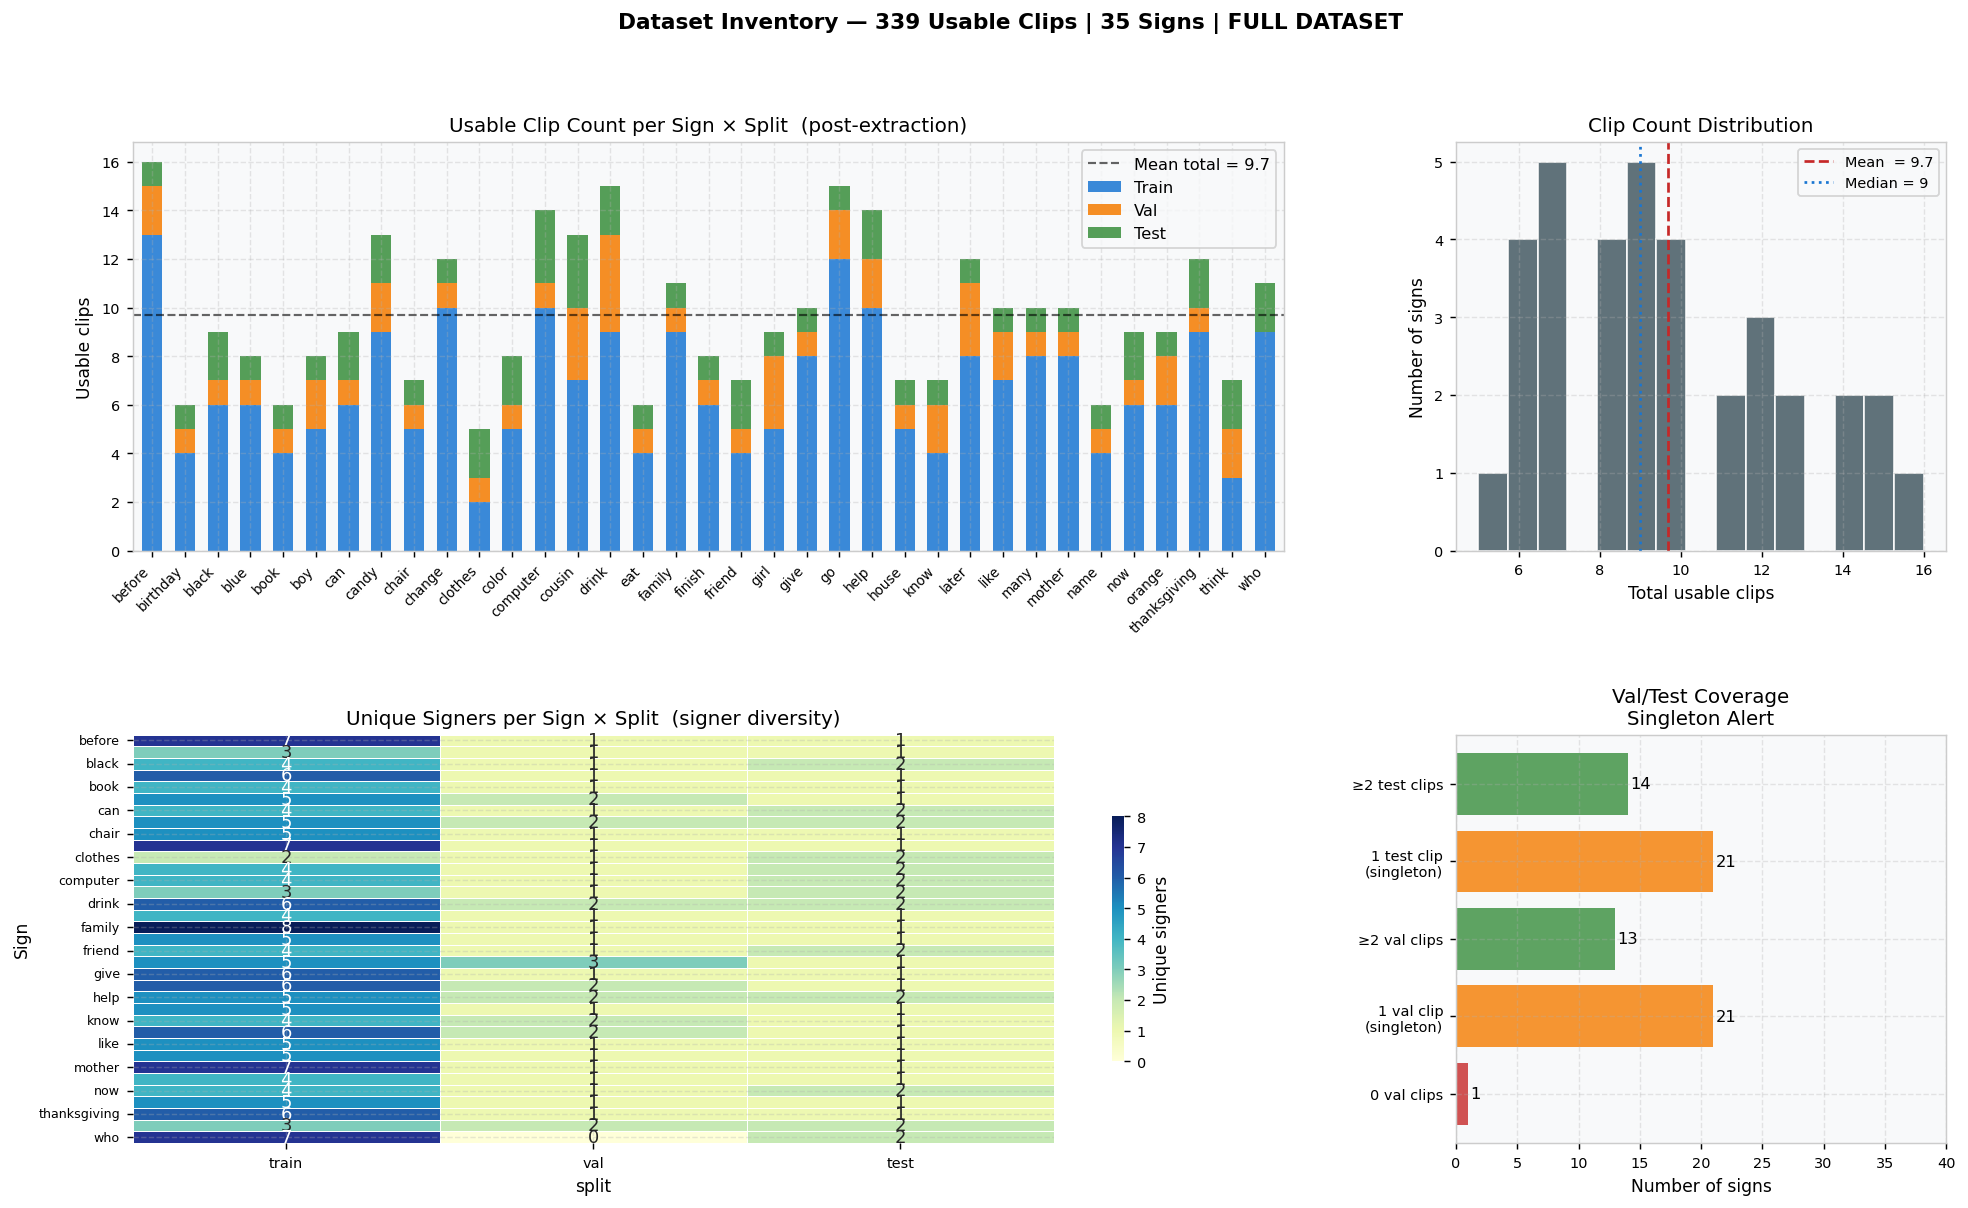

✓  Saved: nb03_01_class_split_inventory.png

Class imbalance ratio      : 3.20×
  Max clips (sign)         : 16 (before)
  Min clips (sign)         : 5 (clothes)
  Signs with 0 val clips   : ['who']
  Signs with 1 val clip    : ['birthday', 'black', 'blue', 'book', 'can', 'chair', 'change', 'clothes', 'color', 'computer', 'eat', 'family', 'finish', 'friend', 'give', 'house', 'many', 'mother', 'name', 'now', 'thanksgiving']

Class weight range (inverse frequency):
  Min weight               : 0.439 (before)
  Max weight               : 2.853 (clothes)
  Weight range             : 6.5×


In [4]:
"""
Authoritative per-sign, per-split clip count and signer count table.
Identifies data-limited signs, val/test singletons, and split quality.

Figures:
  nb03_01_class_split_inventory.png
"""

# ── Per-sign pivot ────────────────────────────────────────────────────────────
_piv_clips = (
    INV_USABLE.groupby(["sign_label", "split"])
    .size().unstack(fill_value=0)
    .reindex(ALL_SIGNS, fill_value=0)
)
for _col in ["train", "val", "test"]:
    if _col not in _piv_clips.columns:
        _piv_clips[_col] = 0

_piv_signers = (
    INV_USABLE[INV_USABLE["signer_id"] >= 0]
    .groupby(["sign_label", "split"])["signer_id"]
    .nunique().unstack(fill_value=0)
    .reindex(ALL_SIGNS, fill_value=0)
)
for _col in ["train", "val", "test"]:
    if _col not in _piv_signers.columns:
        _piv_signers[_col] = 0

_piv_clips["total"]   = _piv_clips[["train", "val", "test"]].sum(axis=1)
_piv_signers["total"] = _piv_signers[["train", "val", "test"]].sum(axis=1)
_piv_clips["class_idx"]   = [CLASSES_INV.get(s, 99) for s in _piv_clips.index]
_piv_clips = _piv_clips.sort_values("class_idx")
_piv_signers = _piv_signers.reindex(_piv_clips.index)

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# [0,0] Stacked bar: clips per sign by split
ax00 = fig.add_subplot(gs[0, :2])
_x   = np.arange(N_CLASSES)
_w   = 0.62
ax00.bar(_x, _piv_clips["train"], _w, color=SPLIT_COLORS["train"], alpha=0.85, label="Train")
ax00.bar(_x, _piv_clips["val"],   _w, bottom=_piv_clips["train"],
         color=SPLIT_COLORS["val"], alpha=0.85, label="Val")
ax00.bar(_x, _piv_clips["test"],  _w,
         bottom=_piv_clips["train"] + _piv_clips["val"],
         color=SPLIT_COLORS["test"], alpha=0.85, label="Test")
ax00.axhline(_piv_clips["total"].mean(), color="black", linestyle="--", linewidth=1.2,
             alpha=0.6, label=f"Mean total = {_piv_clips['total'].mean():.1f}")
ax00.set_xticks(_x)
ax00.set_xticklabels(_piv_clips.index, rotation=45, ha="right", fontsize=7.5)
ax00.set_ylabel("Usable clips")
ax00.set_title("Usable Clip Count per Sign × Split  (post-extraction)")
ax00.legend(loc="upper right", fontsize=9)
ax00.set_xlim(-0.6, N_CLASSES - 0.4)

# [0,2] Imbalance histogram
ax02 = fig.add_subplot(gs[0, 2])
ax02.hist(_piv_clips["total"].values, bins=15, color="#455A64", edgecolor="white", alpha=0.85)
ax02.axvline(_piv_clips["total"].mean(),   color="#C62828", linestyle="--", linewidth=1.5,
             label=f"Mean  = {_piv_clips['total'].mean():.1f}")
ax02.axvline(_piv_clips["total"].median(), color="#1976D2", linestyle=":",  linewidth=1.5,
             label=f"Median = {_piv_clips['total'].median():.0f}")
ax02.set_xlabel("Total usable clips")
ax02.set_ylabel("Number of signs")
ax02.set_title("Clip Count Distribution")
ax02.legend(fontsize=8)

# [1, :2] Signer count heatmap
ax10 = fig.add_subplot(gs[1, :2])
sns.heatmap(
    _piv_signers[["train", "val", "test"]],
    ax=ax10, annot=True, fmt="d", cmap="YlGnBu",
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "Unique signers", "shrink": 0.6},
    vmin=0,
)
ax10.set_title("Unique Signers per Sign × Split  (signer diversity)")
ax10.set_ylabel("Sign")
ax10.tick_params(axis="y", labelsize=7)

# [1,2] Val/test singleton alert
ax12 = fig.add_subplot(gs[1, 2])
_one_val  = [s for s in ALL_SIGNS if _piv_clips.loc[s, "val"]  == 1]
_zero_val = [s for s in ALL_SIGNS if _piv_clips.loc[s, "val"]  == 0]
_one_test = [s for s in ALL_SIGNS if _piv_clips.loc[s, "test"] == 1]

_categories   = ["0 val clips", "1 val clip\n(singleton)", "≥2 val clips",
                 "1 test clip\n(singleton)", "≥2 test clips"]
_cat_counts   = [len(_zero_val), len(_one_val),
                 N_CLASSES - len(_one_val) - len(_zero_val),
                 len(_one_test),
                 N_CLASSES - len(_one_test)]
_cat_colors   = ["#C62828", "#F57C00", "#388E3C", "#F57C00", "#388E3C"]

_bars = ax12.barh(_categories, _cat_counts, color=_cat_colors, alpha=0.8)
for _b, _v in zip(_bars, _cat_counts):
    ax12.text(_v + 0.2, _b.get_y() + _b.get_height() / 2,
              str(_v), va="center", ha="left", fontsize=9)
ax12.set_xlabel("Number of signs")
ax12.set_title("Val/Test Coverage\nSingleton Alert")
ax12.set_xlim(0, N_CLASSES + 5)

fig.suptitle(
    f"Dataset Inventory — {len(INV_USABLE)} Usable Clips | {N_CLASSES} Signs | "
    f"{'FULL DATASET' if IS_FULL else 'SAMPLE'}",
    fontsize=12,
)
plt.savefig(FIGURES_DIR / "nb03_01_class_split_inventory.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓  Saved: nb03_01_class_split_inventory.png")

# ── Text diagnostics ──────────────────────────────────────────────────────────
_imbalance_ratio = _piv_clips["total"].max() / max(_piv_clips["total"].min(), 1)
print(f"\nClass imbalance ratio      : {_imbalance_ratio:.2f}×")
print(f"  Max clips (sign)         : {_piv_clips['total'].max()} ({_piv_clips['total'].idxmax()})")
print(f"  Min clips (sign)         : {_piv_clips['total'].min()} ({_piv_clips['total'].idxmin()})")
print(f"  Signs with 0 val clips   : {_zero_val}")
print(f"  Signs with 1 val clip    : {_one_val}")
print(f"\nClass weight range (inverse frequency):")
_freq = _piv_clips["train"].replace(0, np.nan)
_cw   = (1 / _freq / (1 / _freq).sum()) * N_CLASSES
print(f"  Min weight               : {_cw.min():.3f} ({_cw.idxmin()})")
print(f"  Max weight               : {_cw.max():.3f} ({_cw.idxmax()})")
print(f"  Weight range             : {_cw.max() / _cw.min():.1f}×")

**5 — Sequence Length Analysis (Full Distribution)**

SEQUENCE LENGTH ANALYSIS
  N clips                 : 339
  Mean frames             : 67.6
  Median frames           : 67.0
  Std                     : 23.6
  Min / Max               : 25 / 197
  P25                     : 48
  P50                     : 67
  P75                     : 84
  P90                     : 95
  P95                     : 104

 seq_len   Fully covered   Mean coverage    Max gap (frames)
      20            0.0%           33.8%                 177
      30            1.8%           50.5%                 167
      40           13.9%           64.7%                 157
      60           38.1%           85.0%                 137


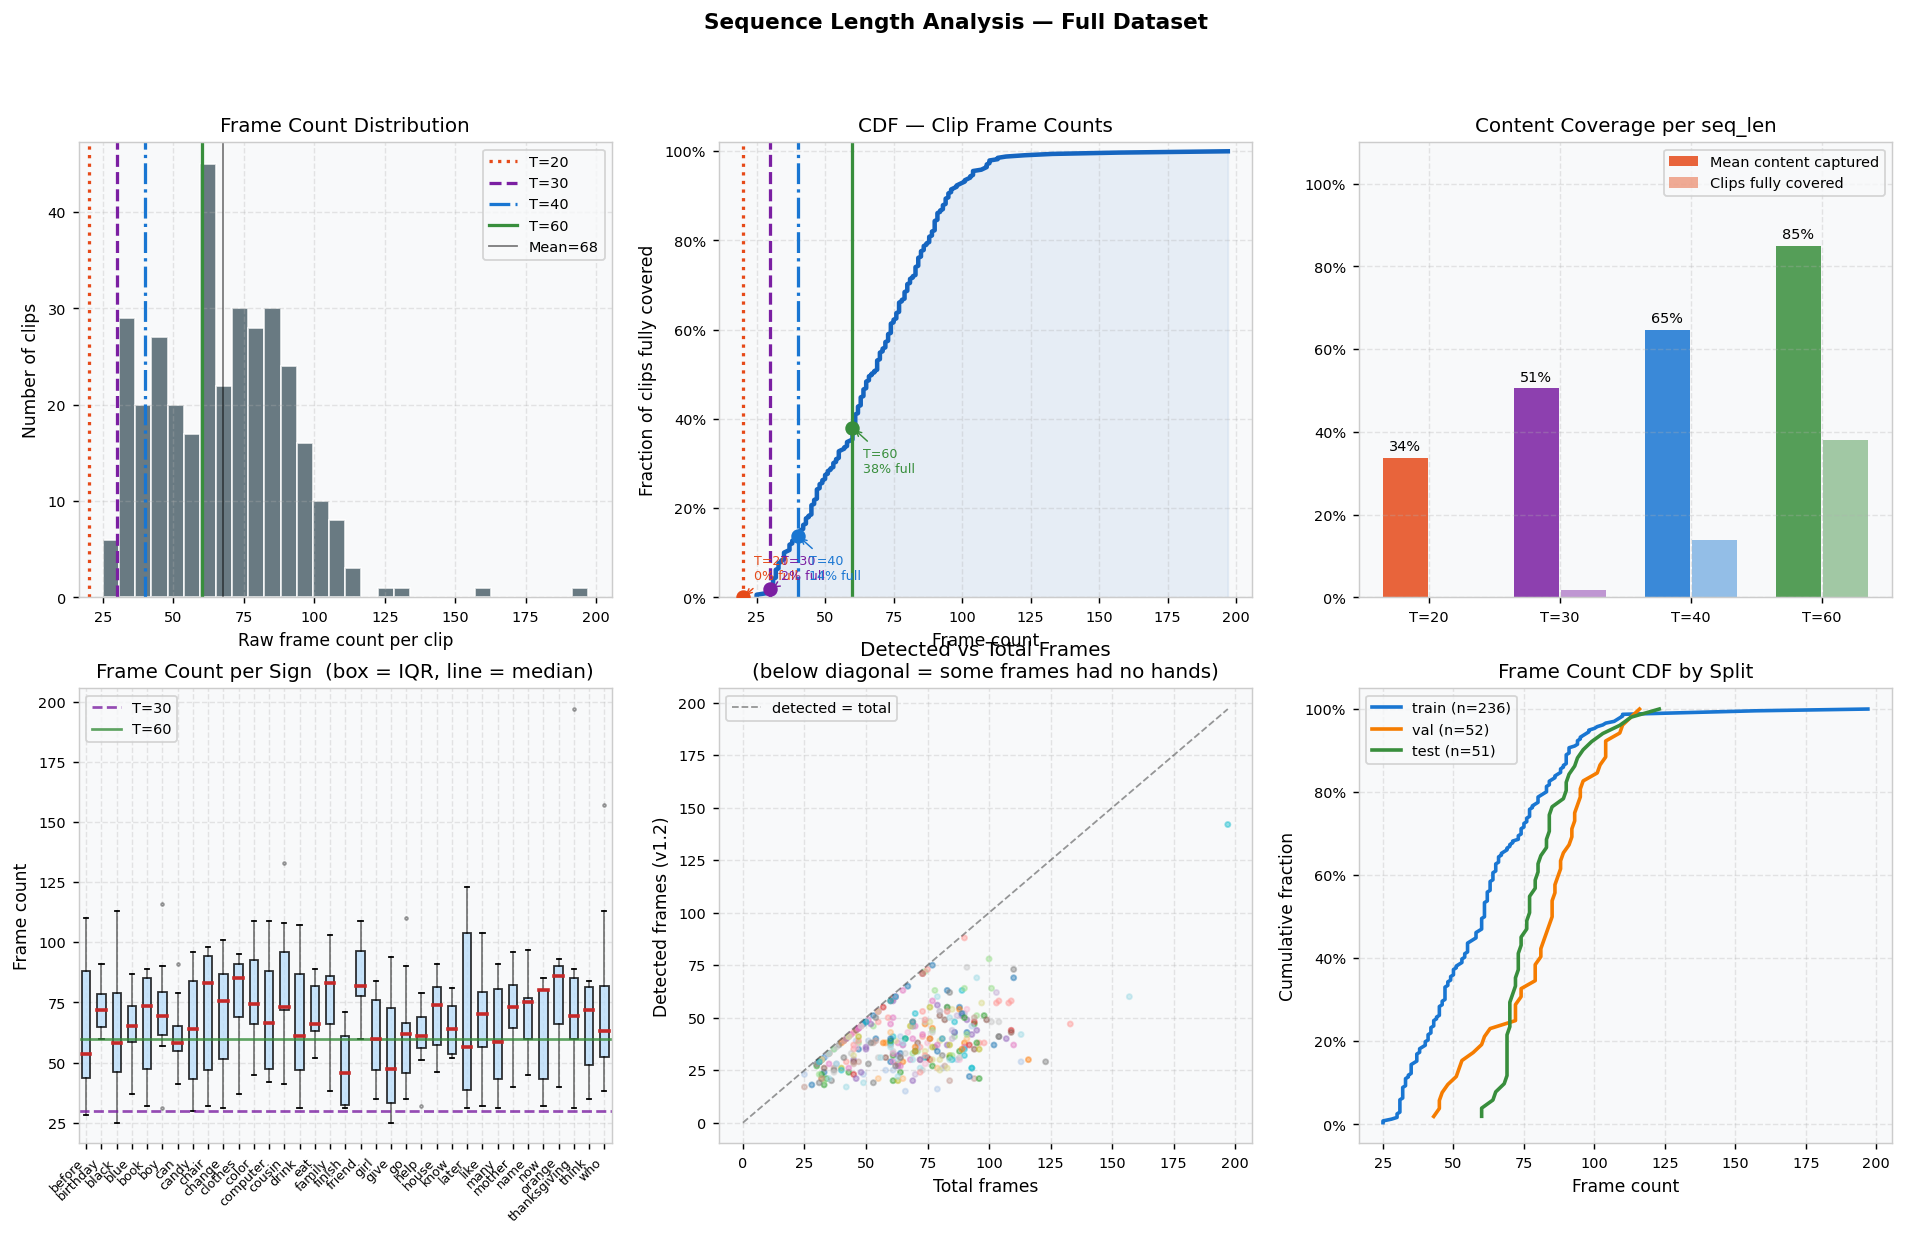

✓  Saved: nb03_02_sequence_length_analysis.png

SEQ_LEN RECOMMENDATION:
  P75 = 84 frames → captures 75% of clips fully
  P90 = 95 frames → captures 90% of clips fully
  → Recommended primary seq_len: 60
  → Ablation: {20, 30, 40, 60}


In [6]:
"""
Sequence length (raw frame count) analysis.

For every usable clip:
  - Raw frame count distribution (histogram + CDF + per-sign box plot)
  - Ablation coverage: what fraction of sign content is captured at each seq_len
  - Recommended seq_len based on P-percentile analysis
  - Min detected frames analysis (v1.2 policy alignment)

Figures:
  nb03_02_sequence_length_analysis.png
"""

_frame_data = INV_USABLE[INV_USABLE["num_frames"] > 0].copy()
_all_frames = _frame_data["num_frames"].values
_detected   = _frame_data.get("detected_frames", pd.Series([0]*len(_frame_data))).values

print("=" * 58)
print("SEQUENCE LENGTH ANALYSIS")
print("=" * 58)
print(f"  N clips                 : {len(_frame_data)}")
print(f"  Mean frames             : {_all_frames.mean():.1f}")
print(f"  Median frames           : {np.median(_all_frames):.1f}")
print(f"  Std                     : {_all_frames.std():.1f}")
print(f"  Min / Max               : {_all_frames.min()} / {_all_frames.max()}")
for _p in [25, 50, 75, 90, 95]:
    print(f"  P{_p:2d}                     : {np.percentile(_all_frames, _p):.0f}")

print(f"\n{'seq_len':>8}  {'Fully covered':>14}  {'Mean coverage':>14}  {'Max gap (frames)':>18}")
for _sl in SEQ_LENS:
    _pct_full = float((_all_frames <= _sl).mean())

    _mean_cov = float(
        (np.minimum(_all_frames, _sl) / np.maximum(_all_frames, 1)).mean()
    )

    _max_gap = int(np.maximum(_all_frames - _sl, 0).max())

    print(
        f"  {_sl:>6}  "
        f"{_pct_full:>14.1%}  "
        f"{_mean_cov:>14.1%}  "
        f"{_max_gap:>18}"
    )

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# [0,0] Histogram of raw frame counts
ax = axes[0, 0]
ax.hist(_all_frames, bins=30, color="#455A64", edgecolor="white", alpha=0.8)
for _sl, _col, _ls in [(20,"#E64A19",":"), (30,"#7B1FA2","--"), (40,"#1976D2","-."), (60,"#388E3C","-")]:
    ax.axvline(_sl, color=_col, linestyle=_ls, linewidth=1.8, label=f"T={_sl}")
ax.axvline(_all_frames.mean(), color="black", linestyle="-", linewidth=1, alpha=0.5,
           label=f"Mean={_all_frames.mean():.0f}")
ax.set_xlabel("Raw frame count per clip")
ax.set_ylabel("Number of clips")
ax.set_title("Frame Count Distribution")
ax.legend(fontsize=8)

# [0,1] CDF with ablation markers
ax = axes[0, 1]
_sf  = np.sort(_all_frames)
_cdf = np.arange(1, len(_sf) + 1) / len(_sf)
ax.plot(_sf, _cdf, color="#1565C0", linewidth=2.5)
ax.fill_between(_sf, _cdf, alpha=0.08, color="#1565C0")
for _sl, _col, _ls, _lbl in [(20,"#E64A19",":"," "), (30,"#7B1FA2","--",""), (40,"#1976D2","-.",""), (60,"#388E3C","-","")]:
    _pct = float((_all_frames <= _sl).mean())
    ax.axvline(_sl, color=_col, linestyle=_ls, linewidth=1.8)
    ax.plot(_sl, _pct, "o", color=_col, markersize=7, zorder=5)
    ax.annotate(f"T={_sl}\n{_pct:.0%} full", xy=(_sl, _pct),
                xytext=(_sl + 4, max(_pct - 0.1, 0.04)),
                fontsize=7, color=_col,
                arrowprops=dict(arrowstyle="->", color=_col, lw=0.8))
ax.set_xlabel("Frame count")
ax.set_ylabel("Fraction of clips fully covered")
ax.set_title("CDF — Clip Frame Counts")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.02)

# [0,2] Coverage at each seq_len (bar chart)
ax = axes[0, 2]
_cov_means = [float((np.minimum(_all_frames, sl) / np.maximum(_all_frames, 1)).mean())
               for sl in SEQ_LENS]
_cov_pcts  = [float((_all_frames <= sl).mean()) for sl in SEQ_LENS]
_xp = np.arange(len(SEQ_LENS))
_bars = ax.bar(_xp - 0.18, _cov_means, 0.34,
               color=["#E64A19","#7B1FA2","#1976D2","#388E3C"], alpha=0.85,
               label="Mean content captured")
ax.bar(_xp + 0.18, _cov_pcts,  0.34,
       color=["#E64A19","#7B1FA2","#1976D2","#388E3C"], alpha=0.45,
       label="Clips fully covered")
for _b, _v in zip(_bars, _cov_means):
    ax.text(_b.get_x() + _b.get_width() / 2, _v + 0.01, f"{_v:.0%}",
            ha="center", va="bottom", fontsize=8)
ax.set_xticks(_xp)
ax.set_xticklabels([f"T={s}" for s in SEQ_LENS])
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title("Content Coverage per seq_len")
ax.legend(fontsize=8)
ax.set_ylim(0, 1.1)

# [1,:2] Per-sign box plot of frame counts
ax = axes[1, 0]
_by_sign = [
    _frame_data[_frame_data["sign_label"] == s]["num_frames"].values
    for s in ALL_SIGNS
]
_by_sign_nz = [v if len(v) > 0 else np.array([0]) for v in _by_sign]
ax.boxplot(
    _by_sign_nz, positions=np.arange(N_CLASSES), widths=0.55, patch_artist=True,
    boxprops=dict(facecolor="#BBDEFB", alpha=0.8),
    medianprops=dict(color="#C62828", linewidth=2),
    whiskerprops=dict(alpha=0.5),
    flierprops=dict(marker="o", markersize=1.5, alpha=0.4),
)
ax.axhline(30, color="#7B1FA2", linestyle="--", linewidth=1.5, alpha=0.8, label="T=30")
ax.axhline(60, color="#388E3C", linestyle="-",  linewidth=1.5, alpha=0.8, label="T=60")
ax.set_xticks(np.arange(N_CLASSES))
ax.set_xticklabels(ALL_SIGNS, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Frame count")
ax.set_title("Frame Count per Sign  (box = IQR, line = median)")
ax.legend(fontsize=8)

# [1,2] Detected frames vs total frames scatter
ax = axes[1, 1]
if _detected.sum() > 0:
    ax.scatter(_all_frames, _detected, s=8, alpha=0.45, c=Y_LABELS[:len(_detected)],
               cmap="tab20", rasterized=True)
    _diag = np.linspace(0, _all_frames.max(), 100)
    ax.plot(_diag, _diag, "k--", linewidth=1, alpha=0.4, label="detected = total")
    ax.set_xlabel("Total frames")
    ax.set_ylabel("Detected frames (v1.2)")
    ax.set_title("Detected vs Total Frames\n(below diagonal = some frames had no hands)")
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, "detected_frames not in inventory", ha="center", va="center",
            transform=ax.transAxes)

# [1,3] Split by split summary
ax = axes[1, 2]
for _split, _col in SPLIT_COLORS.items():
    _d = _frame_data[_frame_data["split"] == _split]["num_frames"].values
    if len(_d) == 0:
        continue
    _s2 = np.sort(_d)
    _c2 = np.arange(1, len(_s2) + 1) / len(_s2)
    ax.plot(_s2, _c2, color=_col, linewidth=2, label=f"{_split} (n={len(_d)})")
ax.set_xlabel("Frame count")
ax.set_ylabel("Cumulative fraction")
ax.set_title("Frame Count CDF by Split")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=8)

fig.suptitle("Sequence Length Analysis — Full Dataset", fontsize=12)
plt.savefig(FIGURES_DIR / "nb03_02_sequence_length_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓  Saved: nb03_02_sequence_length_analysis.png")

# ── Recommendation ────────────────────────────────────────────────────────────
_p75 = np.percentile(_all_frames, 75)
_p90 = np.percentile(_all_frames, 90)
print(f"\nSEQ_LEN RECOMMENDATION:")
print(f"  P75 = {_p75:.0f} frames → captures 75% of clips fully")
print(f"  P90 = {_p90:.0f} frames → captures 90% of clips fully")
_rec = int(min(60, max(30, round(_p75 / 10) * 10)))
print(f"  → Recommended primary seq_len: {_rec}")
print(f"  → Ablation: {{20, 30, 40, 60}}")

**6 — Missing Landmark Analysis (v1.2 Semantics)**

MISSING LANDMARK ANALYSIS  (v1.2 — decoded frames only)
  Left hand      : mean=70.18%  median=100.00%  p75=100.00%  max=100.00%
  Right hand     : mean=37.60%  median=41.38%  p75=55.29%  max=100.00%
  Pose           : mean=0.30%  median=0.00%  p75=0.33%  max=1.92%
  Both hands     : mean=35.28%  median=37.50%  p75=53.39%  max=79.22%

  Total frames (usable)   : 22,928
  Decode failures (v1.1+) : 678  (2.957%)
  Detection rate (usable) : 64.72%


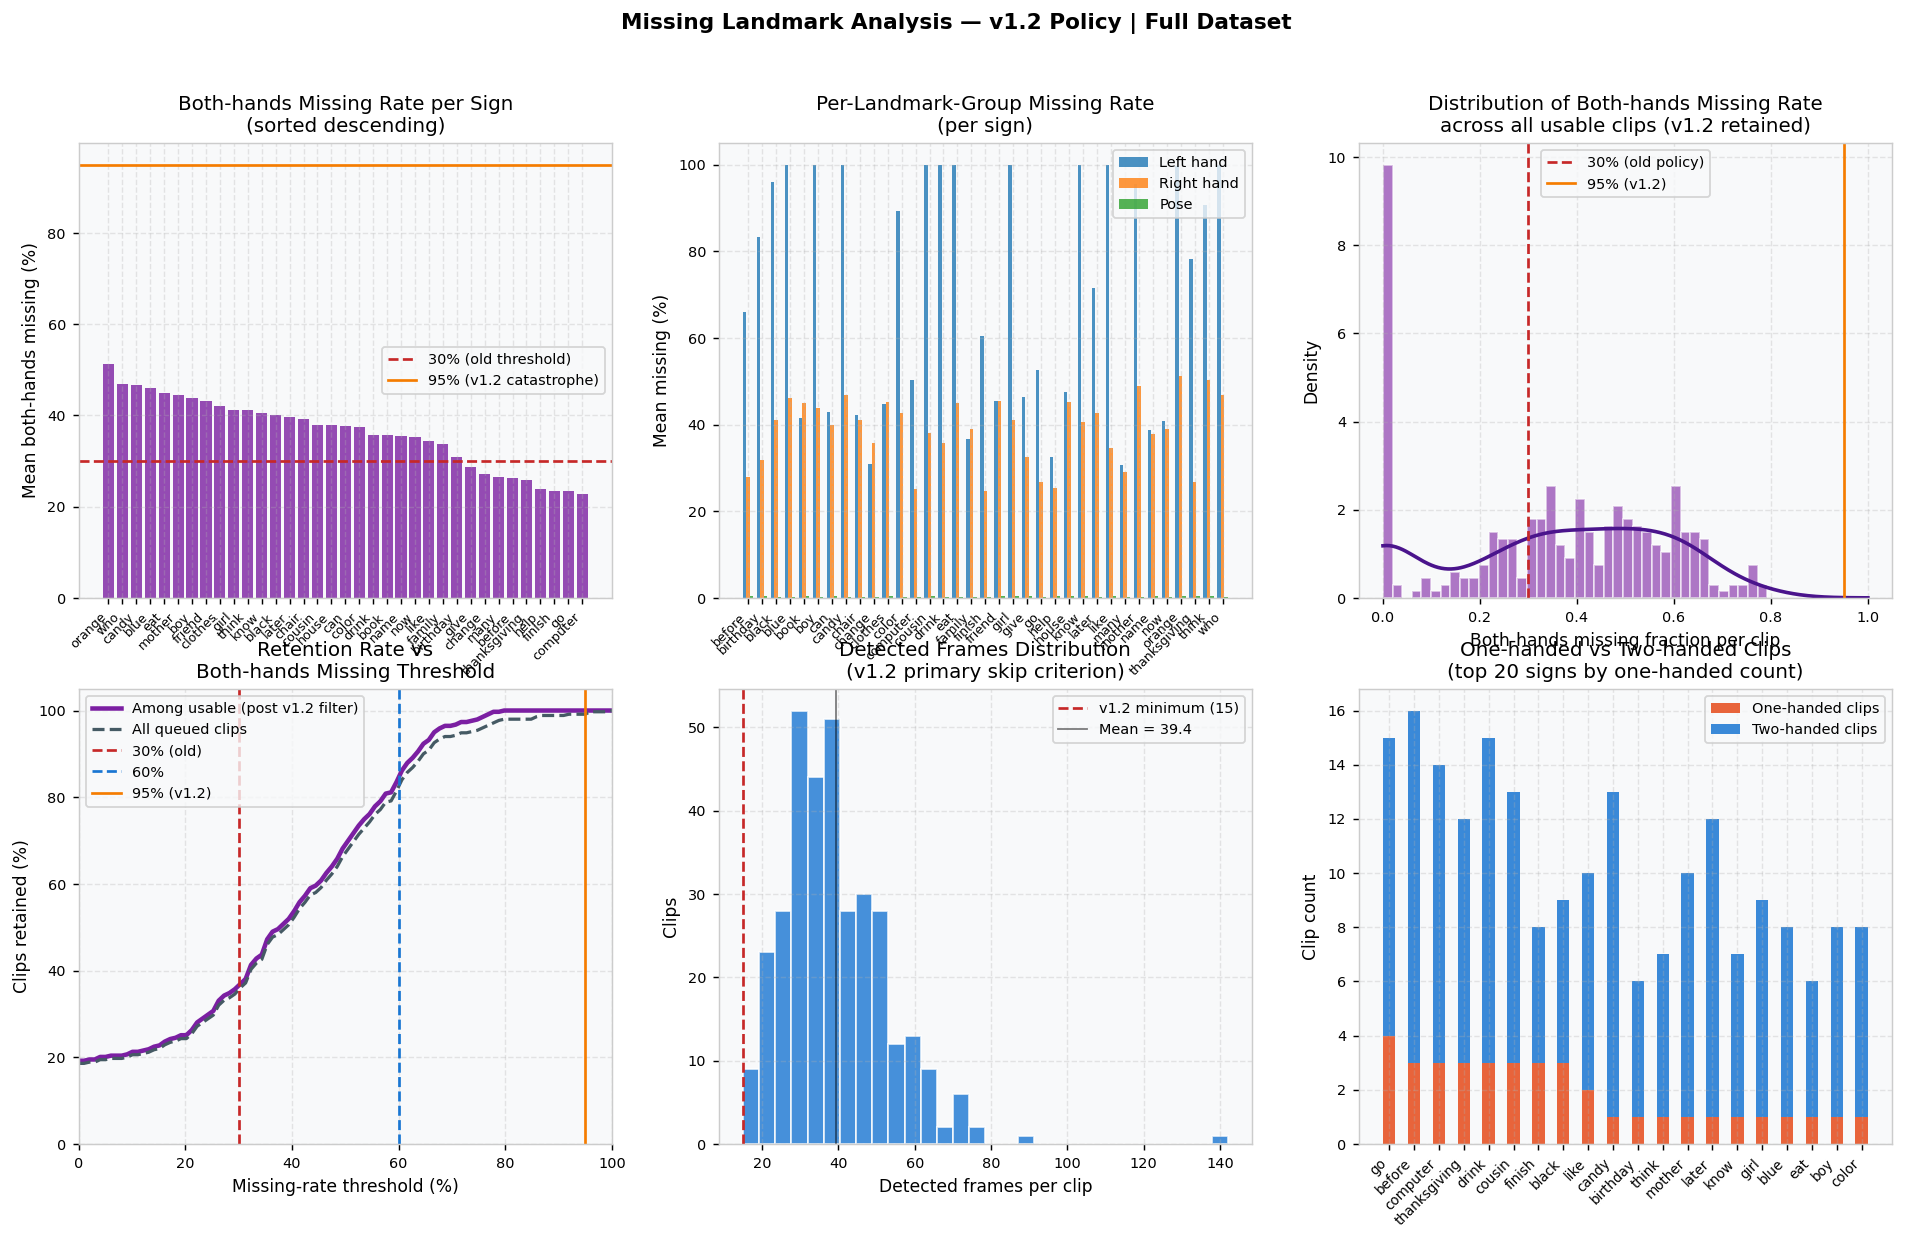

✓  Saved: nb03_03_missing_landmark_analysis.png


In [7]:
"""
Per-hand missing landmark analysis over the full dataset.

Three layers:
  1. Global aggregate statistics (decoded frames vs detection failures)
  2. Per-sign missing rates by landmark group (left/right/pose/both)
  3. Per-clip missing rate distribution — bimodal check
  4. Skip policy post-hoc evaluation: how many clips would be lost at
     alternative thresholds?

Figures:
  nb03_03_missing_landmark_analysis.png
"""

_MISS_COLS = {
    "missing_left_pct":  "Left hand",
    "missing_right_pct": "Right hand",
    "missing_pose_pct":  "Pose",
    "missing_both_pct":  "Both hands",
}
_available_miss_cols = {k: v for k, v in _MISS_COLS.items()
                        if k in INV_USABLE.columns}

print("=" * 58)
print("MISSING LANDMARK ANALYSIS  (v1.2 — decoded frames only)")
print("=" * 58)

for _col, _lbl in _available_miss_cols.items():
    _v = INV_USABLE[_col]
    print(f"  {_lbl:15s}: mean={_v.mean():.2%}  "
          f"median={_v.median():.2%}  "
          f"p75={_v.quantile(0.75):.2%}  "
          f"max={_v.max():.2%}")

# Global decode failure stats
_tot_frames = INV_USABLE["num_frames"].sum()
_tot_dec    = INV_USABLE.get("decode_failure_frames", pd.Series([0]*len(INV_USABLE))).sum()
_dec_rate   = float(_tot_dec) / max(float(_tot_frames), 1)
print(f"\n  Total frames (usable)   : {_tot_frames:,}")
print(f"  Decode failures (v1.1+) : {_tot_dec:,}  ({_dec_rate:.3%})")
print(f"  Detection rate (usable) : {INV_USABLE['detected_rate'].mean():.2%}")

# ── Per-sign missing rates ────────────────────────────────────────────────────
_per_sign_miss = {}
for _sign in ALL_SIGNS:
    _c = INV_USABLE[INV_USABLE["sign_label"] == _sign]
    if _c.empty:
        continue
    _row = {"n": len(_c)}
    for _col, _lbl in _available_miss_cols.items():
        _row[f"{_lbl}_mean"] = float(_c[_col].mean())
        _row[f"{_lbl}_max"]  = float(_c[_col].max())
    _per_sign_miss[_sign] = _row
_psmdf = pd.DataFrame(_per_sign_miss).T

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# [0,0] Both-hands missing rate per sign (bar chart sorted by rate)
ax = axes[0, 0]
if "Both hands_mean" in _psmdf.columns:
    _sorted_miss = _psmdf["Both hands_mean"].reindex(ALL_SIGNS, fill_value=0)
    _sorted_signs_by_miss = _sorted_miss.sort_values(ascending=False)
    _xp = np.arange(len(_sorted_signs_by_miss))
    _bars = ax.bar(_xp, _sorted_signs_by_miss.values * 100, color="#7B1FA2", alpha=0.8)
    ax.axhline(30, color="#C62828", linestyle="--", linewidth=1.5, label="30% (old threshold)")
    ax.axhline(95, color="#F57C00", linestyle="-",  linewidth=1.5, label="95% (v1.2 catastrophe)")
    ax.set_xticks(_xp)
    ax.set_xticklabels(_sorted_signs_by_miss.index, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("Mean both-hands missing (%)")
    ax.set_title("Both-hands Missing Rate per Sign\n(sorted descending)")
    ax.legend(fontsize=8)

# [0,1] Stacked per-landmark missing rate
ax = axes[0, 1]
if len(_available_miss_cols) >= 3:
    _ordered = _psmdf.reindex(ALL_SIGNS).fillna(0)
    _xp = np.arange(N_CLASSES)
    _w  = 0.25
    for _i, (_col, _lbl) in enumerate(_available_miss_cols.items()):
        if "Both" in _lbl:
            continue
        _mean_col = f"{_lbl}_mean"
        if _mean_col in _ordered.columns:
            ax.bar(_xp + (_i - 1) * _w,
                   _ordered[_mean_col].values * 100, _w,
                   label=_lbl, alpha=0.8)
    ax.set_xticks(_xp)
    ax.set_xticklabels(ALL_SIGNS, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("Mean missing (%)")
    ax.set_title("Per-Landmark-Group Missing Rate\n(per sign)")
    ax.legend(fontsize=8)

# [0,2] KDE of both-hands missing rate across all clips
ax = axes[0, 2]
_both_pct = INV_USABLE["missing_both_pct"].values
ax.hist(_both_pct, bins=40, density=True, color="#7B1FA2", alpha=0.6, edgecolor="white")
if _both_pct.std() > 0.001:
    _kde_x = np.linspace(0, 1, 300)
    try:
        _kde = gaussian_kde(_both_pct)
        ax.plot(_kde_x, _kde(_kde_x), color="#4A148C", linewidth=2)
    except Exception:
        pass
ax.axvline(0.30, color="#C62828", linestyle="--", linewidth=1.5, label="30% (old policy)")
ax.axvline(0.95, color="#F57C00", linestyle="-",  linewidth=1.5, label="95% (v1.2)")
ax.set_xlabel("Both-hands missing fraction per clip")
ax.set_ylabel("Density")
ax.set_title("Distribution of Both-hands Missing Rate\nacross all usable clips (v1.2 retained)")
ax.legend(fontsize=8)

# [1,0] Skip policy sensitivity analysis (post-hoc on usable clips)
ax = axes[1, 0]
_thresholds = np.linspace(0, 1, 100)
# How many of the CURRENT usable clips would be FURTHER removed at each threshold
_retained_both = [(_both_pct <= t).mean() for t in _thresholds]
# Also include all queued clips (skipped + usable) for full picture
_all_both = INV_DF["missing_both_pct"].dropna().values
_ret_all = [(_all_both <= t).mean() for t in _thresholds]
ax.plot(_thresholds * 100, np.array(_retained_both) * 100,
        color="#7B1FA2", linewidth=2.5, label="Among usable (post v1.2 filter)")
ax.plot(_thresholds * 100, np.array(_ret_all) * 100,
        color="#455A64", linewidth=1.8, linestyle="--", label="All queued clips")
ax.axvline(30, color="#C62828", linestyle="--", linewidth=1.5, label="30% (old)")
ax.axvline(60, color="#1976D2", linestyle="--", linewidth=1.5, label="60%")
ax.axvline(95, color="#F57C00", linestyle="-",  linewidth=1.5, label="95% (v1.2)")
ax.set_xlabel("Missing-rate threshold (%)")
ax.set_ylabel("Clips retained (%)")
ax.set_title("Retention Rate vs\nBoth-hands Missing Threshold")
ax.legend(fontsize=8)
ax.set_xlim(0, 100)
ax.set_ylim(0, 105)

# [1,1] Detected frames (v1.2 primary criterion) distribution
ax = axes[1, 1]
if "detected_frames" in INV_USABLE.columns:
    _det_vals = INV_USABLE["detected_frames"].values
    ax.hist(_det_vals, bins=30, color="#1976D2", edgecolor="white", alpha=0.8)
    ax.axvline(15, color="#C62828", linestyle="--", linewidth=1.5,
               label=f"v1.2 minimum (15)")
    ax.axvline(_det_vals.mean(), color="black", linestyle="-", linewidth=1, alpha=0.5,
               label=f"Mean = {_det_vals.mean():.1f}")
    ax.set_xlabel("Detected frames per clip")
    ax.set_ylabel("Clips")
    ax.set_title("Detected Frames Distribution\n(v1.2 primary skip criterion)")
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, "detected_frames not available", ha="center", va="center",
            transform=ax.transAxes)

# [1,2] One-handed vs two-handed breakdown
ax = axes[1, 2]
_oh_counts = INV_USABLE.groupby(["sign_label", "is_one_handed"]).size().unstack(fill_value=0)
_oh_counts.columns = ["Two-handed", "One-handed"]
_oh_counts = _oh_counts.reindex(ALL_SIGNS, fill_value=0)
_oh_sorted = _oh_counts.sort_values("One-handed", ascending=False).head(20)
_xp = np.arange(len(_oh_sorted))
ax.bar(_xp, _oh_sorted["One-handed"],  0.5, color="#E64A19", alpha=0.85, label="One-handed clips")
ax.bar(_xp, _oh_sorted["Two-handed"],  0.5, bottom=_oh_sorted["One-handed"],
       color="#1976D2", alpha=0.85, label="Two-handed clips")
ax.set_xticks(_xp)
ax.set_xticklabels(_oh_sorted.index, rotation=45, ha="right", fontsize=7.5)
ax.set_ylabel("Clip count")
ax.set_title("One-handed vs Two-handed Clips\n(top 20 signs by one-handed count)")
ax.legend(fontsize=8)

fig.suptitle("Missing Landmark Analysis — v1.2 Policy | Full Dataset", fontsize=12)
plt.savefig(FIGURES_DIR / "nb03_03_missing_landmark_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓  Saved: nb03_03_missing_landmark_analysis.png")

**7 — Feature Coverage: Per-Dimension Non-Zero Rate**

Computing per-dimension statistics across all frames…
✓  Total frames analysed   : 22,928
   LH non-zero rate mean   : 27.37%
   RH non-zero rate mean   : 55.99%
   Pose non-zero rate mean : 96.67%

  Dims < 5% non-zero: LH=0, RH=0, Pose=0


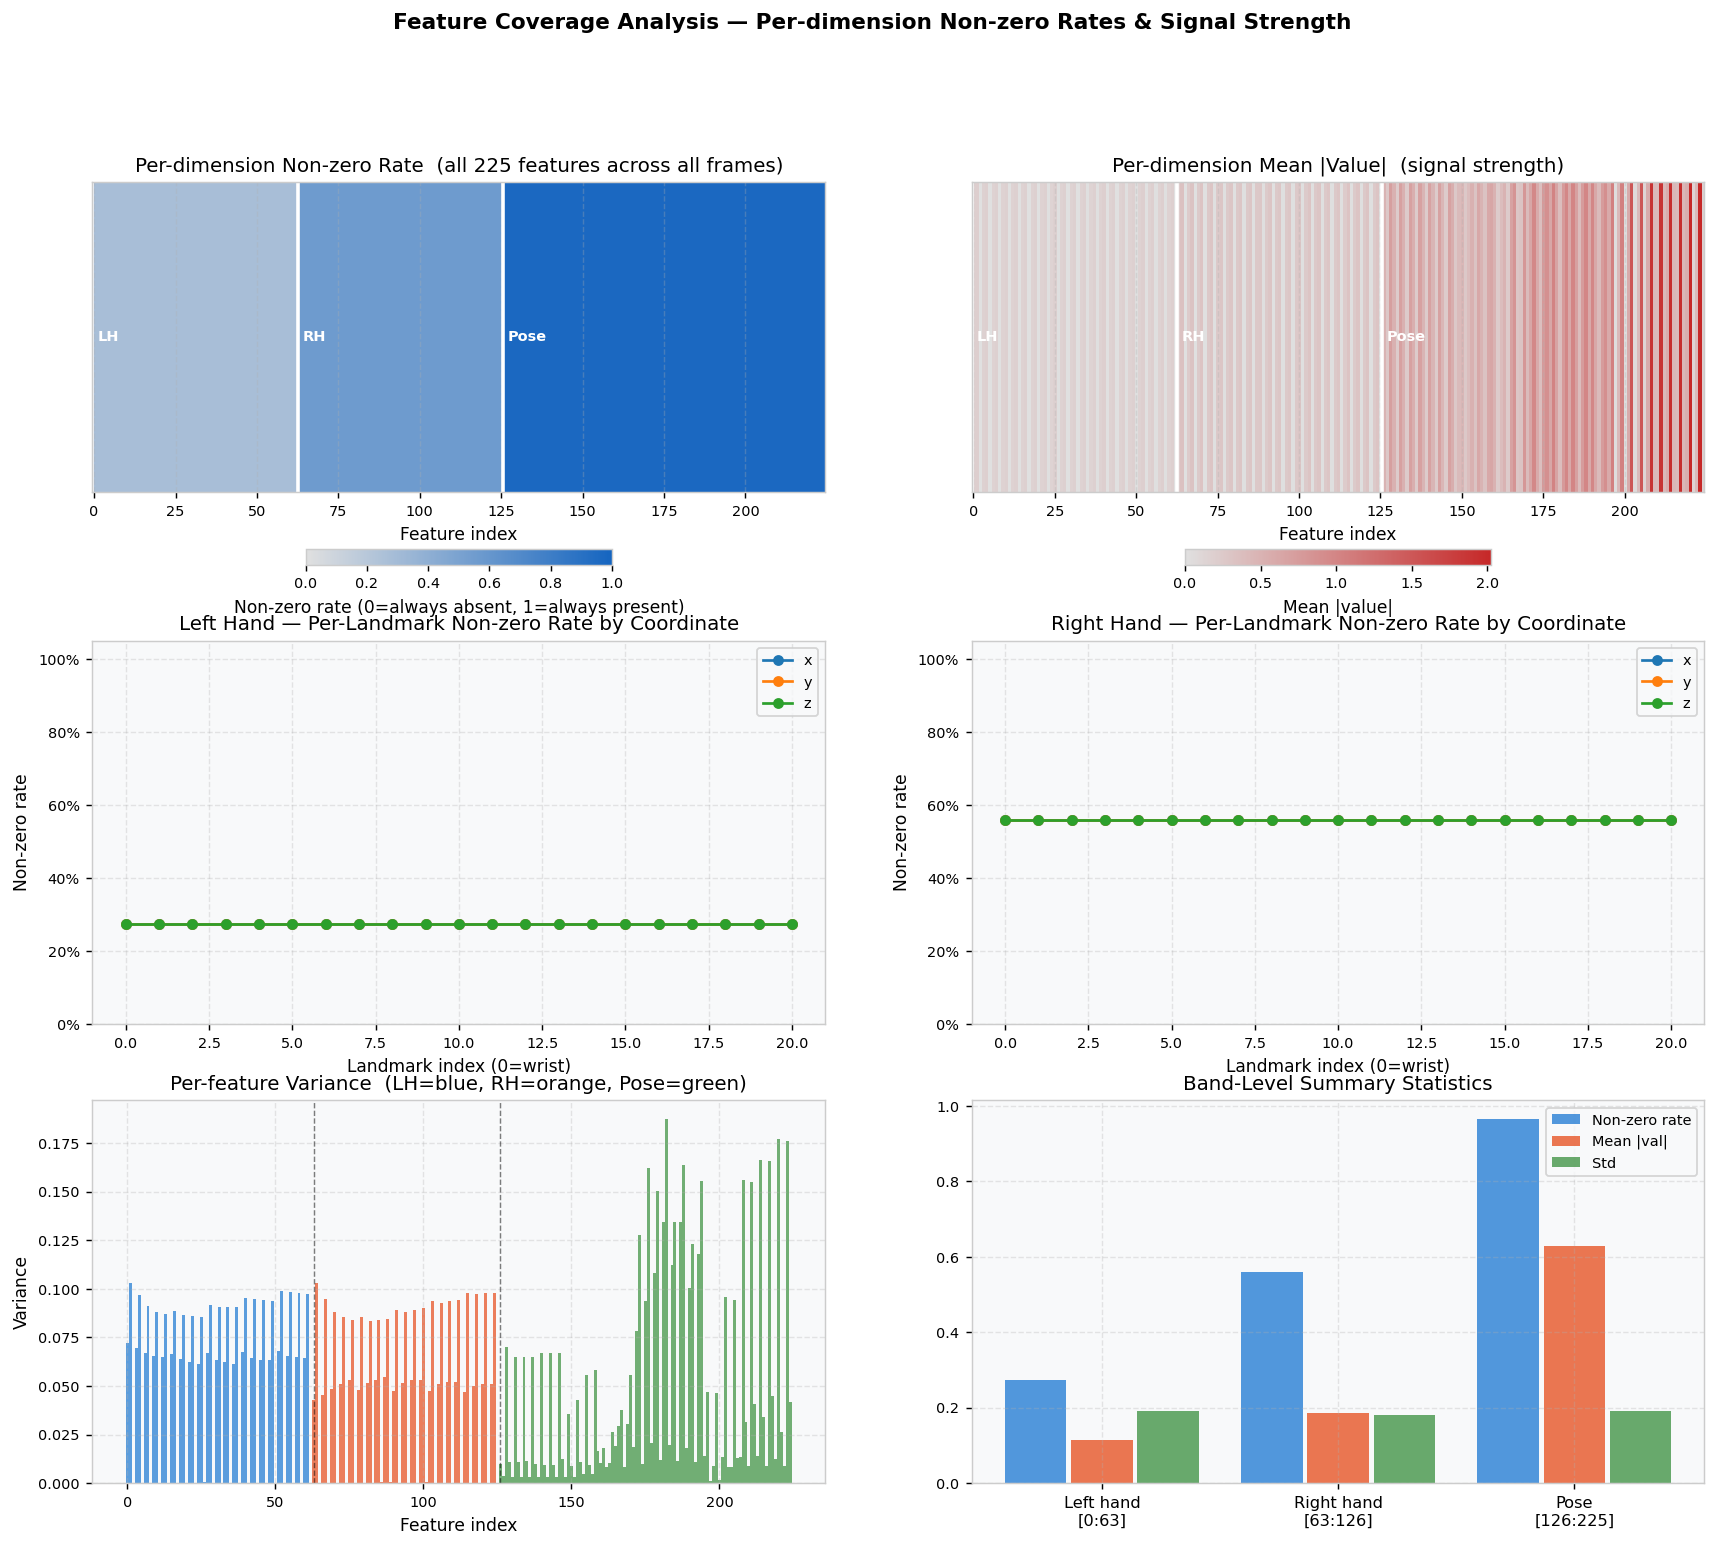

✓  Saved: nb03_04_feature_coverage.png

FEATURE COVERAGE DECISIONS:
  Pose detection rate: 96.67%
  → Pose features are reliable — include in LSTM input
  Z-coordinate (depth) mean |val|:
    LH z-mean=0.0066  vs  LH xy-mean=0.1668
  → Z coordinates have ~4% of xy signal — worth retaining


In [8]:
"""
Per-dimension feature coverage analysis.

For each of the 225 feature dimensions, computes:
  - Non-zero rate across all frames of all usable clips
  - Mean absolute value (signal strength)
  - Variance

Reveals: dead dimensions, systematically missing landmarks, pose-vs-hand
utilisation asymmetry. Informs feature selection and normalisation choices.

Figures:
  nb03_04_feature_coverage.png
"""

print("Computing per-dimension statistics across all frames…")

_all_frames_stacked = np.concatenate(ARRAYS, axis=0)   # (Total_frames, 225)
_N_total            = _all_frames_stacked.shape[0]

_nonzero_rate = (_all_frames_stacked != 0).mean(axis=0)          # (225,)
_mean_abs     = np.abs(_all_frames_stacked).mean(axis=0)
_variance     = _all_frames_stacked.var(axis=0)
_std          = _all_frames_stacked.std(axis=0)

print(f"✓  Total frames analysed   : {_N_total:,}")
print(f"   LH non-zero rate mean   : {_nonzero_rate[LEFT_HAND_SLICE].mean():.2%}")
print(f"   RH non-zero rate mean   : {_nonzero_rate[RIGHT_HAND_SLICE].mean():.2%}")
print(f"   Pose non-zero rate mean : {_nonzero_rate[POSE_SLICE].mean():.2%}")

# Dimensions below 5% non-zero — nearly dead
_dead_thresh = 0.05
_dead_lh   = np.where(_nonzero_rate[LEFT_HAND_SLICE]  < _dead_thresh)[0]
_dead_rh   = np.where(_nonzero_rate[RIGHT_HAND_SLICE] < _dead_thresh)[0]
_dead_pose = np.where(_nonzero_rate[POSE_SLICE]       < _dead_thresh)[0]
print(f"\n  Dims < {_dead_thresh:.0%} non-zero: "
      f"LH={len(_dead_lh)}, RH={len(_dead_rh)}, Pose={len(_dead_pose)}")

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 13))

# ── Custom colourmap: grey=0, blue=active
_cmap_nz = LinearSegmentedColormap.from_list("nz", ["#E0E0E0", "#1565C0"])

# [0,:] Non-zero rate heatmap (1×225 row)
ax = axes[0, 0]
_nz_reshaped = _nonzero_rate.reshape(1, -1)
_im = ax.imshow(_nz_reshaped, aspect="auto", cmap=_cmap_nz, vmin=0, vmax=1,
                interpolation="nearest")
# Band lines
for _b, _lbl, _col in [(0, "LH", BAND_COLORS["left_hand"]),
                        (63, "RH",  BAND_COLORS["right_hand"]),
                        (126, "Pose", BAND_COLORS["pose"])]:
    ax.axvline(_b - 0.5, color="white", linewidth=2)
    ax.text(_b + 1, 0, _lbl, color="white", fontsize=8, fontweight="bold",
            va="center", clip_on=True)
plt.colorbar(_im, ax=ax, orientation="horizontal", fraction=0.04, pad=0.15,
             label="Non-zero rate (0=always absent, 1=always present)")
ax.set_yticks([])
ax.set_xlabel("Feature index")
ax.set_title("Per-dimension Non-zero Rate  (all 225 features across all frames)")

# [0,1] Mean abs value heatmap
ax = axes[0, 1]
_cmap_abs = LinearSegmentedColormap.from_list("abs", ["#E0E0E0", "#C62828"])
_im2 = ax.imshow(_mean_abs.reshape(1, -1), aspect="auto", cmap=_cmap_abs,
                 vmin=0, interpolation="nearest")
for _b, _lbl in [(0,"LH"), (63,"RH"), (126,"Pose")]:
    ax.axvline(_b - 0.5, color="white", linewidth=2)
    ax.text(_b + 1, 0, _lbl, color="white", fontsize=8, fontweight="bold",
            va="center", clip_on=True)
plt.colorbar(_im2, ax=ax, orientation="horizontal", fraction=0.04, pad=0.15,
             label="Mean |value|")
ax.set_yticks([])
ax.set_xlabel("Feature index")
ax.set_title("Per-dimension Mean |Value|  (signal strength)")

# [1,0] Per-landmark non-zero rate: left hand
ax = axes[1, 0]
_lh_nz = _nonzero_rate[LEFT_HAND_SLICE].reshape(N_HAND_LANDMARKS, N_COORDS_PER_LANDMARK)
_coord_labels = ["x", "y", "z"]
for _ci, _clbl in enumerate(_coord_labels):
    ax.plot(np.arange(N_HAND_LANDMARKS), _lh_nz[:, _ci], "o-",
            markersize=5, linewidth=1.5, label=f"{_clbl}")
ax.set_xlabel("Landmark index (0=wrist)")
ax.set_ylabel("Non-zero rate")
ax.set_title("Left Hand — Per-Landmark Non-zero Rate by Coordinate")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# [1,1] Per-landmark non-zero rate: right hand
ax = axes[1, 1]
_rh_nz = _nonzero_rate[RIGHT_HAND_SLICE].reshape(N_HAND_LANDMARKS, N_COORDS_PER_LANDMARK)
for _ci, _clbl in enumerate(_coord_labels):
    ax.plot(np.arange(N_HAND_LANDMARKS), _rh_nz[:, _ci], "o-",
            markersize=5, linewidth=1.5, label=f"{_clbl}")
ax.set_xlabel("Landmark index (0=wrist)")
ax.set_ylabel("Non-zero rate")
ax.set_title("Right Hand — Per-Landmark Non-zero Rate by Coordinate")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# [2,0] Variance per feature dimension
ax = axes[2, 0]
ax.bar(np.arange(FEATURE_SIZE), _variance,
       color=["#1976D2"] * 63 + ["#E64A19"] * 63 + ["#388E3C"] * 99,
       alpha=0.7, width=1)
ax.set_xlabel("Feature index")
ax.set_ylabel("Variance")
ax.set_title("Per-feature Variance  (LH=blue, RH=orange, Pose=green)")
ax.axvline(63,  color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax.axvline(126, color="black", linestyle="--", linewidth=0.8, alpha=0.5)

# [2,1] Band-level summary
ax = axes[2, 1]
_band_stats = {
    "Left hand\n[0:63]": {
        "Non-zero rate": _nonzero_rate[LEFT_HAND_SLICE].mean(),
        "Mean |val|":    _mean_abs[LEFT_HAND_SLICE].mean(),
        "Std":           _std[LEFT_HAND_SLICE].mean(),
    },
    "Right hand\n[63:126]": {
        "Non-zero rate": _nonzero_rate[RIGHT_HAND_SLICE].mean(),
        "Mean |val|":    _mean_abs[RIGHT_HAND_SLICE].mean(),
        "Std":           _std[RIGHT_HAND_SLICE].mean(),
    },
    "Pose\n[126:225]": {
        "Non-zero rate": _nonzero_rate[POSE_SLICE].mean(),
        "Mean |val|":    _mean_abs[POSE_SLICE].mean(),
        "Std":           _std[POSE_SLICE].mean(),
    },
}
_bdf = pd.DataFrame(_band_stats).T
_xp  = np.arange(3)
_metrics = list(_bdf.columns)
_band_colors_list = [BAND_COLORS["left_hand"], BAND_COLORS["right_hand"], BAND_COLORS["pose"]]
for _mi, _m in enumerate(_metrics):
    ax.bar(_xp + _mi * 0.28, _bdf[_m].values, 0.26,
           color=[BAND_COLORS["left_hand"], BAND_COLORS["right_hand"],
                  BAND_COLORS["pose"]][_mi], alpha=0.75, label=_m)
ax.set_xticks(_xp + 0.28)
ax.set_xticklabels(_bdf.index, fontsize=9)
ax.set_title("Band-Level Summary Statistics")
ax.legend(fontsize=8)

fig.suptitle("Feature Coverage Analysis — Per-dimension Non-zero Rates & Signal Strength",
             fontsize=12)
plt.savefig(FIGURES_DIR / "nb03_04_feature_coverage.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓  Saved: nb03_04_feature_coverage.png")

# ── Design decisions ──────────────────────────────────────────────────────────
print(f"\nFEATURE COVERAGE DECISIONS:")
print(f"  Pose detection rate: {_nonzero_rate[POSE_SLICE].mean():.2%}")
print(f"  → Pose features are {'reliable — include in LSTM input' if _nonzero_rate[POSE_SLICE].mean() > 0.7 else 'sparse — consider ablation'}")
print(f"  Z-coordinate (depth) mean |val|:")
_z_lh_mean = _mean_abs[LEFT_HAND_SLICE].reshape(N_HAND_LANDMARKS, 3)[:, 2].mean()
_z_rh_mean = _mean_abs[RIGHT_HAND_SLICE].reshape(N_HAND_LANDMARKS, 3)[:, 2].mean()
_xy_lh_mean = _mean_abs[LEFT_HAND_SLICE].reshape(N_HAND_LANDMARKS, 3)[:, :2].mean()
print(f"    LH z-mean={_z_lh_mean:.4f}  vs  LH xy-mean={_xy_lh_mean:.4f}")
print(f"  → Z coordinates have {'~{:.0%} of xy signal — worth retaining'.format(_z_lh_mean/_xy_lh_mean) if _xy_lh_mean > 0 else 'no xy baseline'}")

**8 — Temporal Dynamics: Velocity & Acceleration**

Computing velocity/acceleration for all clips…
✓  Velocity computed in 2.0s


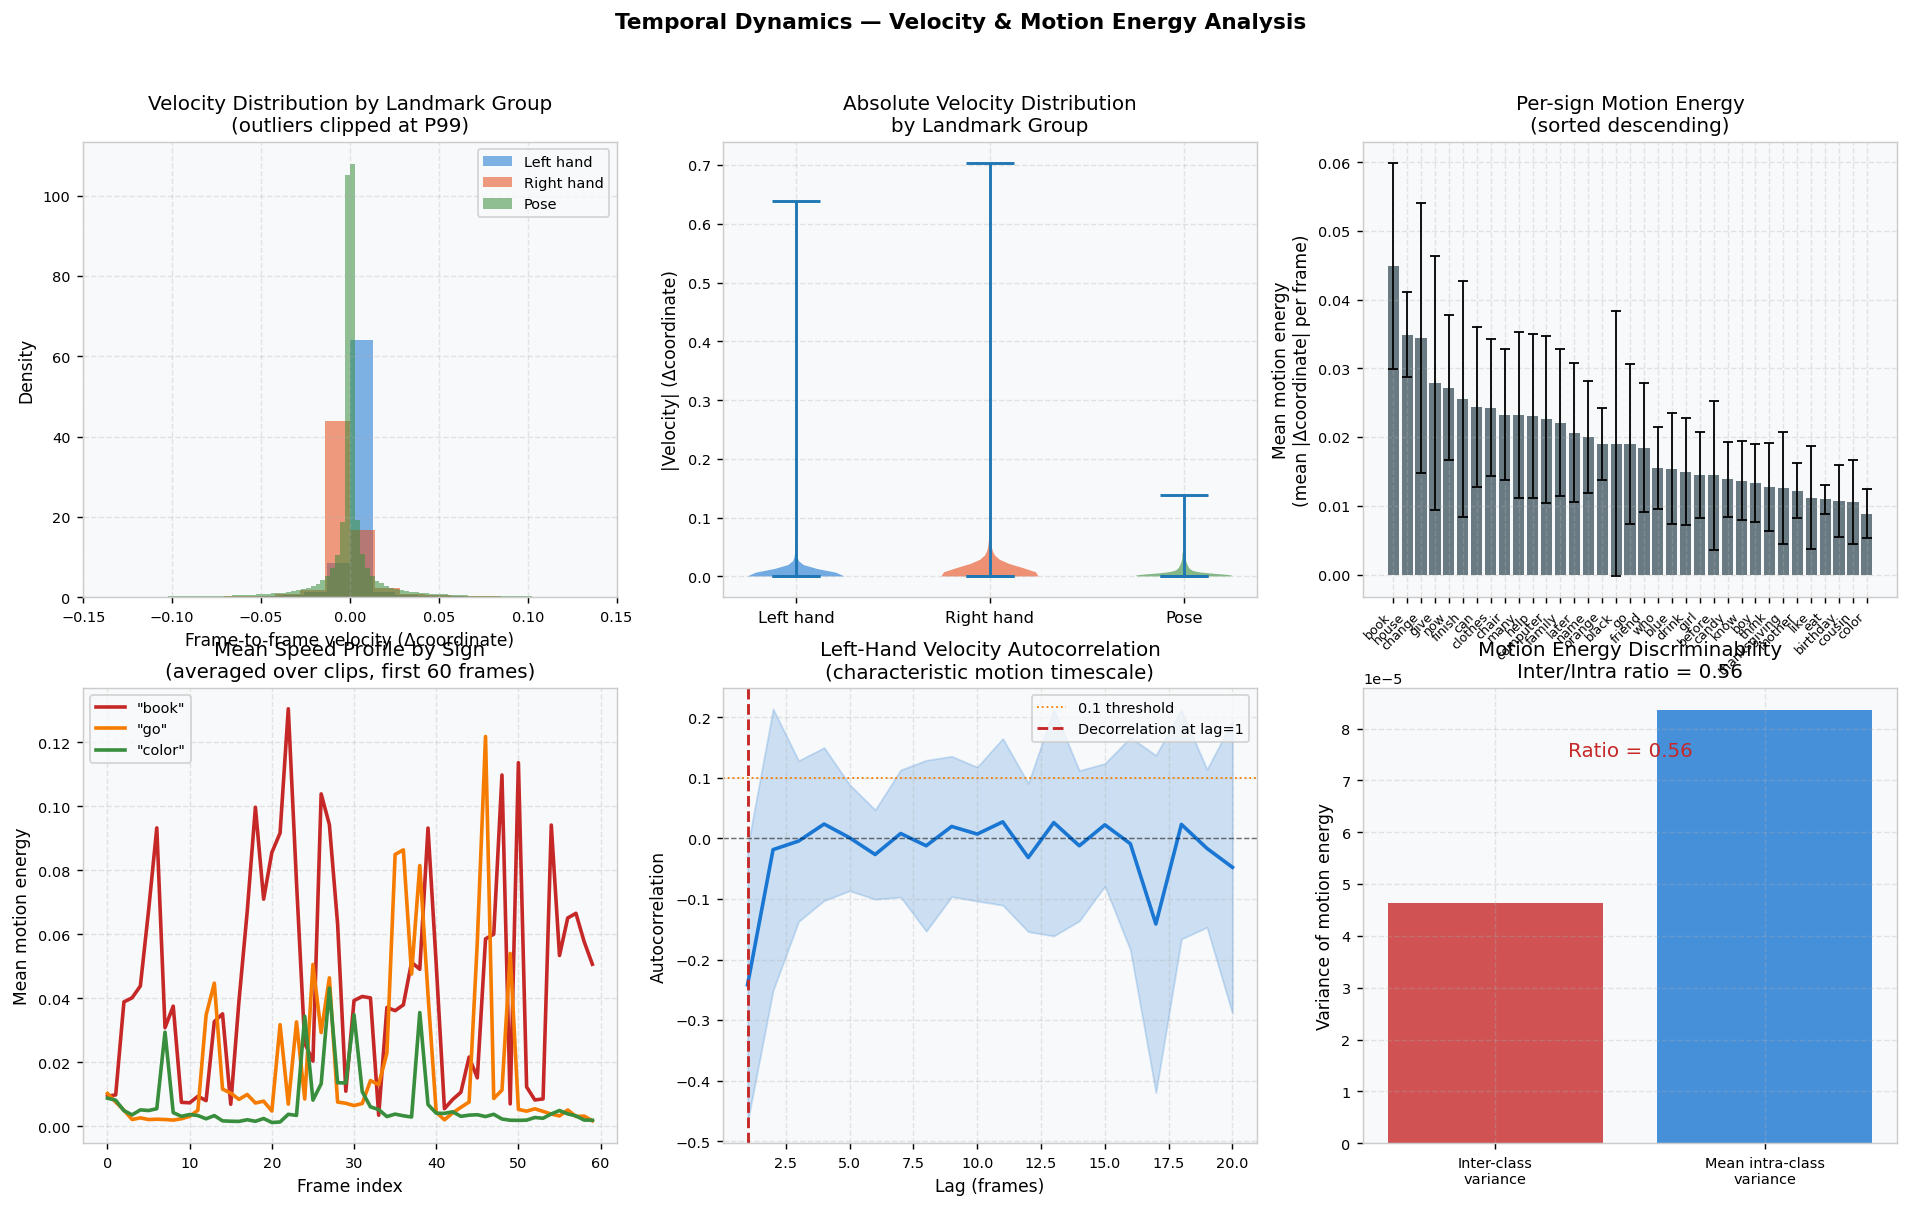

✓  Saved: nb03_05_temporal_dynamics.png

TEMPORAL DYNAMICS SUMMARY:
  Motion energy discriminability ratio : 0.555
  → Moderate temporal signal — consider velocity features in Stage 4
  Velocity decorrelation lag           : 1 frames
  → Effective temporal horizon: ~1 frames
  → seq_len=30 covers ~3× decorrelation timescale


In [9]:
"""
Temporal dynamics: frame-to-frame velocity and acceleration.

Computes per-clip, per-landmark velocity and acceleration on detected frames.
Answers:
  - Do landmarks carry meaningful temporal information? (Yes → LSTM justified)
  - Which landmark groups are most dynamic?
  - Do signs differ in motion energy? (→ augmentation strategy)
  - What is the characteristic timescale of sign execution?

Figures:
  nb03_05_temporal_dynamics.png
"""

def compute_velocity(arr: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute frame-to-frame velocity and acceleration on NON-ZERO frames.

    Parameters
    ----------
    arr : (T, 225) float32

    Returns
    -------
    velocity     : (T-1, 225) float32  (NaN where either frame is zero-filled)
    acceleration : (T-2, 225) float32
    """
    vel   = arr[1:] - arr[:-1]   # (T-1, 225)
    accel = vel[1:] - vel[:-1]   # (T-2, 225)

    # Mask transitions involving zero-filled frames
    for _t in range(arr.shape[0] - 1):
        if (arr[_t] == 0).all() or (arr[_t + 1] == 0).all():
            vel[_t]   = np.nan
        if _t < arr.shape[0] - 2:
            if (arr[_t] == 0).all() or (arr[_t + 1] == 0).all() or (arr[_t + 2] == 0).all():
                accel[_t] = np.nan

    return vel.astype(np.float32), accel.astype(np.float32)


print("Computing velocity/acceleration for all clips…")
_t0 = time.time()

_per_sign_motion_energy = defaultdict(list)   # sign → list of mean motion energies
_global_vel_lh, _global_vel_rh, _global_vel_pose = [], [], []
_global_accel_lh = []
_speed_profiles   = {}   # vid_id → mean velocity per frame (T-1,)

for _arr, _meta in zip(ARRAYS, ARRAY_META):
    _vel, _accel = compute_velocity(_arr)

    # Motion energy = mean absolute velocity per frame per landmark
    _me_lh   = np.nanmean(np.abs(_vel[:, LEFT_HAND_SLICE]),  axis=1)
    _me_rh   = np.nanmean(np.abs(_vel[:, RIGHT_HAND_SLICE]), axis=1)
    _me_pose = np.nanmean(np.abs(_vel[:, POSE_SLICE]),       axis=1)
    _me_total = np.nanmean([_me_lh, _me_rh, _me_pose], axis=0)

    _per_sign_motion_energy[_meta["sign_label"]].append(np.nanmean(_me_total))
    _speed_profiles[_meta["video_id"]] = _me_total

    _global_vel_lh.extend(_vel[:, LEFT_HAND_SLICE].flatten())
    _global_vel_rh.extend(_vel[:, RIGHT_HAND_SLICE].flatten())
    _global_vel_pose.extend(_vel[:, POSE_SLICE].flatten())
    _global_accel_lh.extend(_accel[:, LEFT_HAND_SLICE].flatten())

_elapsed = time.time() - _t0
print(f"✓  Velocity computed in {_elapsed:.1f}s")

# ── Per-sign motion energy ────────────────────────────────────────────────────
_sign_me_mean = {s: np.mean(v) for s, v in _per_sign_motion_energy.items()}
_sign_me_std  = {s: np.std(v)  for s, v in _per_sign_motion_energy.items()}

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# [0,0] Velocity distribution per band
ax = axes[0, 0]
_vbands = [
    ("Left hand", np.array(_global_vel_lh),   BAND_COLORS["left_hand"]),
    ("Right hand", np.array(_global_vel_rh),  BAND_COLORS["right_hand"]),
    ("Pose",       np.array(_global_vel_pose), BAND_COLORS["pose"]),
]
for _lbl, _dat, _col in _vbands:
    _dat_clean = _dat[np.isfinite(_dat)]
    if len(_dat_clean) == 0:
        continue
    _clip_val = np.percentile(np.abs(_dat_clean), 99)  # clip outliers for display
    _dat_clip = _dat_clean[np.abs(_dat_clean) < _clip_val]
    ax.hist(_dat_clip, bins=100, density=True, alpha=0.55, color=_col,
            label=_lbl, histtype="stepfilled")
ax.set_xlabel("Frame-to-frame velocity (Δcoordinate)")
ax.set_ylabel("Density")
ax.set_title("Velocity Distribution by Landmark Group\n(outliers clipped at P99)")
ax.legend(fontsize=8)
ax.set_xlim(-0.15, 0.15)

# [0,1] Absolute velocity (motion energy) per band — violin
ax = axes[0, 1]
_abs_vels = []
_abs_lbls = []
for _lbl, _dat, _col in _vbands:
    _dat_clean = np.abs(_dat[np.isfinite(_dat)])
    if len(_dat_clean) == 0:
        continue
    _dat_clip = _dat_clean[_dat_clean < np.percentile(_dat_clean, 99)]
    _sample   = np.random.choice(_dat_clip, size=min(10000, len(_dat_clip)), replace=False)
    _abs_vels.append(_sample)
    _abs_lbls.append(_lbl)

if _abs_vels:
    _parts = ax.violinplot(_abs_vels, positions=range(len(_abs_vels)),
                           showmedians=True, showextrema=True)
    for _i, (_pc, _col) in enumerate(zip(_parts["bodies"],
                                           [BAND_COLORS["left_hand"],
                                            BAND_COLORS["right_hand"],
                                            BAND_COLORS["pose"]])):
        _pc.set_facecolor(_col)
        _pc.set_alpha(0.6)
    ax.set_xticks(range(len(_abs_lbls)))
    ax.set_xticklabels(_abs_lbls, fontsize=9)
    ax.set_ylabel("|Velocity| (Δcoordinate)")
    ax.set_title("Absolute Velocity Distribution\nby Landmark Group")

# [0,2] Per-sign motion energy (sorted)
ax = axes[0, 2]
_sign_me_sorted = sorted(_sign_me_mean.items(), key=lambda x: x[1], reverse=True)
_xs = [x[0] for x in _sign_me_sorted]
_ys = [x[1] for x in _sign_me_sorted]
_ye = [_sign_me_std.get(x, 0) for x in _xs]
_xp = np.arange(len(_xs))
ax.bar(_xp, _ys, color="#455A64", alpha=0.8)
ax.errorbar(_xp, _ys, yerr=_ye, fmt="none", color="black", capsize=3, linewidth=1)
ax.set_xticks(_xp)
ax.set_xticklabels(_xs, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Mean motion energy\n(mean |Δcoordinate| per frame)")
ax.set_title("Per-sign Motion Energy\n(sorted descending)")

# [1,0] Speed profile for 3 contrasting signs
ax = axes[1, 0]
_profile_signs = []
if _sign_me_sorted:
    _profile_signs.append(_sign_me_sorted[0][0])    # most dynamic
    _profile_signs.append(_sign_me_sorted[len(_sign_me_sorted)//2][0])  # median
    _profile_signs.append(_sign_me_sorted[-1][0])   # least dynamic

for _sn, _col in zip(_profile_signs, ["#C62828", "#F57C00", "#388E3C"]):
    _clips_for_sign = [
        (m["video_id"], _speed_profiles[m["video_id"]])
        for m in ARRAY_META if m["sign_label"] == _sn
        and m["video_id"] in _speed_profiles
    ]
    if not _clips_for_sign:
        continue
    # Average speed profile (align to first 60 frames)
    _profiles_aligned = []
    for _, _sp in _clips_for_sign[:5]:
        _profiles_aligned.append(_sp[:60])
    _max_t = max(len(p) for p in _profiles_aligned)
    _mat   = np.full((len(_profiles_aligned), _max_t), np.nan)
    for _i, _p in enumerate(_profiles_aligned):
        _mat[_i, :len(_p)] = _p
    _mean_profile = np.nanmean(_mat, axis=0)
    _valid = np.where(np.isfinite(_mean_profile))[0]
    if len(_valid) > 1:
        ax.plot(_valid, _mean_profile[_valid], color=_col, linewidth=2,
                label=f'"{_sn}"')
ax.set_xlabel("Frame index")
ax.set_ylabel("Mean motion energy")
ax.set_title("Mean Speed Profile by Sign\n(averaged over clips, first 60 frames)")
ax.legend(fontsize=8)

# [1,1] Velocity autocorrelation (characteristic timescale)
ax = axes[1, 1]
_autocorr_lh = []
_max_lag = 20
for _arr in ARRAYS[:min(50, len(ARRAYS))]:
    _vel_lh = np.diff(_arr[:, LEFT_HAND_SLICE], axis=0)
    _mean_vel = _vel_lh.mean(axis=1)
    if len(_mean_vel) < _max_lag + 2:
        continue
    _corr = [np.corrcoef(_mean_vel[:-_l], _mean_vel[_l:])[0, 1]
             if len(_mean_vel) > _l else np.nan
             for _l in range(1, _max_lag + 1)]
    _autocorr_lh.append(_corr)

if _autocorr_lh:
    _ac_matrix = np.array(_autocorr_lh)
    _ac_mean   = np.nanmean(_ac_matrix, axis=0)
    _ac_std    = np.nanstd(_ac_matrix,  axis=0)
    _lags      = np.arange(1, _max_lag + 1)
    ax.plot(_lags, _ac_mean, color=BAND_COLORS["left_hand"], linewidth=2)
    ax.fill_between(_lags, _ac_mean - _ac_std, _ac_mean + _ac_std,
                    alpha=0.2, color=BAND_COLORS["left_hand"])
    ax.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.axhline(0.1, color="#F57C00", linestyle=":", linewidth=1,
               label="0.1 threshold")
    # Find decorrelation lag
    _decorr_lag = next((l for l, v in zip(_lags, _ac_mean) if v < 0.1), _max_lag)
    ax.axvline(_decorr_lag, color="#C62828", linestyle="--",
               label=f"Decorrelation at lag={_decorr_lag}")
    ax.set_xlabel("Lag (frames)")
    ax.set_ylabel("Autocorrelation")
    ax.set_title("Left-Hand Velocity Autocorrelation\n(characteristic motion timescale)")
    ax.legend(fontsize=8)

# [1,2] Inter-class velocity variance (discriminability)
ax = axes[1, 2]
_sign_vel_means = {}
for _sign in ALL_SIGNS:
    _idxs = [i for i, m in enumerate(ARRAY_META) if m["sign_label"] == _sign]
    if not _idxs:
        continue
    _vels = []
    for _i in _idxs:
        _vel, _ = compute_velocity(ARRAYS[_i])
        _me = np.nanmean(np.abs(_vel), axis=1)
        if len(_me) > 0:
            _vels.append(np.nanmean(_me))
    if _vels:
        _sign_vel_means[_sign] = _vels

_inter_class_var = np.var([np.mean(v) for v in _sign_vel_means.values()])
_intra_class_var = np.mean([np.var(v) for v in _sign_vel_means.values() if len(v) > 1])

ax.bar(["Inter-class\nvariance", "Mean intra-class\nvariance"],
       [_inter_class_var, _intra_class_var],
       color=["#C62828", "#1976D2"], alpha=0.8)
_ratio = _inter_class_var / max(_intra_class_var, 1e-8)
ax.set_title(f"Motion Energy Discriminability\nInter/Intra ratio = {_ratio:.2f}")
ax.set_ylabel("Variance of motion energy")
ax.text(0.5, 0.85, f"Ratio = {_ratio:.2f}", transform=ax.transAxes,
        ha="center", fontsize=11,
        color="#388E3C" if _ratio > 1.0 else "#C62828")

fig.suptitle("Temporal Dynamics — Velocity & Motion Energy Analysis", fontsize=12)
plt.savefig(FIGURES_DIR / "nb03_05_temporal_dynamics.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓  Saved: nb03_05_temporal_dynamics.png")

print(f"\nTEMPORAL DYNAMICS SUMMARY:")
print(f"  Motion energy discriminability ratio : {_ratio:.3f}")
print(f"  → {'Strong temporal signal — LSTM/GRU architecture well-justified' if _ratio > 1.5 else 'Moderate temporal signal — consider velocity features in Stage 4'}")
if _autocorr_lh:
    print(f"  Velocity decorrelation lag           : {_decorr_lag} frames")
    print(f"  → Effective temporal horizon: ~{_decorr_lag} frames")
    print(f"  → seq_len={max(30, _decorr_lag * 3)} covers ~3× decorrelation timescale")

**9 — Coordinate Distribution & Normalisation Analysis**

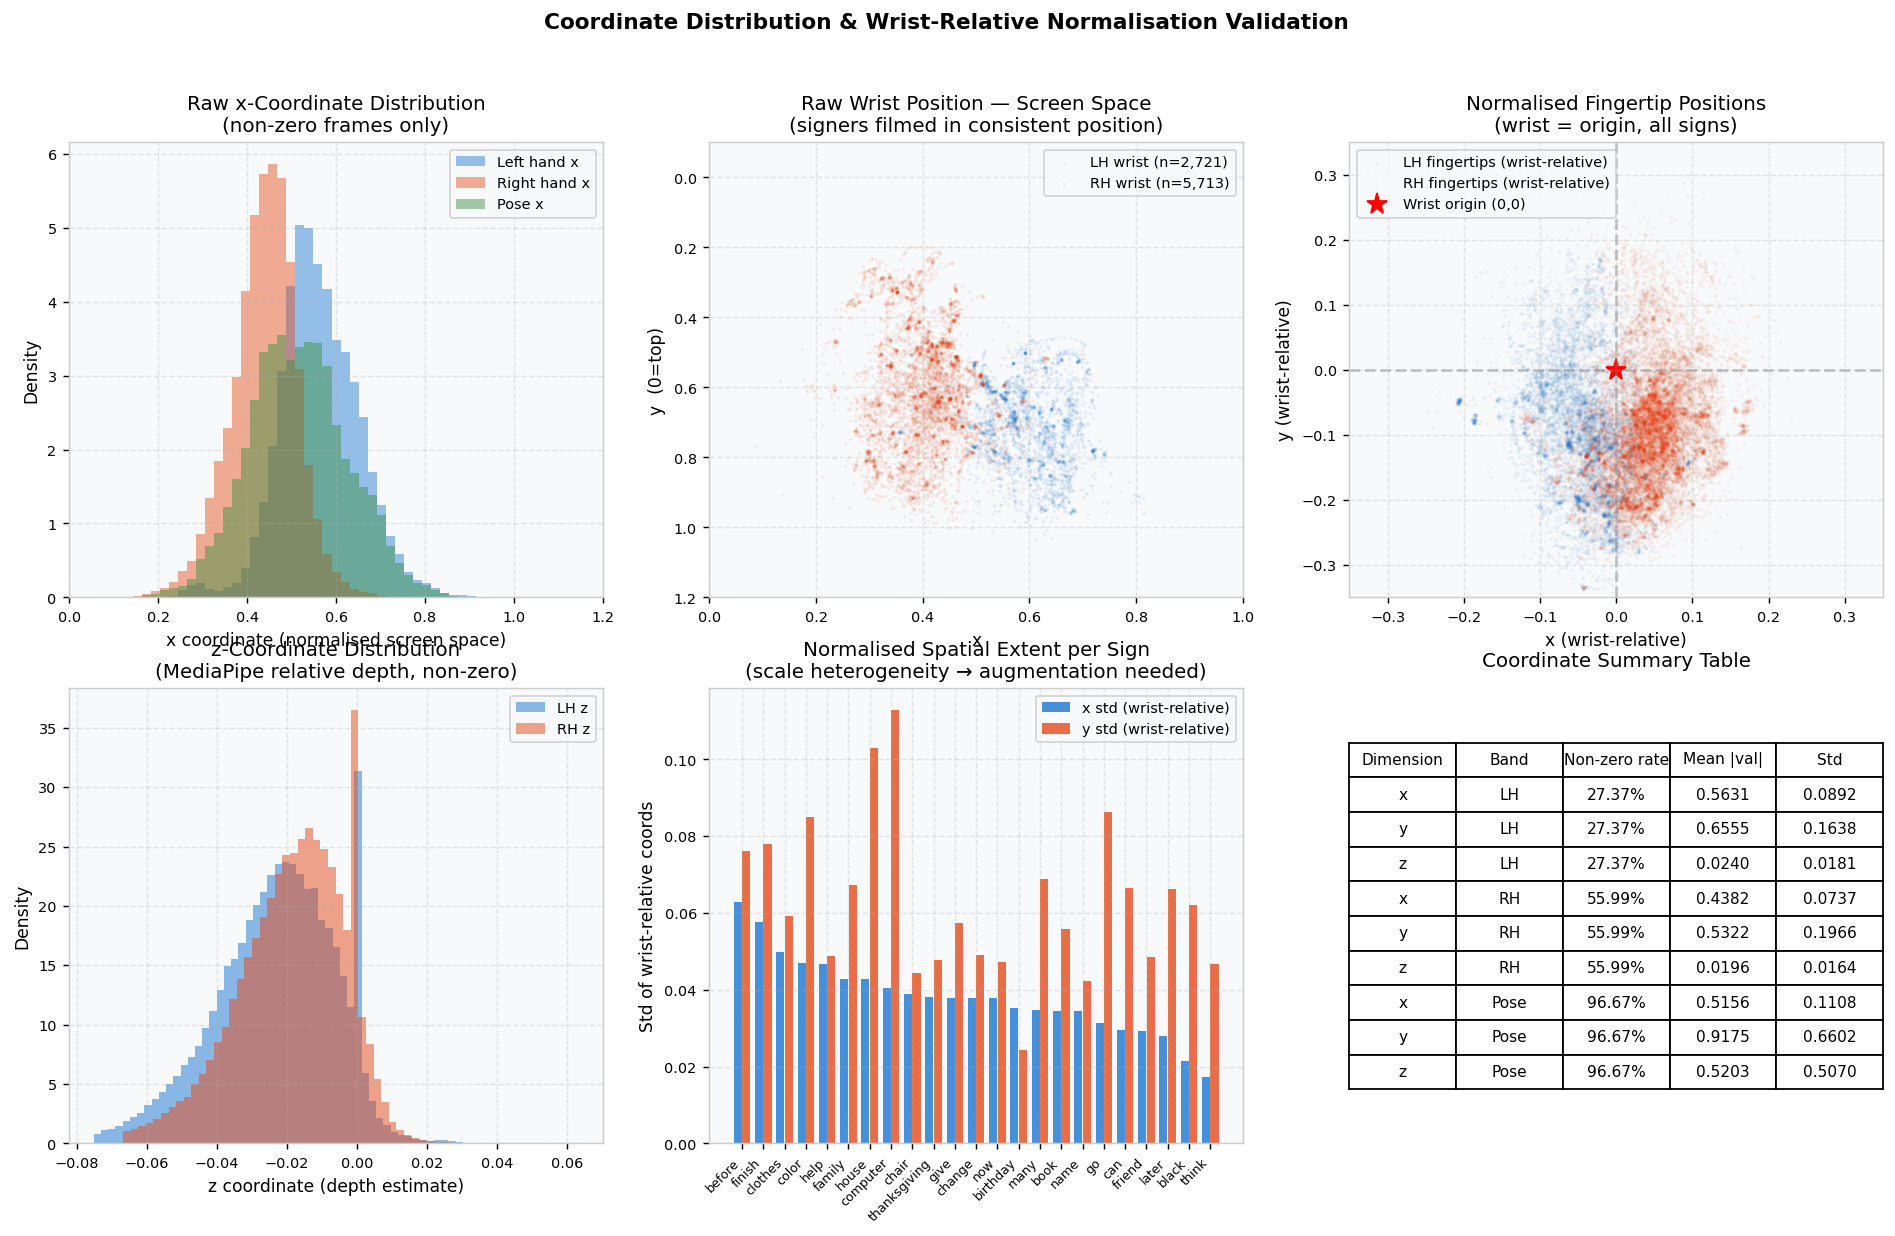

✓  Saved: nb03_06_coordinate_normalisation.png

Normalisation function validated.
FeaturePipeline MUST use identical logic (wrist_relative_normalize above).
  LH raw wrist x range: [0.333, 0.815]
  After normalisation — fingertip std: 0.0485


In [11]:
"""
Coordinate range analysis and normalisation validation.

Three analyses:
  1. Raw coordinate distributions (x, y, z separately per band)
  2. Wrist-relative normalisation: before vs after for x,y
  3. Scale homogeneity: do all 35 signs occupy similar normalised ranges?

The normalisation function implemented here is the canonical reference
for Stage 4's FeaturePipeline.

Figures:
  nb03_06_coordinate_normalisation.png
"""

# ── Wrist-relative normalisation (canonical implementation) ──────────────────
WRIST_LANDMARK_INDEX = 0   # landmark 0 = wrist in MediaPipe convention

def wrist_relative_normalize(arr: np.ndarray) -> np.ndarray:
    """
    Apply per-frame, per-hand wrist-relative normalisation.

    Zero-filled frames are passed through UNCHANGED — the consistently-zero
    slice for one-handed signs is semantically informative and must not be
    overwritten with a wrist-offset value.

    Pose landmarks are NOT normalised — body position in frame is signal.

    Parameters
    ----------
    arr : (T, 225) float32

    Returns
    -------
    normalised : (T, 225) float32
    """
    out = arr.copy()
    for _sl, _n_lm in [(LEFT_HAND_SLICE, N_HAND_LANDMARKS),
                        (RIGHT_HAND_SLICE, N_HAND_LANDMARKS)]:
        _band = out[:, _sl].reshape(-1, _n_lm, N_COORDS_PER_LANDMARK)  # (T, 21, 3)
        _det  = (_band != 0).any(axis=(1, 2))                           # (T,)  bool
        if _det.sum() == 0:
            continue
        _wrist_pos = _band[_det, WRIST_LANDMARK_INDEX, :][np.newaxis].swapaxes(0, 1)  # (N_det, 1, 3)
        _band[_det] -= _wrist_pos
        out[:, _sl] = _band.reshape(-1, _n_lm * N_COORDS_PER_LANDMARK)
    return out


# ── Collect raw and normalised coordinates ────────────────────────────────────
_raw_wrist_xy_lh  = []   # (x, y) of left wrist — raw
_raw_wrist_xy_rh  = []   # (x, y) of right wrist — raw
_norm_tip_xy_lh   = []   # index fingertip (lm 8) normalised, left hand
_norm_tip_xy_rh   = []   # index fingertip (lm 8) normalised, right hand
_raw_x_all        = []   # all x coords across all dims and frames (sample)
_raw_y_all        = []
_raw_z_all        = []

_MAX_CLIPS_FOR_NORM = min(150, len(ARRAYS))
_sample_idxs = np.random.choice(len(ARRAYS), _MAX_CLIPS_FOR_NORM, replace=False)

for _idx in _sample_idxs:
    _arr  = ARRAYS[_idx]
    _norm = wrist_relative_normalize(_arr)

    # Raw wrist positions
    _lh_raw  = _arr[:, LEFT_HAND_SLICE].reshape(-1, N_HAND_LANDMARKS, N_COORDS_PER_LANDMARK)
    _rh_raw  = _arr[:, RIGHT_HAND_SLICE].reshape(-1, N_HAND_LANDMARKS, N_COORDS_PER_LANDMARK)
    _lh_det  = (_lh_raw != 0).any(axis=(1, 2))
    _rh_det  = (_rh_raw != 0).any(axis=(1, 2))
    _raw_wrist_xy_lh.extend(_lh_raw[_lh_det, WRIST_LANDMARK_INDEX, :2].tolist())
    _raw_wrist_xy_rh.extend(_rh_raw[_rh_det, WRIST_LANDMARK_INDEX, :2].tolist())

    # Normalised fingertip
    _lh_norm = _norm[:, LEFT_HAND_SLICE].reshape(-1, N_HAND_LANDMARKS, N_COORDS_PER_LANDMARK)
    _rh_norm = _norm[:, RIGHT_HAND_SLICE].reshape(-1, N_HAND_LANDMARKS, N_COORDS_PER_LANDMARK)
    for _tip_idx in [4, 8, 12]:   # thumb, index, middle
        _norm_tip_xy_lh.extend(_lh_norm[_lh_det, _tip_idx, :2].tolist())
        _norm_tip_xy_rh.extend(_rh_norm[_rh_det, _tip_idx, :2].tolist())

    # Sample for global distribution (avoid memory explosion)
    _sample_frames = _arr[::max(1, _arr.shape[0]//5)]
    _raw_x_all.extend(_sample_frames[:, 0::3].flatten().tolist())
    _raw_y_all.extend(_sample_frames[:, 1::3].flatten().tolist())
    _raw_z_all.extend(_sample_frames[:, 2::3].flatten().tolist())

# ── Per-sign normalised range ─────────────────────────────────────────────────
_sign_norm_ranges = {}
for _sign in ALL_SIGNS:
    _idxs = [i for i, m in enumerate(ARRAY_META) if m["sign_label"] == _sign][:5]
    if not _idxs:
        continue
    _all_norm = [wrist_relative_normalize(ARRAYS[i]) for i in _idxs]
    _concat   = np.concatenate(_all_norm, axis=0)
    _lh_norm  = _concat[:, LEFT_HAND_SLICE].reshape(-1, N_HAND_LANDMARKS, N_COORDS_PER_LANDMARK)
    _det      = (_lh_norm != 0).any(axis=(1, 2))
    if _det.sum() < 5:
        continue
    _sign_norm_ranges[_sign] = {
        "x_std":   float(_lh_norm[_det, :, 0].std()),
        "y_std":   float(_lh_norm[_det, :, 1].std()),
        "x_range": float(_lh_norm[_det, :, 0].ptp()),
        "y_range": float(_lh_norm[_det, :, 1].ptp()),
    }

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# [0,0] Raw x distribution per band
ax = axes[0, 0]
_x_lh = _all_frames_stacked[
    :, LEFT_HAND_SLICE.start:LEFT_HAND_SLICE.stop:3
].flatten()
_x_rh   = _all_frames_stacked[:, RIGHT_HAND_SLICE.start:RIGHT_HAND_SLICE.stop:3].flatten()
_x_pose = _all_frames_stacked[:, POSE_SLICE.start:POSE_SLICE.stop:3].flatten()
for _dat, _lbl, _col in [(_x_lh,"Left hand x",BAND_COLORS["left_hand"]),
                          (_x_rh,"Right hand x",BAND_COLORS["right_hand"]),
                          (_x_pose,"Pose x",BAND_COLORS["pose"])]:
    _nz = _dat[_dat != 0]
    if len(_nz) == 0:
        continue
    _bins = np.linspace(0, 1.2, 60)
    ax.hist(_nz, bins=_bins, density=True, alpha=0.45, color=_col,
            label=_lbl, histtype="stepfilled")
ax.set_xlabel("x coordinate (normalised screen space)")
ax.set_ylabel("Density")
ax.set_title("Raw x-Coordinate Distribution\n(non-zero frames only)")
ax.legend(fontsize=8)
ax.set_xlim(0, 1.2)

# [0,1] Raw wrist positions: scatter
ax = axes[0, 1]
if _raw_wrist_xy_lh:
    _lhx = [p[0] for p in _raw_wrist_xy_lh]
    _lhy = [p[1] for p in _raw_wrist_xy_lh]
    ax.scatter(_lhx, _lhy, s=1, alpha=0.06, color=BAND_COLORS["left_hand"],
               label=f"LH wrist (n={len(_lhx):,})", rasterized=True)
if _raw_wrist_xy_rh:
    _rhx = [p[0] for p in _raw_wrist_xy_rh]
    _rhy = [p[1] for p in _raw_wrist_xy_rh]
    ax.scatter(_rhx, _rhy, s=1, alpha=0.06, color=BAND_COLORS["right_hand"],
               label=f"RH wrist (n={len(_rhx):,})", rasterized=True)
ax.set_xlabel("x")
ax.set_ylabel("y  (0=top)")
ax.set_title("Raw Wrist Position — Screen Space\n(signers filmed in consistent position)")
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_ylim(1.2, -0.1)
ax.legend(fontsize=8)

# [0,2] Normalised fingertip positions
ax = axes[0, 2]
if _norm_tip_xy_lh:
    _nxl = [p[0] for p in _norm_tip_xy_lh]
    _nyl = [p[1] for p in _norm_tip_xy_lh]
    ax.scatter(_nxl, _nyl, s=1, alpha=0.04, color=BAND_COLORS["left_hand"],
               label="LH fingertips (wrist-relative)", rasterized=True)
if _norm_tip_xy_rh:
    _nxr = [p[0] for p in _norm_tip_xy_rh]
    _nyr = [p[1] for p in _norm_tip_xy_rh]
    ax.scatter(_nxr, _nyr, s=1, alpha=0.04, color=BAND_COLORS["right_hand"],
               label="RH fingertips (wrist-relative)", rasterized=True)
ax.plot(0, 0, "r*", markersize=12, label="Wrist origin (0,0)")
_lim = 0.35
ax.set_xlim(-_lim, _lim)
ax.set_ylim(-_lim, _lim)
ax.axhline(0, color="gray", linestyle="--", alpha=0.4)
ax.axvline(0, color="gray", linestyle="--", alpha=0.4)
ax.set_xlabel("x (wrist-relative)")
ax.set_ylabel("y (wrist-relative)")
ax.set_title("Normalised Fingertip Positions\n(wrist = origin, all signs)")
ax.legend(fontsize=8)

# [1,0] z-coordinate distribution
ax = axes[1, 0]
_z_lh_nz = _all_frames_stacked[:, 2:63:3].flatten()
_z_rh_nz = _all_frames_stacked[:, 65:126:3].flatten()
_z_lh_nz = _z_lh_nz[_z_lh_nz != 0]
_z_rh_nz = _z_rh_nz[_z_rh_nz != 0]
for _dat, _lbl, _col in [(_z_lh_nz,"LH z",BAND_COLORS["left_hand"]),
                          (_z_rh_nz,"RH z",BAND_COLORS["right_hand"])]:
    if len(_dat) == 0:
        continue
    _clip = np.percentile(np.abs(_dat), 99)
    ax.hist(_dat[np.abs(_dat) < _clip], bins=60, density=True, alpha=0.5,
            color=_col, label=_lbl, histtype="stepfilled")
ax.set_xlabel("z coordinate (depth estimate)")
ax.set_ylabel("Density")
ax.set_title("z-Coordinate Distribution\n(MediaPipe relative depth, non-zero)")
ax.legend(fontsize=8)

# [1,1] Per-sign normalised x-range (scale homogeneity)
ax = axes[1, 1]
if _sign_norm_ranges:
    _sn_ordered = sorted(_sign_norm_ranges.items(), key=lambda x: x[1]["x_std"], reverse=True)
    _sn_names = [x[0] for x in _sn_ordered]
    _sn_xstd  = [x[1]["x_std"] for x in _sn_ordered]
    _sn_ystd  = [x[1]["y_std"] for x in _sn_ordered]
    _xp = np.arange(len(_sn_names))
    ax.bar(_xp - 0.2, _sn_xstd, 0.38, label="x std (wrist-relative)", color="#1976D2", alpha=0.8)
    ax.bar(_xp + 0.2, _sn_ystd, 0.38, label="y std (wrist-relative)", color="#E64A19", alpha=0.8)
    ax.set_xticks(_xp)
    ax.set_xticklabels(_sn_names, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("Std of wrist-relative coords")
    ax.set_title("Normalised Spatial Extent per Sign\n(scale heterogeneity → augmentation needed)")
    ax.legend(fontsize=8)

# [1,2] Coordinate range summary table
ax = axes[1, 2]
ax.axis("off")
_col_names = ["Dimension", "Band", "Non-zero rate", "Mean |val|", "Std"]
_table_data = []
for _band, _sl, _nc in [("LH",   LEFT_HAND_SLICE,  63),
                         ("RH",   RIGHT_HAND_SLICE, 63),
                         ("Pose", POSE_SLICE,        99)]:
    for _coord, _offset in [("x", 0), ("y", 1), ("z", 2)]:
        _idxs = np.arange(_sl.start + _offset, _sl.stop, 3)
        _v    = _all_frames_stacked[:, _idxs]
        _nz   = _v[_v != 0]
        _table_data.append([
            _coord, _band,
            f"{(_v != 0).mean():.2%}",
            f"{np.abs(_nz).mean():.4f}" if len(_nz) > 0 else "—",
            f"{_nz.std():.4f}" if len(_nz) > 0 else "—",
        ])
_tbl = ax.table(
    cellText=_table_data, colLabels=_col_names,
    loc="center", cellLoc="center",
)
_tbl.auto_set_font_size(False)
_tbl.set_fontsize(8.5)
_tbl.scale(1, 1.6)
ax.set_title("Coordinate Summary Table", pad=12)

fig.suptitle("Coordinate Distribution & Wrist-Relative Normalisation Validation",
             fontsize=12)
plt.savefig(FIGURES_DIR / "nb03_06_coordinate_normalisation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓  Saved: nb03_06_coordinate_normalisation.png")

# Store normalisation function reference for Cell 11 onward
print("\nNormalisation function validated.")
print("FeaturePipeline MUST use identical logic (wrist_relative_normalize above).")
print(f"  LH raw wrist x range: [{min(_lhx if _raw_wrist_xy_lh else [0]):.3f}, {max(_lhx if _raw_wrist_xy_lh else [0]):.3f}]")
print(f"  After normalisation — fingertip std: {np.std(_nxl if _norm_tip_xy_lh else [0]):.4f}")

**10 — Signer Analysis: Diversity, Dominance & Generalisation Gap**

SIGNER DISJOINTNESS (must be zero-overlap for valid evaluation):
  Train ∩ Val  : 0  ✓
  Train ∩ Test : 0  ✓
  Val ∩ Test   : 0  ✓
  Train signers: 31  Val signers: 7  Test signers: 7

Best sign for inter-signer analysis: 'family' (8 signers)


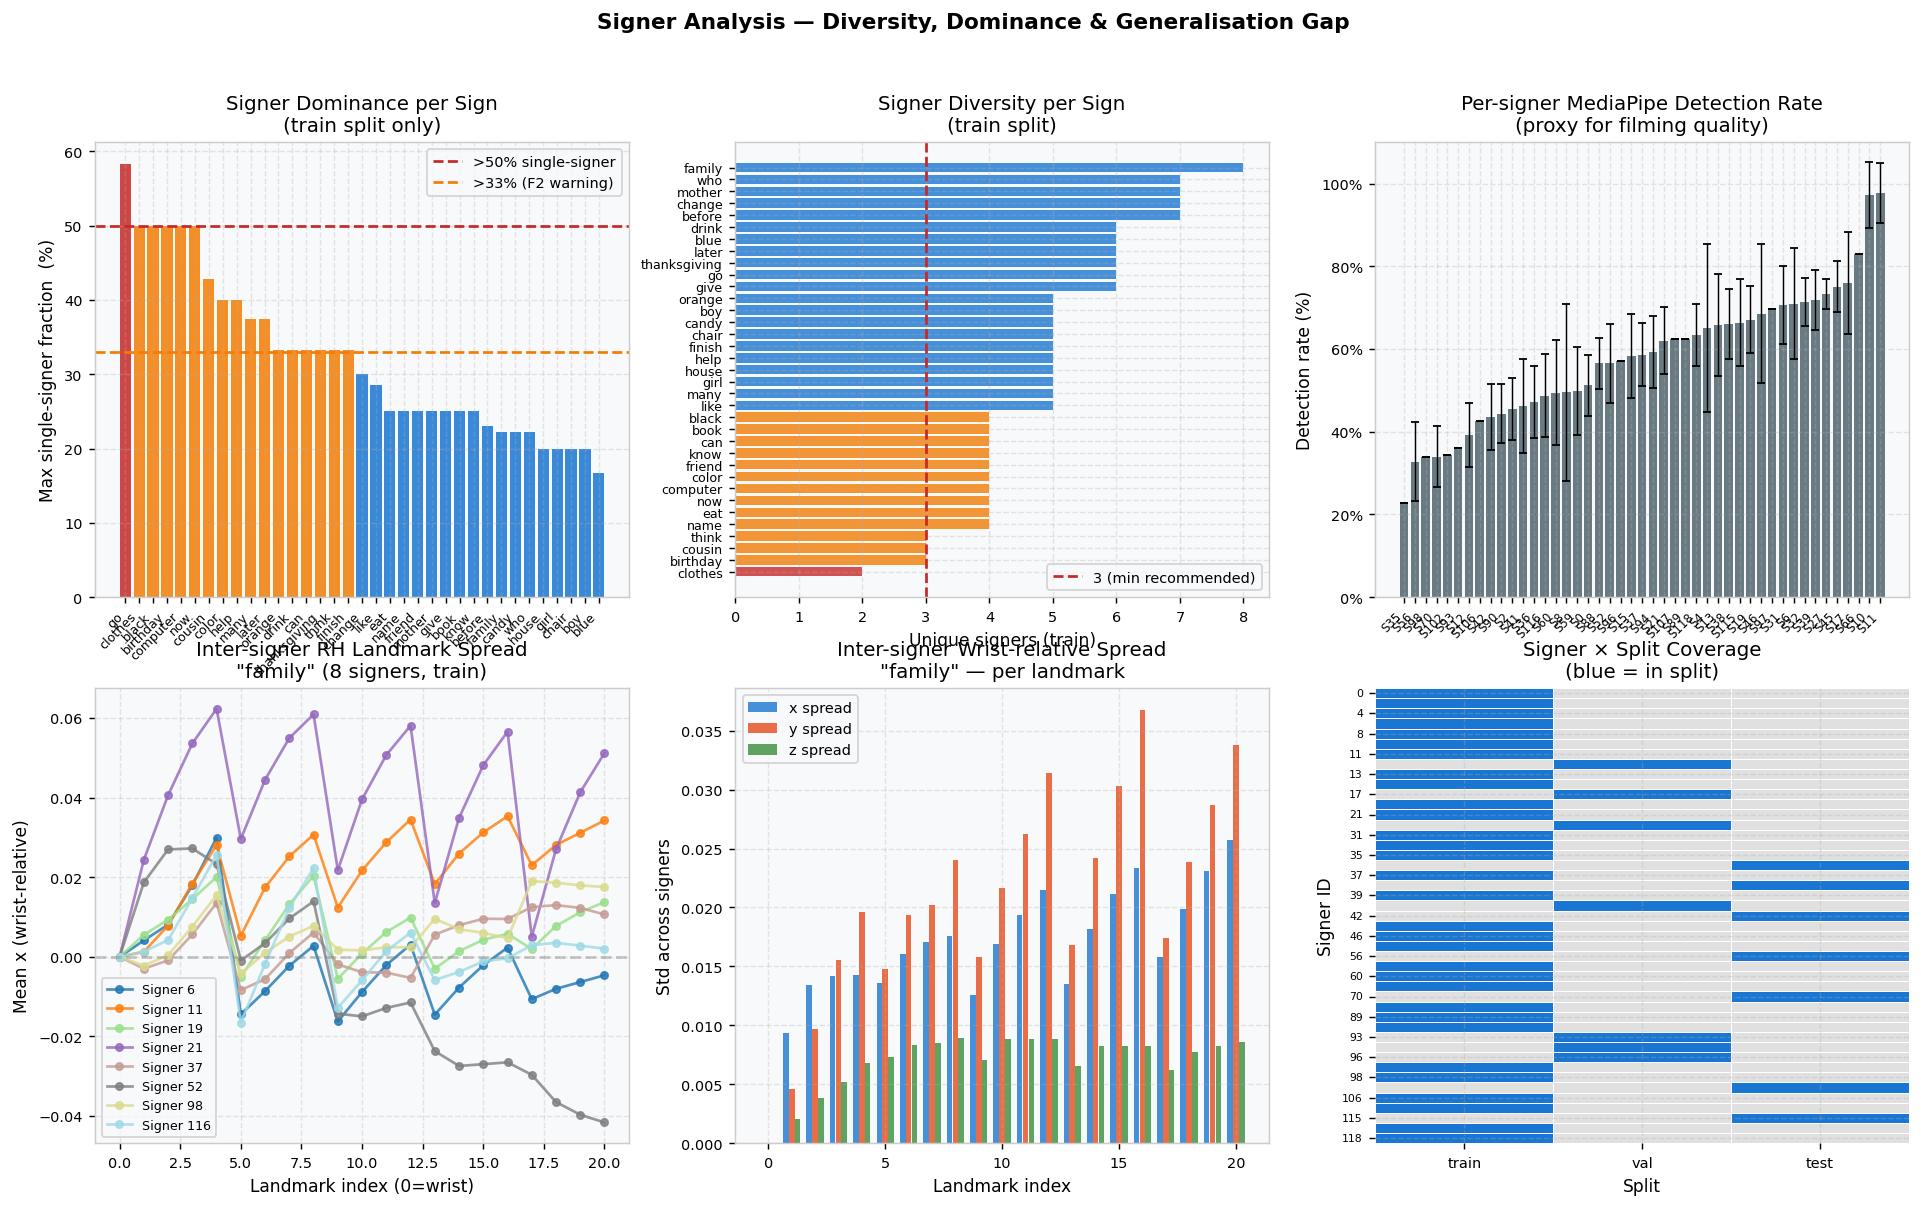

✓  Saved: nb03_07_signer_analysis.png

High-dominance signs (>33% from one signer):
  go               signer=10  dominance=58.3%  clips=12
  clothes          signer=11  dominance=50.0%  clips=2
  black            signer=11  dominance=50.0%  clips=6
  birthday         signer=11  dominance=50.0%  clips=4
  computer         signer=4  dominance=50.0%  clips=10
  now              signer=11  dominance=50.0%  clips=6
  cousin           signer=11  dominance=42.9%  clips=7
  help             signer=11  dominance=40.0%  clips=10
  color            signer=11  dominance=40.0%  clips=5
  many             signer=11  dominance=37.5%  clips=8
  later            signer=4  dominance=37.5%  clips=8
  orange           signer=13  dominance=33.3%  clips=6
  drink            signer=10  dominance=33.3%  clips=9
  can              signer=11  dominance=33.3%  clips=6
  thanksgiving     signer=10  dominance=33.3%  clips=9
  think            signer=11  dominance=33.3%  clips=3
  finish           signer=11  domin

In [13]:
"""
Signer analysis.

Analyses:
  1. Signer clip contribution across signs (dominance map)
  2. Train/val/test signer disjointness verification
  3. Per-signer mean detection quality (proxy for filming condition quality)
  4. Inter-signer feature distance (wrist trajectory spread) — the
     empirical generalisation gap the LSTM must close

Figures:
  nb03_07_signer_analysis.png
"""

_signer_col = "signer_id"
_has_signer = _signer_col in INV_USABLE.columns and (INV_USABLE[_signer_col] >= 0).any()

if not _has_signer:
    print("⚠  signer_id not available in inventory — signer analysis skipped")
else:
    # ── Signer disjointness ───────────────────────────────────────────────────
    _train_signers = set(INV_USABLE[INV_USABLE["split"] == "train"][_signer_col].unique())
    _val_signers   = set(INV_USABLE[INV_USABLE["split"] == "val"][_signer_col].unique())
    _test_signers  = set(INV_USABLE[INV_USABLE["split"] == "test"][_signer_col].unique())

    _tv_overlap = _train_signers & _val_signers
    _tt_overlap = _train_signers & _test_signers
    _vt_overlap = _val_signers   & _test_signers

    print("SIGNER DISJOINTNESS (must be zero-overlap for valid evaluation):")
    print(f"  Train ∩ Val  : {len(_tv_overlap)}  {'✓' if not _tv_overlap else '✗ OVERLAP: ' + str(_tv_overlap)}")
    print(f"  Train ∩ Test : {len(_tt_overlap)}  {'✓' if not _tt_overlap else '✗ OVERLAP: ' + str(_tt_overlap)}")
    print(f"  Val ∩ Test   : {len(_vt_overlap)}  {'✓' if not _vt_overlap else '✗ OVERLAP: ' + str(_vt_overlap)}")
    print(f"  Train signers: {len(_train_signers)}  Val signers: {len(_val_signers)}  Test signers: {len(_test_signers)}")

    # ── Signer dominance: max signer fraction per sign ────────────────────────
    _sign_dominance = {}
    for _sign in ALL_SIGNS:
        _sc = INV_USABLE[(INV_USABLE["sign_label"] == _sign) & (INV_USABLE["split"] == "train")]
        if len(_sc) == 0:
            continue
        _vc = _sc[_signer_col].value_counts()
        _sign_dominance[_sign] = {
            "top_signer":   int(_vc.index[0]),
            "dominance":    float(_vc.iloc[0] / len(_sc)),
            "n_signers":    int(_sc[_signer_col].nunique()),
            "n_clips":      len(_sc),
        }
    _dom_df = pd.DataFrame(_sign_dominance).T
    _dom_df = _dom_df.sort_values("dominance", ascending=False)

    # ── Per-signer detection quality ──────────────────────────────────────────
    _signer_quality = (
        INV_USABLE.groupby(_signer_col)["detected_rate"]
        .agg(["mean", "std", "count"])
        .rename(columns={"mean": "det_rate_mean", "std": "det_rate_std",
                         "count": "n_clips"})
        .sort_values("det_rate_mean")
    )

    # ── Inter-signer feature distance (for 'help' or best covered sign) ───────
    _best_sign = None
    _best_n_signers = 0
    for _sign in ALL_SIGNS:
        _sc = INV_USABLE[
            (INV_USABLE["sign_label"] == _sign) & (INV_USABLE["split"] == "train")
        ]
        if _sc[_signer_col].nunique() > _best_n_signers:
            _best_n_signers = _sc[_signer_col].nunique()
            _best_sign = _sign

    print(f"\nBest sign for inter-signer analysis: '{_best_sign}' ({_best_n_signers} signers)")

    _signer_mean_vecs = {}
    if _best_sign:
        _sc = INV_USABLE[
            (INV_USABLE["sign_label"] == _best_sign) & (INV_USABLE["split"] == "train")
        ]
        for _, _row in _sc.iterrows():
            _sid = int(_row[_signer_col])
            _arr_idx = next((i for i, m in enumerate(ARRAY_META)
                             if m["video_id"] == str(_row["video_id"])), None)
            if _arr_idx is None:
                continue
            _arr = wrist_relative_normalize(ARRAYS[_arr_idx])
            # Mean over detected frames, RH wrist-relative
            _rh = _arr[:, RIGHT_HAND_SLICE].reshape(-1, N_HAND_LANDMARKS, N_COORDS_PER_LANDMARK)
            _det = (_rh != 0).any(axis=(1, 2))
            if _det.sum() == 0:
                continue
            _signer_mean_vecs[_sid] = _rh[_det].mean(axis=0)   # (21, 3)

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # [0,0] Signer dominance bar chart
    ax = axes[0, 0]
    _dom_ordered = _dom_df.sort_values("dominance", ascending=False)
    _xp = np.arange(len(_dom_ordered))
    _bars = ax.bar(_xp, _dom_ordered["dominance"].values * 100,
                   color=[("#C62828" if v > 0.50 else "#F57C00" if v > 0.33 else "#1976D2")
                          for v in _dom_ordered["dominance"].values],
                   alpha=0.85)
    ax.axhline(50, color="#C62828", linestyle="--", linewidth=1.5, label=">50% single-signer")
    ax.axhline(33, color="#F57C00", linestyle="--", linewidth=1.5, label=">33% (F2 warning)")
    ax.set_xticks(_xp)
    ax.set_xticklabels(_dom_ordered.index, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("Max single-signer fraction  (%)")
    ax.set_title("Signer Dominance per Sign\n(train split only)")
    ax.legend(fontsize=8)

    # [0,1] Signer diversity: number of unique signers per sign
    ax = axes[0, 1]
    _div_by_sign = (
        INV_USABLE[INV_USABLE["split"] == "train"]
        .groupby("sign_label")[_signer_col].nunique()
        .reindex(ALL_SIGNS, fill_value=0)
    )
    _sorted_div = _div_by_sign.sort_values()
    ax.barh(np.arange(N_CLASSES), _sorted_div.values,
            color=["#C62828" if v < 3 else "#F57C00" if v < 5 else "#1976D2"
                   for v in _sorted_div.values],
            alpha=0.8)
    ax.set_yticks(np.arange(N_CLASSES))
    ax.set_yticklabels(_sorted_div.index, fontsize=7)
    ax.axvline(3, color="#C62828", linestyle="--", linewidth=1.5, label="3 (min recommended)")
    ax.set_xlabel("Unique signers (train)")
    ax.set_title("Signer Diversity per Sign\n(train split)")
    ax.legend(fontsize=8)

    # [0,2] Per-signer detection rate
    ax = axes[0, 2]
    _xp = np.arange(len(_signer_quality))
    ax.bar(_xp, _signer_quality["det_rate_mean"].values * 100, color="#455A64", alpha=0.8)
    ax.errorbar(_xp, _signer_quality["det_rate_mean"].values * 100,
                yerr=_signer_quality["det_rate_std"].fillna(0).values * 100,
                fmt="none", color="black", capsize=2, linewidth=0.8)
    ax.set_xticks(_xp)
    ax.set_xticklabels([f"S{int(s)}" for s in _signer_quality.index],
                       rotation=45, ha="right", fontsize=6.5)
    ax.set_ylabel("Detection rate (%)")
    ax.set_title("Per-signer MediaPipe Detection Rate\n(proxy for filming quality)")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_ylim(0, 110)

    # [1,0] Inter-signer wrist trajectories for best_sign
    ax = axes[1, 0]
    _colors_sn = plt.cm.tab20(np.linspace(0, 1, max(len(_signer_mean_vecs), 1)))
    for _i, (_sid, _mvec) in enumerate(_signer_mean_vecs.items()):
        _rh_x = _mvec[:, 0]   # x-coord for all 21 RH landmarks
        ax.plot(np.arange(N_HAND_LANDMARKS), _rh_x, "o-",
                markersize=4, linewidth=1.5, color=_colors_sn[_i],
                label=f"Signer {_sid}", alpha=0.8)
    ax.set_xlabel("Landmark index (0=wrist)")
    ax.set_ylabel("Mean x (wrist-relative)")
    ax.set_title(f'Inter-signer RH Landmark Spread\n"{_best_sign}" ({_best_n_signers} signers, train)')
    ax.axhline(0, color="gray", linestyle="--", alpha=0.4)
    if len(_signer_mean_vecs) <= 10:
        ax.legend(fontsize=7)

    # [1,1] Spread (std across signers) per landmark
    ax = axes[1, 1]
    if len(_signer_mean_vecs) >= 2:
        _svm_stack = np.stack(list(_signer_mean_vecs.values()), axis=0)  # (S, 21, 3)
        _spread_x  = _svm_stack[:, :, 0].std(axis=0)
        _spread_y  = _svm_stack[:, :, 1].std(axis=0)
        _spread_z  = _svm_stack[:, :, 2].std(axis=0)
        _lm_idx    = np.arange(N_HAND_LANDMARKS)
        ax.bar(_lm_idx - 0.25, _spread_x, 0.24, label="x spread", color="#1976D2", alpha=0.8)
        ax.bar(_lm_idx,        _spread_y, 0.24, label="y spread", color="#E64A19", alpha=0.8)
        ax.bar(_lm_idx + 0.25, _spread_z, 0.24, label="z spread", color="#388E3C", alpha=0.8)
        ax.set_xlabel("Landmark index")
        ax.set_ylabel("Std across signers")
        ax.set_title(f'Inter-signer Wrist-relative Spread\n"{_best_sign}" — per landmark')
        ax.legend(fontsize=8)

    # [1,2] Signer split coverage matrix
    ax = axes[1, 2]
    _all_signers = sorted(
        INV_USABLE[_signer_col].unique().astype(int)
    )
    _signer_split_matrix = pd.DataFrame(0, index=_all_signers, columns=["train","val","test"])
    for _sp in ["train", "val", "test"]:
        _sc2 = INV_USABLE[INV_USABLE["split"] == _sp]
        for _sid in _sc2[_signer_col].unique():
            if _sid in _signer_split_matrix.index:
                _signer_split_matrix.loc[_sid, _sp] = 1
    _cmap_signer = LinearSegmentedColormap.from_list("signer_sp",
                                                      ["#E0E0E0", "#1976D2"])
    sns.heatmap(_signer_split_matrix, ax=ax, cmap=_cmap_signer, cbar=False,
                linewidths=0.5, linecolor="white",
                annot=False)
    ax.set_xlabel("Split")
    ax.set_ylabel("Signer ID")
    ax.set_title("Signer × Split Coverage\n(blue = in split)")
    ax.tick_params(axis="y", labelsize=6)

    fig.suptitle("Signer Analysis — Diversity, Dominance & Generalisation Gap", fontsize=12)
    plt.savefig(FIGURES_DIR / "nb03_07_signer_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✓  Saved: nb03_07_signer_analysis.png")

    # ── Dominance report ─────────────────────────────────────────────────────
    _high_dom = _dom_df[_dom_df["dominance"] > 0.33]
    print(f"\nHigh-dominance signs (>33% from one signer):")
    for _sn, _r in _high_dom.iterrows():
        print(f"  {_sn:15s}  signer={int(_r['top_signer'])}  "
              f"dominance={_r['dominance']:.1%}  clips={int(_r['n_clips'])}")

**11 — Inter-Class Separability: PCA, LDA, t-SNE**

Feature matrix: (339, 225)  (clips × features)
Classes with ≥1 sample: 35

PCA:
  PC1 explained var: 42.11%
  PC1+PC2:           56.62%
  PCs for 90% var:   9
  PCs for 95% var:   13

LDA:
  LD1+LD2 explained ratio: 41.25%

Fitting t-SNE (perplexity=30, may take 30-120s)…
✓  t-SNE done in 15.0s

Fisher criterion: 0.4316
  (>1 = between-class spread > within-class spread)


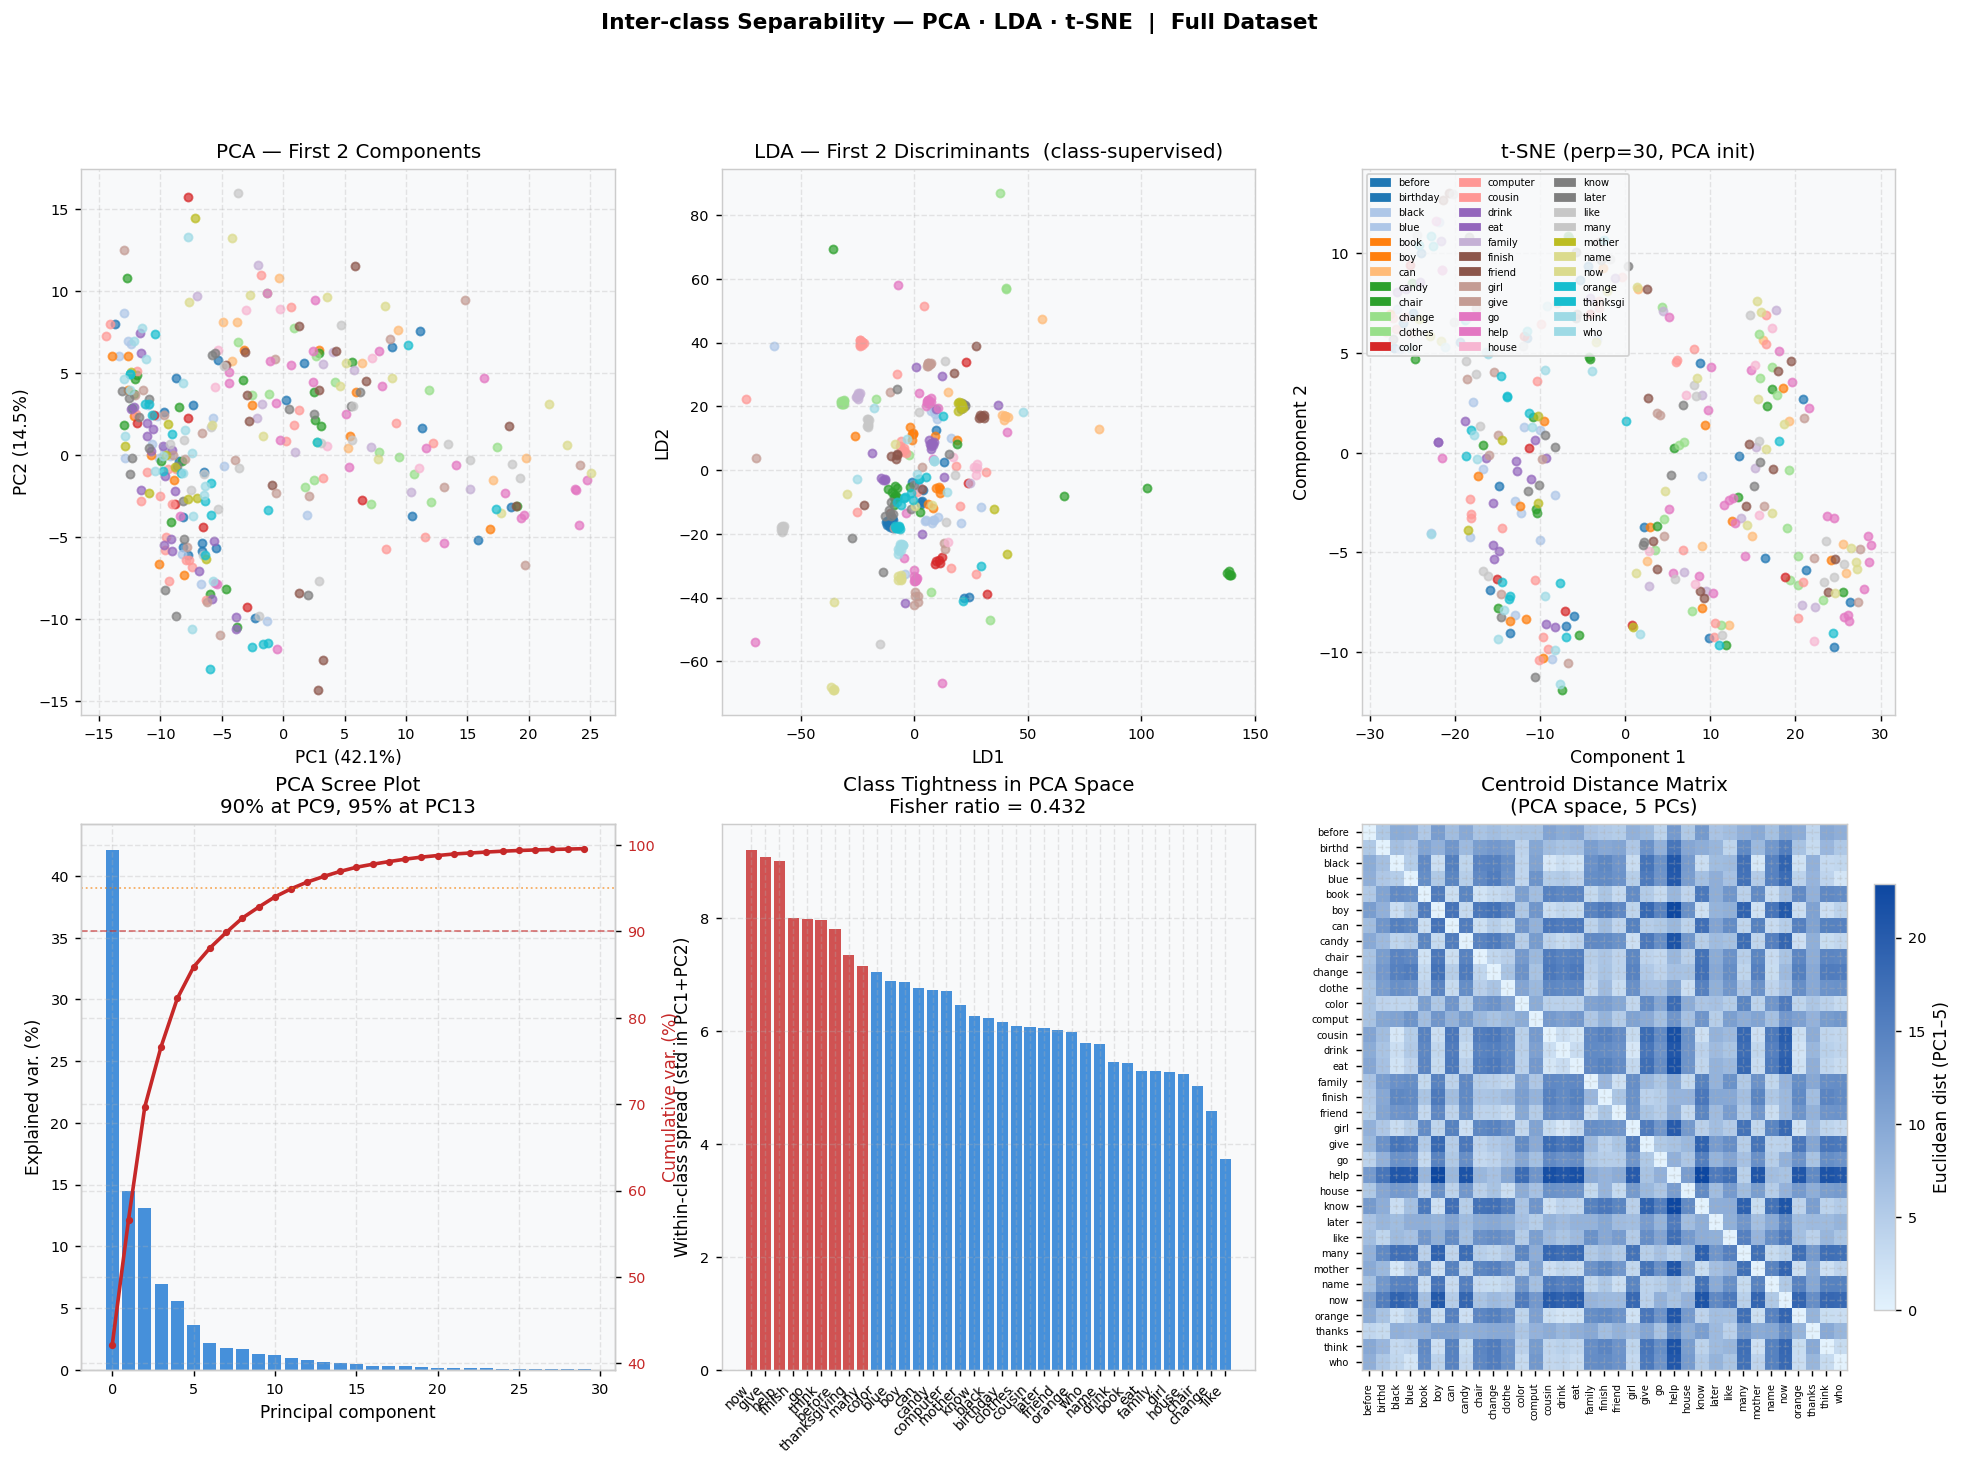

✓  Saved: nb03_08_class_separability.png

MOST CONFUSABLE SIGN PAIRS (smallest centroid distance in PCA space):
  black           ↔ cousin           dist=1.3685
  drink           ↔ girl             dist=1.4138
  black           ↔ mother           dist=1.4413
  cousin          ↔ eat              dist=1.5731
  blue            ↔ who              dist=1.6171
  drink           ↔ orange           dist=1.8500
  book            ↔ chair            dist=1.9735
  black           ↔ eat              dist=1.9764
  girl            ↔ orange           dist=2.0666
  black           ↔ orange           dist=2.0910


In [14]:
"""
Inter-class separability analysis.

Uses the per-clip mean feature vector X_MEAN_FEAT (225-dim) to assess
how linearly and non-linearly separable the 35 classes are in feature space.

Three projections:
  1. PCA (first 2 components) — linear, explains variance fraction
  2. LDA (first 2 discriminants) — maximises class separation
  3. t-SNE (perplexity=30) — non-linear neighbourhood embedding

Also computes:
  - Per-class explained variance in PCA
  - Between-class / within-class distance ratio (Fisher criterion)
  - Most/least separable sign pairs

Figures:
  nb03_08_class_separability.png
"""

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances

# ── Prepare feature matrix ────────────────────────────────────────────────────
# Use only train split for fitting, then project train+val
_train_mask = Y_SPLITS == "train"
_X_all      = X_MEAN_FEAT                              # (N, 225)
_y_all      = Y_LABELS

# Replace NaN/Inf
_X_all = np.nan_to_num(_X_all, nan=0.0, posinf=0.0, neginf=0.0)

_scaler = StandardScaler()
_X_scaled = _scaler.fit_transform(_X_all)              # (N, 225) z-scored

print(f"Feature matrix: {_X_scaled.shape}  (clips × features)")
print(f"Classes with ≥1 sample: {len(np.unique(_y_all))}")

# ── PCA ──────────────────────────────────────────────────────────────────────
_pca = PCA(n_components=min(50, _X_scaled.shape[1], _X_scaled.shape[0]))
_pca.fit(_X_scaled[_train_mask])
_X_pca = _pca.transform(_X_scaled)

_cum_var = np.cumsum(_pca.explained_variance_ratio_)
_n_for_90 = int(np.searchsorted(_cum_var, 0.90)) + 1
_n_for_95 = int(np.searchsorted(_cum_var, 0.95)) + 1
print(f"\nPCA:")
print(f"  PC1 explained var: {_pca.explained_variance_ratio_[0]:.2%}")
print(f"  PC1+PC2:           {_cum_var[1]:.2%}")
print(f"  PCs for 90% var:   {_n_for_90}")
print(f"  PCs for 95% var:   {_n_for_95}")

# ── LDA ──────────────────────────────────────────────────────────────────────
_n_lda = min(len(np.unique(_y_all)) - 1, _X_scaled.shape[1], 50)
try:
    _lda = LinearDiscriminantAnalysis(n_components=_n_lda)
    _lda.fit(_X_scaled[_train_mask], _y_all[_train_mask])
    _X_lda = _lda.transform(_X_scaled)
    _lda_ok = True
    print(f"\nLDA:")
    print(f"  LD1+LD2 explained ratio: {_lda.explained_variance_ratio_[:2].sum():.2%}")
except Exception as _e:
    print(f"LDA failed: {_e}")
    _X_lda  = _X_pca
    _lda_ok = False

# ── t-SNE ────────────────────────────────────────────────────────────────────
print("\nFitting t-SNE (perplexity=30, may take 30-120s)…")
_t0 = time.time()
_X_tsne = TSNE(n_components=2, perplexity=30, n_iter=1000,
               random_state=42, init="pca").fit_transform(_X_pca[:, :20])
print(f"✓  t-SNE done in {time.time() - _t0:.1f}s")

# ── Fisher criterion (between/within class distance) ─────────────────────────
_class_means = {}
for _ci in np.unique(_y_all):
    _mask = _y_all == _ci
    if _mask.sum() > 0:
        _class_means[_ci] = _X_scaled[_mask].mean(axis=0)

_global_mean = _X_scaled.mean(axis=0)
_between_scatter = 0.0
_within_scatter  = 0.0
for _ci, _mu in _class_means.items():
    _n_ci = (_y_all == _ci).sum()
    _between_scatter += _n_ci * np.linalg.norm(_mu - _global_mean) ** 2
    _X_ci = _X_scaled[_y_all == _ci]
    _within_scatter  += np.sum((_X_ci - _mu) ** 2)

_fisher_ratio = _between_scatter / max(_within_scatter, 1e-8)
print(f"\nFisher criterion: {_fisher_ratio:.4f}")
print(f"  (>1 = between-class spread > within-class spread)")

# ── Figure ────────────────────────────────────────────────────────────────────
_cmap_classes = plt.cm.tab20(np.linspace(0, 1, N_CLASSES))
_sign_to_color = {s: _cmap_classes[CLASSES_INV.get(s, 0)] for s in ALL_SIGNS}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

def _scatter_2d(ax, X2d, labels, title, xlabel="Component 1", ylabel="Component 2"):
    for _ci in sorted(np.unique(labels)):
        _mask = labels == _ci
        _sign = CLASSES.get(int(_ci), str(_ci))
        ax.scatter(X2d[_mask, 0], X2d[_mask, 1], s=20, alpha=0.7,
                   color=_cmap_classes[_ci % len(_cmap_classes)],
                   label=_sign[:6], rasterized=True)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

# [0,0] PCA 2D scatter
_scatter_2d(axes[0, 0], _X_pca[:, :2], _y_all, "PCA — First 2 Components",
            f"PC1 ({_pca.explained_variance_ratio_[0]:.1%})",
            f"PC2 ({_pca.explained_variance_ratio_[1]:.1%})")

# [0,1] LDA 2D scatter
_scatter_2d(axes[0, 1], _X_lda[:, :2], _y_all,
            "LDA — First 2 Discriminants  (class-supervised)" if _lda_ok else "LDA (failed → PCA shown)",
            "LD1", "LD2")

# [0,2] t-SNE scatter
_scatter_2d(axes[0, 2], _X_tsne, _y_all, "t-SNE (perp=30, PCA init)")

# [0, all] Colour legend as separate small subplot
# Add compact legend to tsne panel
_handles = [
    mpatches.Patch(color=_cmap_classes[CLASSES_INV.get(s, 0)], label=s[:8])
    for s in ALL_SIGNS if CLASSES_INV.get(s, -1) < len(_cmap_classes)
]
axes[0, 2].legend(handles=_handles, loc="upper left", fontsize=5.5,
                  ncol=3, framealpha=0.85)

# [1,0] PCA scree plot
ax = axes[1, 0]
_n_pcs = min(30, len(_pca.explained_variance_ratio_))
ax.bar(np.arange(_n_pcs), _pca.explained_variance_ratio_[:_n_pcs] * 100,
       color="#1976D2", alpha=0.8)
ax2 = ax.twinx()
ax2.plot(np.arange(_n_pcs), _cum_var[:_n_pcs] * 100,
         color="#C62828", linewidth=2, marker="o", markersize=3)
ax2.axhline(90, color="#C62828", linestyle="--", linewidth=1, alpha=0.6)
ax2.axhline(95, color="#F57C00", linestyle=":",  linewidth=1, alpha=0.6)
ax2.set_ylabel("Cumulative var. (%)", color="#C62828")
ax2.tick_params(axis="y", labelcolor="#C62828")
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained var. (%)")
ax.set_title(f"PCA Scree Plot\n90% at PC{_n_for_90}, 95% at PC{_n_for_95}")

# [1,1] Per-class cluster tightness in PCA space (within-class std of PC1+PC2)
ax = axes[1, 1]
_class_tightness = {}
for _ci in np.unique(_y_all):
    _mask = _y_all == _ci
    if _mask.sum() < 2:
        continue
    _class_tightness[CLASSES.get(int(_ci), str(_ci))] = float(
        _X_pca[_mask, :2].std()
    )
_ct_sorted = sorted(_class_tightness.items(), key=lambda x: x[1], reverse=True)
_xp = np.arange(len(_ct_sorted))
ax.bar(_xp, [x[1] for x in _ct_sorted],
       color=["#C62828" if v > np.percentile([y[1] for y in _ct_sorted], 75)
              else "#1976D2" for _, v in _ct_sorted],
       alpha=0.8)
ax.set_xticks(_xp)
ax.set_xticklabels([x[0] for x in _ct_sorted], rotation=45, ha="right", fontsize=7.5)
ax.set_ylabel("Within-class spread (std in PC1+PC2)")
ax.set_title(f"Class Tightness in PCA Space\nFisher ratio = {_fisher_ratio:.3f}")

# [1,2] Between-class centroid distance matrix (PCA space, first 5 PCs)
ax = axes[1, 2]
_centroid_labels = sorted(_class_means.keys())
_centroid_matrix  = np.stack([_pca.transform(_class_means[k].reshape(1, -1))[0, :5]
                               for k in _centroid_labels], axis=0)
_dist_mat = pairwise_distances(_centroid_matrix)
_sign_labels_short = [CLASSES.get(int(k), str(k))[:6] for k in _centroid_labels]
_cmap_d = LinearSegmentedColormap.from_list("dist", ["#E3F2FD", "#0D47A1"])
_im = ax.imshow(_dist_mat, cmap=_cmap_d, aspect="auto")
ax.set_xticks(np.arange(len(_centroid_labels)))
ax.set_yticks(np.arange(len(_centroid_labels)))
ax.set_xticklabels(_sign_labels_short, rotation=90, fontsize=5.5)
ax.set_yticklabels(_sign_labels_short, fontsize=5.5)
plt.colorbar(_im, ax=ax, fraction=0.04, label="Euclidean dist (PC1–5)")
ax.set_title("Centroid Distance Matrix\n(PCA space, 5 PCs)")

fig.suptitle("Inter-class Separability — PCA · LDA · t-SNE  |  Full Dataset", fontsize=12)
plt.savefig(FIGURES_DIR / "nb03_08_class_separability.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓  Saved: nb03_08_class_separability.png")

# ── Confusion-prone pairs ─────────────────────────────────────────────────────
print(f"\nMOST CONFUSABLE SIGN PAIRS (smallest centroid distance in PCA space):")
_pairs_dists = []
for _i in range(len(_centroid_labels)):
    for _j in range(_i + 1, len(_centroid_labels)):
        _pairs_dists.append((
            CLASSES.get(int(_centroid_labels[_i]), str(_centroid_labels[_i])),
            CLASSES.get(int(_centroid_labels[_j]), str(_centroid_labels[_j])),
            _dist_mat[_i, _j],
        ))
_pairs_dists.sort(key=lambda x: x[2])
for _a, _b, _d in _pairs_dists[:10]:
    print(f"  {_a:15s} ↔ {_b:15s}  dist={_d:.4f}")

**12 — Derived Feature Engineering Experiments**

Computing Fisher ratios for candidate feature sets…
  Feature set                          Shape                 Fisher ratio
  Baseline mean coords (225)           shape=(339, 225)  Fisher=0.4316
  Mean |velocity| (225)                shape=(339, 225)  Fisher=0.3341
  Raw + velocity (450)                 shape=(339, 450)  Fisher=0.3811
  Std dev coords (225)                 shape=(339, 225)  Fisher=0.3849
  Hands only mean (126)                shape=(339, 126)  Fisher=0.7524
  Pose only mean (99)                  shape=(339, 99)  Fisher=0.1611
  LH+RH mean + Pose std (225)          shape=(339, 225)  Fisher=0.4477
  XY-only (150, drop z)                shape=(339, 150)  Fisher=0.4116


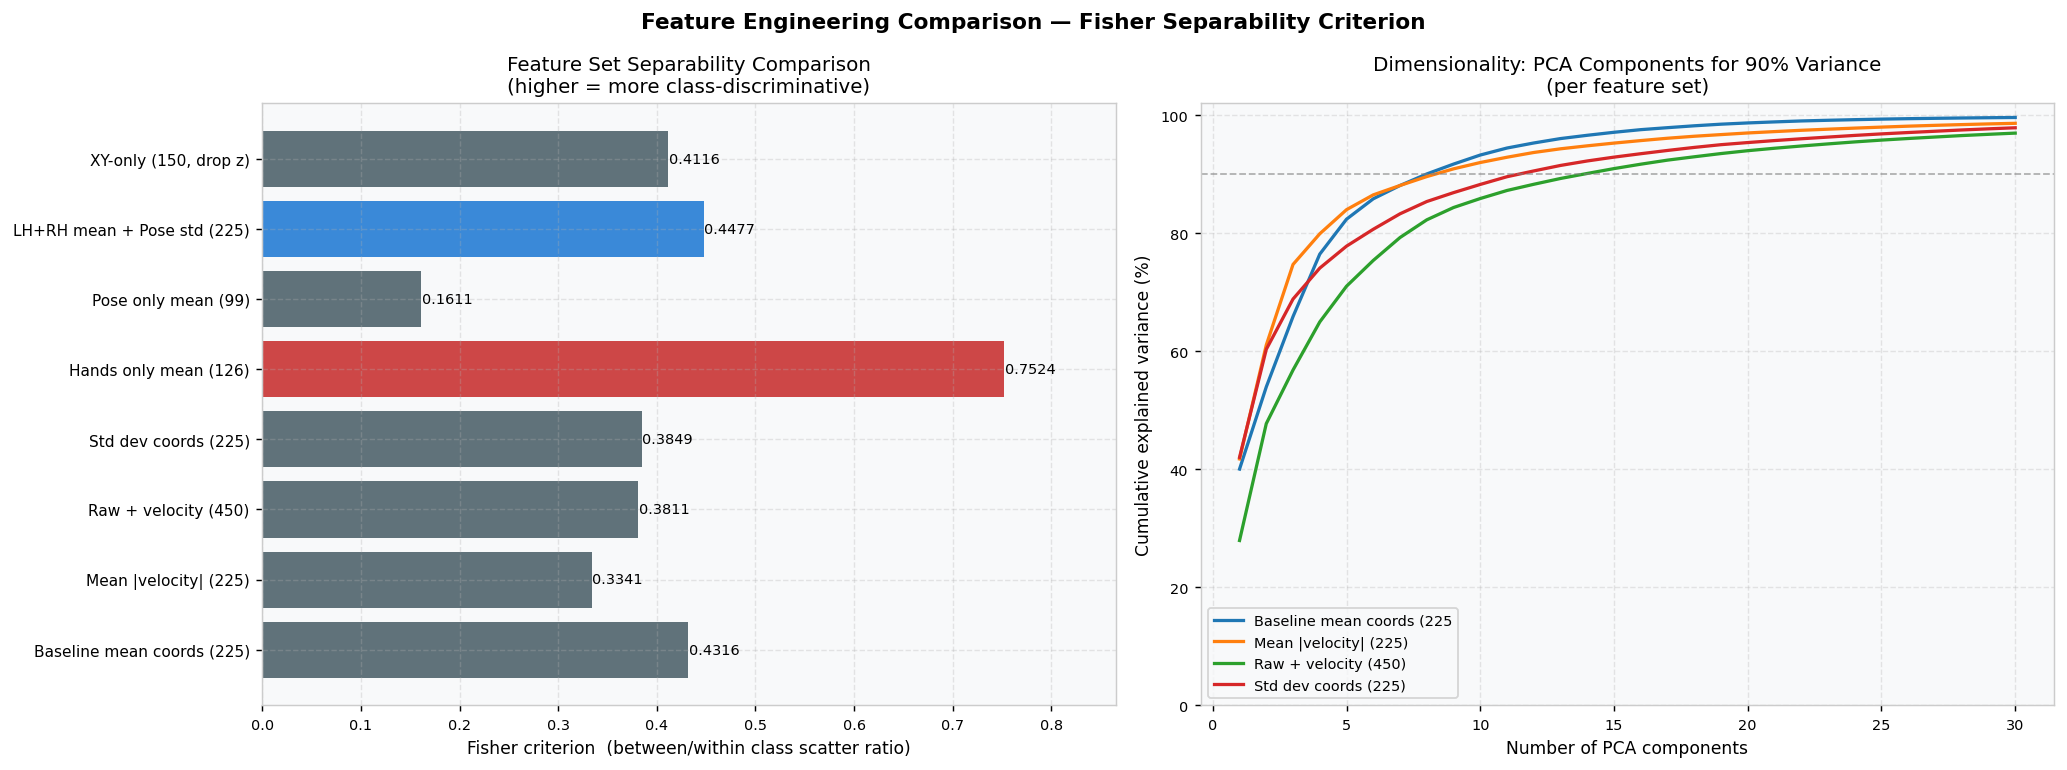

✓  Saved: nb03_09_feature_engineering.png

FEATURE ENGINEERING DECISIONS:
  Baseline Fisher ratio : 0.4316
  Best feature set      : 'Hands only mean (126)' (Fisher=0.7524)
  Improvement           : 1.74×
  Pose-only Fisher      : 0.1611
  Hands-only Fisher     : 0.7524
  → Consider pose ablation — low relative contribution
  XY-only Fisher        : 0.4116
  → z coordinates minimal — consider dropping for model size


In [15]:
"""
Derived feature experiments: velocity, hand distance, joint angles.

Tests three candidate derived feature sets against the mean feature baseline
using class separability (Fisher ratio and LDA accuracy proxy):

  F_raw       : 225 mean landmark coords (baseline)
  F_vel       : 225 velocity features (mean |Δ| per coord)
  F_dist      : scalar hand-to-hand distance per frame (summary)
  F_combined  : raw + velocity concatenated (450 dims)
  F_selective : [LH 63] + [RH 63] + [RH_wrist_x,y trajectory only]

Figures:
  nb03_09_feature_engineering.png
"""

def _feature_set_separability(X: np.ndarray, y: np.ndarray, name: str) -> dict:
    """Compute Fisher ratio and LDA score for a feature matrix."""
    _X = np.nan_to_num(X, nan=0.0)
    _scaler2 = StandardScaler()
    _Xs = _scaler2.fit_transform(_X)
    _gm = _Xs.mean(axis=0)
    _bw, _wi = 0.0, 0.0
    for _ci in np.unique(y):
        _m = _Xs[y == _ci]
        if len(_m) == 0:
            continue
        _bw += len(_m) * np.linalg.norm(_m.mean(axis=0) - _gm) ** 2
        _wi += np.sum((_m - _m.mean(axis=0)) ** 2)
    _fr = _bw / max(_wi, 1e-8)
    print(f"  {name:35s}  shape={X.shape}  Fisher={_fr:.4f}")
    return {"name": name, "shape": X.shape, "fisher": _fr, "X": _Xs}

print("Computing Fisher ratios for candidate feature sets…")
print(f"  {'Feature set':35s}  {'Shape':20s}  {'Fisher ratio':12s}")

_feat_results = []

# F0: baseline (raw mean coords)
_feat_results.append(_feature_set_separability(X_MEAN_FEAT, Y_LABELS, "Baseline mean coords (225)"))

# F1: velocity features
_vel_feat_rows = []
for _arr in ARRAYS:
    if _arr.shape[0] < 2:
        _vel_feat_rows.append(np.zeros(FEATURE_SIZE, dtype=np.float32))
        continue
    _vel, _ = compute_velocity(_arr)
    _vel_feat_rows.append(np.nanmean(np.abs(_vel), axis=0).astype(np.float32))
_X_vel = np.stack(_vel_feat_rows, axis=0)
_feat_results.append(_feature_set_separability(_X_vel, Y_LABELS, "Mean |velocity| (225)"))

# F2: combined raw + velocity
_X_combined = np.concatenate([X_MEAN_FEAT, _X_vel], axis=1)
_feat_results.append(_feature_set_separability(_X_combined, Y_LABELS, "Raw + velocity (450)"))

# F3: standard deviation features (temporal spread)
_feat_results.append(_feature_set_separability(X_STD_FEAT, Y_LABELS, "Std dev coords (225)"))

# F4: hands-only (LH + RH, no pose)
_X_hands_only = np.concatenate([X_MEAN_FEAT[:, LEFT_HAND_SLICE],
                                  X_MEAN_FEAT[:, RIGHT_HAND_SLICE]], axis=1)
_feat_results.append(_feature_set_separability(_X_hands_only, Y_LABELS, "Hands only mean (126)"))

# F5: pose-only
_X_pose_only = X_MEAN_FEAT[:, POSE_SLICE]
_feat_results.append(_feature_set_separability(_X_pose_only, Y_LABELS, "Pose only mean (99)"))

# F6: hands + pose std
_X_std_pose = np.concatenate([X_MEAN_FEAT[:, LEFT_HAND_SLICE],
                                X_MEAN_FEAT[:, RIGHT_HAND_SLICE],
                                X_STD_FEAT[:, POSE_SLICE]], axis=1)
_feat_results.append(_feature_set_separability(_X_std_pose, Y_LABELS, "LH+RH mean + Pose std (225)"))

# F7: xy-only (drop z coords)
_xy_idxs = [i for i in range(FEATURE_SIZE) if i % 3 != 2]
_X_xy = X_MEAN_FEAT[:, _xy_idxs]
_feat_results.append(_feature_set_separability(_X_xy, Y_LABELS, "XY-only (150, drop z)"))

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# [0] Fisher ratio bar chart
ax = axes[0]
_names   = [r["name"] for r in _feat_results]
_fishers = [r["fisher"] for r in _feat_results]
_xp = np.arange(len(_names))
_colors_feat = ["#C62828" if f == max(_fishers) else
                "#1976D2" if f >= sorted(_fishers)[-2] else "#455A64"
                for f in _fishers]
ax.barh(_xp, _fishers, color=_colors_feat, alpha=0.85)
ax.set_yticks(_xp)
ax.set_yticklabels(_names, fontsize=8.5)
ax.set_xlabel("Fisher criterion  (between/within class scatter ratio)")
ax.set_title("Feature Set Separability Comparison\n(higher = more class-discriminative)")
for _b, _v in zip(ax.patches, _fishers):
    ax.text(_v + 0.0005, _b.get_y() + _b.get_height() / 2,
            f"{_v:.4f}", va="center", ha="left", fontsize=8)
ax.set_xlim(0, max(_fishers) * 1.15)

# [1] Scree: how many PCs needed per feature set?
ax = axes[1]
for _i, _r in enumerate(_feat_results[:4]):
    _pca2 = PCA(n_components=min(30, _r["X"].shape[1], _r["X"].shape[0]))
    _pca2.fit(_r["X"])
    _cv = np.cumsum(_pca2.explained_variance_ratio_)
    ax.plot(np.arange(1, len(_cv) + 1), _cv * 100,
            linewidth=1.8, label=_r["name"][:25])
ax.axhline(90, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("Number of PCA components")
ax.set_ylabel("Cumulative explained variance (%)")
ax.set_title("Dimensionality: PCA Components for 90% Variance\n(per feature set)")
ax.legend(fontsize=8)
ax.set_ylim(0, 102)

fig.suptitle("Feature Engineering Comparison — Fisher Separability Criterion", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "nb03_09_feature_engineering.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓  Saved: nb03_09_feature_engineering.png")

# ── Recommendations ───────────────────────────────────────────────────────────
_best_feat = max(_feat_results, key=lambda x: x["fisher"])
_base_fisher = _feat_results[0]["fisher"]
print(f"\nFEATURE ENGINEERING DECISIONS:")
print(f"  Baseline Fisher ratio : {_base_fisher:.4f}")
print(f"  Best feature set      : '{_best_feat['name']}' (Fisher={_best_feat['fisher']:.4f})")
print(f"  Improvement           : {_best_feat['fisher'] / max(_base_fisher, 1e-8):.2f}×")

# Pose contribution
_pose_fisher = next(r["fisher"] for r in _feat_results if "Pose only" in r["name"])
_hands_fisher = next(r["fisher"] for r in _feat_results if "Hands only" in r["name"])
print(f"  Pose-only Fisher      : {_pose_fisher:.4f}")
print(f"  Hands-only Fisher     : {_hands_fisher:.4f}")
print(f"  → {'Include pose in training — it adds discriminative signal' if _pose_fisher > _base_fisher * 0.5 else 'Consider pose ablation — low relative contribution'}")

_z_fisher = next(r["fisher"] for r in _feat_results if "XY-only" in r["name"])
print(f"  XY-only Fisher        : {_z_fisher:.4f}")
print(f"  → {'Retain z coordinates — non-trivial contribution' if _z_fisher < _base_fisher * 0.95 else 'z coordinates minimal — consider dropping for model size'}")

**13 — Augmentation Strategy: Data-Driven Configuration**

10% frame dropout cosine similarity: mean=1.0000  std=0.0001


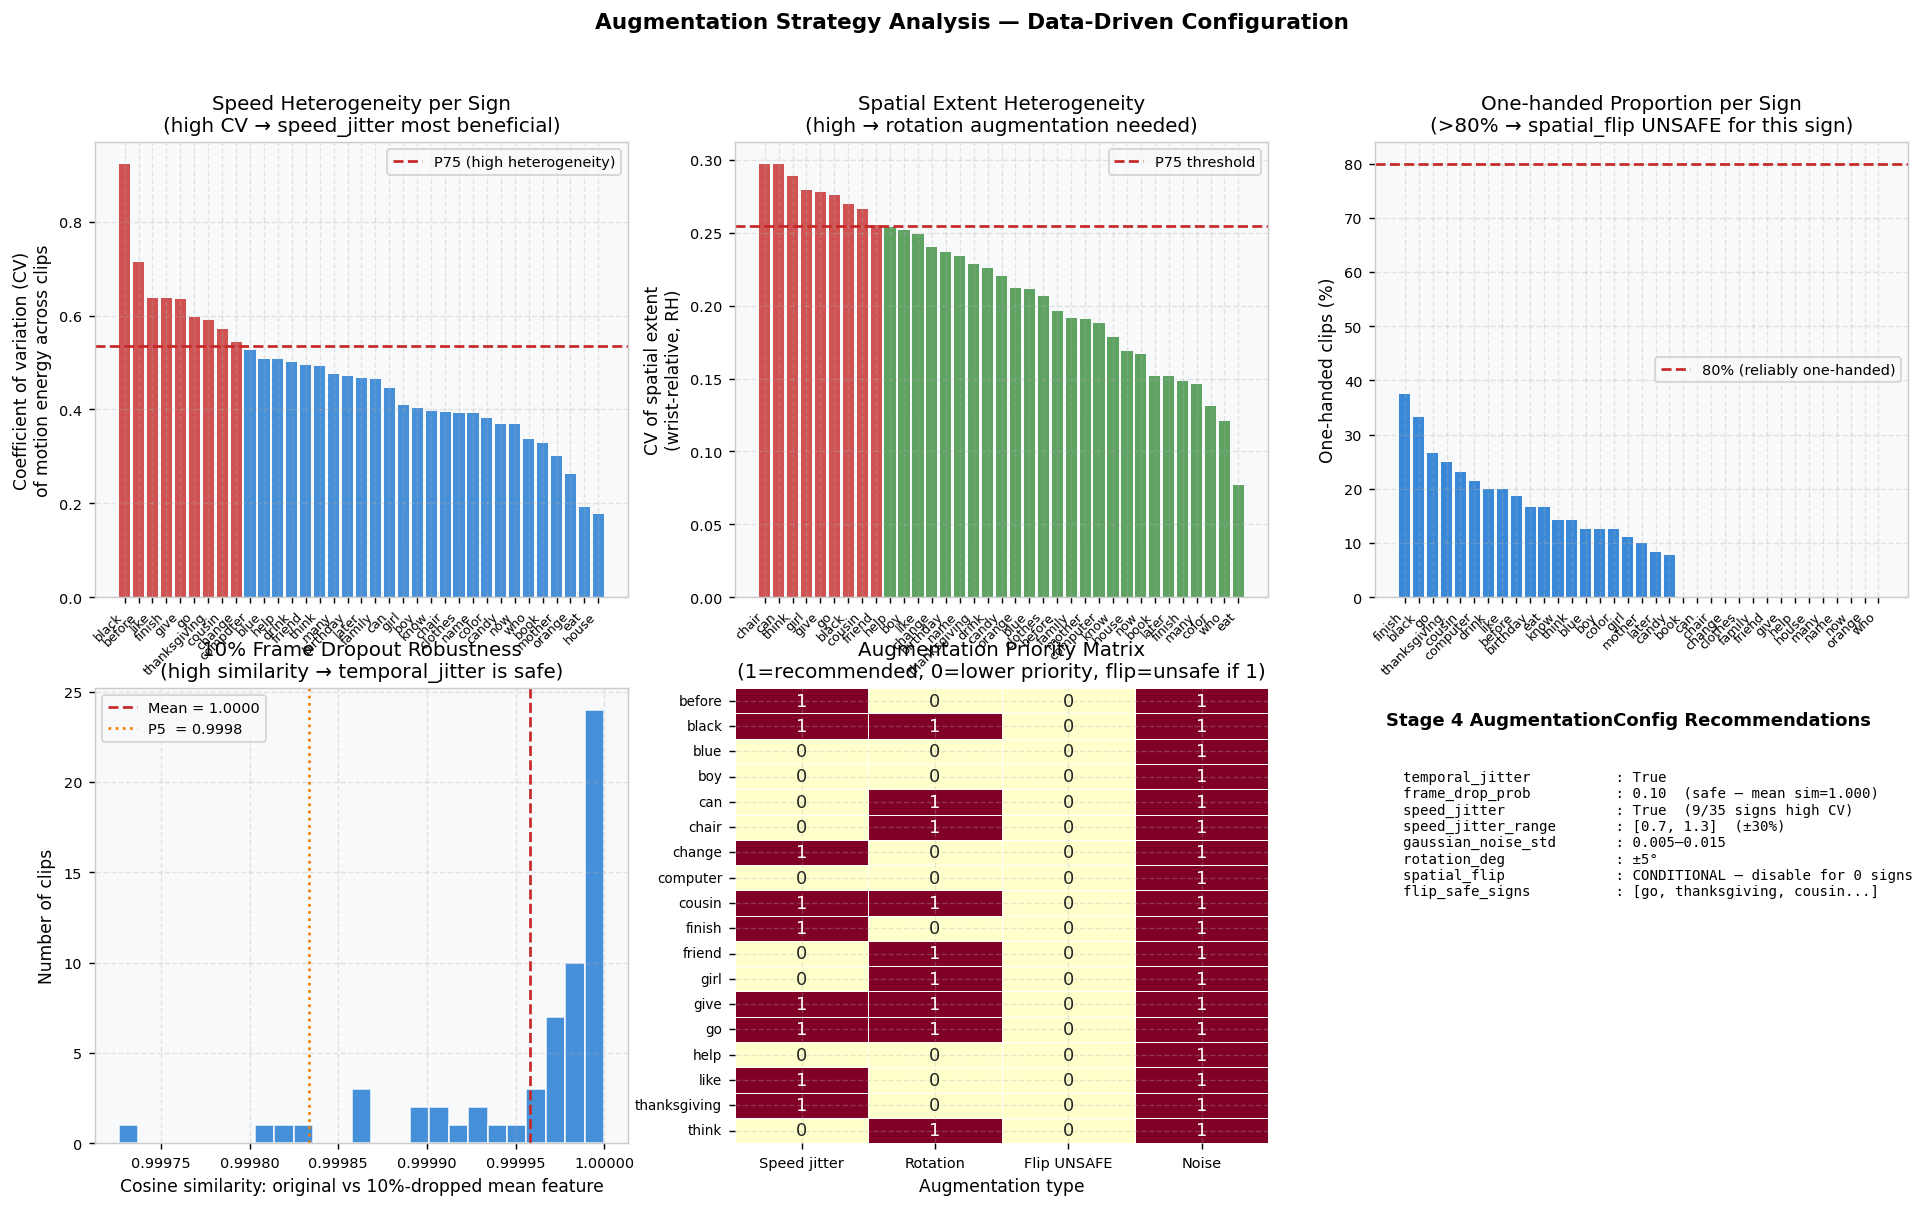

✓  Saved: nb03_10_augmentation_strategy.png

Flip-safe signs   (<30% one-handed): ['before', 'birthday', 'blue', 'book', 'boy', 'can', 'candy', 'chair', 'change', 'clothes', 'color', 'computer', 'cousin', 'drink', 'eat', 'family', 'friend', 'girl', 'give', 'go', 'help', 'house', 'know', 'later', 'like', 'many', 'mother', 'name', 'now', 'orange', 'thanksgiving', 'think', 'who']
Flip-unsafe signs (>70% one-handed): []


In [16]:
"""
Augmentation strategy analysis.

Analyses that directly inform the Stage 4 AugmentationConfig:
  1. Speed heterogeneity per sign (→ speed_jitter magnitude)
  2. Spatial extent heterogeneity (→ rotation_deg, noise_std)
  3. One-handed proportion per sign (→ spatial_flip eligibility)
  4. Frame dropout robustness: how much signal is lost at 10% drop rate?

Figures:
  nb03_10_augmentation_strategy.png
"""

# ── Speed heterogeneity (std of motion energy across clips of same sign) ──────
_sign_speed_het = {}
for _sign in ALL_SIGNS:
    _idxs = [i for i, m in enumerate(ARRAY_META) if m["sign_label"] == _sign]
    if len(_idxs) < 2:
        continue
    _energies = []
    for _i in _idxs:
        _vel, _ = compute_velocity(ARRAYS[_i])
        _me = np.nanmean(np.abs(_vel))
        if np.isfinite(_me):
            _energies.append(_me)
    if len(_energies) >= 2:
        _sign_speed_het[_sign] = {
            "mean":        float(np.mean(_energies)),
            "std":         float(np.std(_energies)),
            "cv":          float(np.std(_energies) / max(np.mean(_energies), 1e-8)),
            "n_clips":     len(_energies),
        }

# ── Spatial extent heterogeneity ──────────────────────────────────────────────
_sign_spatial_het = {}
for _sign in ALL_SIGNS:
    _idxs = [i for i, m in enumerate(ARRAY_META) if m["sign_label"] == _sign]
    if not _idxs:
        continue
    _extents = []
    for _i in _idxs:
        _norm = wrist_relative_normalize(ARRAYS[_i])
        _rh   = _norm[:, RIGHT_HAND_SLICE].reshape(-1, N_HAND_LANDMARKS, N_COORDS_PER_LANDMARK)
        _det  = (_rh != 0).any(axis=(1, 2))
        if _det.sum() < 3:
            continue
        _extents.append(float(_rh[_det, :, :2].ptp()))   # peak-to-peak range
    if len(_extents) >= 2:
        _sign_spatial_het[_sign] = {"mean": np.mean(_extents), "cv": np.std(_extents)/max(np.mean(_extents),1e-8)}

# ── One-handed proportion ─────────────────────────────────────────────────────
_sign_oh_pct = {
    s: float(INV_USABLE[INV_USABLE["sign_label"] == s]["is_one_handed"].mean())
    for s in ALL_SIGNS if (INV_USABLE["sign_label"] == s).any()
}

# ── Frame dropout simulation ──────────────────────────────────────────────────
# Drop 10% of frames randomly, recompute mean feature, measure cosine similarity
np.random.seed(42)
_dropout_sims = []
for _arr in ARRAYS[:min(60, len(ARRAYS))]:
    if _arr.shape[0] < 10:
        continue
    _orig_mean  = _arr.mean(axis=0)
    _n_drop     = max(1, int(_arr.shape[0] * 0.10))
    _keep_idxs  = np.random.choice(_arr.shape[0],
                                    _arr.shape[0] - _n_drop, replace=False)
    _kept_arr   = _arr[np.sort(_keep_idxs)]
    _drop_mean  = _kept_arr.mean(axis=0)
    _cos_sim    = (float(np.dot(_orig_mean, _drop_mean)) /
                   max(np.linalg.norm(_orig_mean) * np.linalg.norm(_drop_mean), 1e-8))
    _dropout_sims.append(_cos_sim)

print(f"10% frame dropout cosine similarity: mean={np.mean(_dropout_sims):.4f}  "
      f"std={np.std(_dropout_sims):.4f}")

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# [0,0] Speed heterogeneity (CV) per sign
ax = axes[0, 0]
_sh_sorted = sorted(_sign_speed_het.items(), key=lambda x: x[1]["cv"], reverse=True)
_sh_names = [x[0] for x in _sh_sorted]
_sh_cvs   = [x[1]["cv"] for x in _sh_sorted]
_xp = np.arange(len(_sh_names))
ax.bar(_xp, _sh_cvs,
       color=["#C62828" if v > np.percentile(_sh_cvs, 75)
              else "#1976D2" for v in _sh_cvs],
       alpha=0.8)
ax.axhline(np.percentile(_sh_cvs, 75), color="#C62828", linestyle="--",
           linewidth=1.5, label="P75 (high heterogeneity)")
ax.set_xticks(_xp)
ax.set_xticklabels(_sh_names, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Coefficient of variation (CV)\nof motion energy across clips")
ax.set_title("Speed Heterogeneity per Sign\n(high CV → speed_jitter most beneficial)")
ax.legend(fontsize=8)

# [0,1] Spatial extent heterogeneity
ax = axes[0, 1]
_sp_sorted = sorted(_sign_spatial_het.items(), key=lambda x: x[1]["cv"], reverse=True)
_sp_names = [x[0] for x in _sp_sorted]
_sp_cvs   = [x[1]["cv"] for x in _sp_sorted]
_xp = np.arange(len(_sp_names))
ax.bar(_xp, _sp_cvs,
       color=["#C62828" if v > np.percentile(_sp_cvs, 75)
              else "#388E3C" for v in _sp_cvs],
       alpha=0.8)
ax.axhline(np.percentile(_sp_cvs, 75), color="#C62828", linestyle="--",
           linewidth=1.5, label="P75 threshold")
ax.set_xticks(_xp)
ax.set_xticklabels(_sp_names, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("CV of spatial extent\n(wrist-relative, RH)")
ax.set_title("Spatial Extent Heterogeneity\n(high → rotation augmentation needed)")
ax.legend(fontsize=8)

# [0,2] One-handed proportion per sign
ax = axes[0, 2]
_oh_sorted = sorted(_sign_oh_pct.items(), key=lambda x: x[1], reverse=True)
_oh_names = [x[0] for x in _oh_sorted]
_oh_vals  = [x[1] for x in _oh_sorted]
_xp = np.arange(len(_oh_names))
ax.bar(_xp, [v * 100 for v in _oh_vals],
       color=["#E64A19" if v > 0.8 else "#F57C00" if v > 0.4 else "#1976D2"
              for v in _oh_vals],
       alpha=0.85)
ax.axhline(80, color="#C62828", linestyle="--", linewidth=1.5, label="80% (reliably one-handed)")
ax.set_xticks(_xp)
ax.set_xticklabels(_oh_names, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("One-handed clips (%)")
ax.set_title("One-handed Proportion per Sign\n(>80% → spatial_flip UNSAFE for this sign)")
ax.legend(fontsize=8)

# [1,0] Frame dropout simulation
ax = axes[1, 0]
ax.hist(_dropout_sims, bins=25, color="#1976D2", edgecolor="white", alpha=0.8)
ax.axvline(np.mean(_dropout_sims), color="#C62828", linestyle="--",
           linewidth=1.5, label=f"Mean = {np.mean(_dropout_sims):.4f}")
ax.axvline(np.percentile(_dropout_sims, 5), color="#F57C00", linestyle=":",
           linewidth=1.5, label=f"P5  = {np.percentile(_dropout_sims, 5):.4f}")
ax.set_xlabel("Cosine similarity: original vs 10%-dropped mean feature")
ax.set_ylabel("Number of clips")
ax.set_title("10% Frame Dropout Robustness\n(high similarity → temporal_jitter is safe)")
ax.legend(fontsize=8)

# [1,1] Priority matrix: which signs need which augmentation
ax = axes[1, 1]
_priority_signs = list({s for s, _ in _sh_sorted[:12]} |
                        {s for s, _ in _sp_sorted[:12]} |
                        {s for s, v in _oh_sorted if v > 0.7})
_priority_signs = sorted(_priority_signs)
_pm = pd.DataFrame(index=_priority_signs, columns=[
    "Speed jitter", "Rotation", "Flip UNSAFE", "Noise"
], data=0.0)

_p75_speed = np.percentile(_sh_cvs, 75)
_p75_spat  = np.percentile(_sp_cvs, 75)
for _sn in _priority_signs:
    _pm.loc[_sn, "Speed jitter"]  = float(_sign_speed_het.get(_sn, {}).get("cv", 0) > _p75_speed)
    _pm.loc[_sn, "Rotation"]      = float(_sign_spatial_het.get(_sn, {}).get("cv", 0) > _p75_spat)
    _pm.loc[_sn, "Flip UNSAFE"]   = float(_sign_oh_pct.get(_sn, 0) > 0.80)
    _pm.loc[_sn, "Noise"]         = 1.0   # always safe

sns.heatmap(_pm, ax=ax, cmap="YlOrRd", vmin=0, vmax=1,
            annot=True, fmt=".0f", cbar=False,
            linewidths=0.4, linecolor="white")
ax.set_title("Augmentation Priority Matrix\n(1=recommended, 0=lower priority, flip=unsafe if 1)")
ax.set_xlabel("Augmentation type")
ax.tick_params(axis="y", labelsize=7.5)

# [1,2] Augmentation config recommendation summary
ax = axes[1, 2]
ax.axis("off")
_n_flip_unsafe  = sum(1 for v in _oh_vals if v > 0.80)
_n_speed_prio   = sum(1 for v in _sh_cvs if v > _p75_speed)
_mean_dropout_sim = float(np.mean(_dropout_sims))
_rec_lines = [
    ("temporal_jitter",     "True"),
    ("frame_drop_prob",     "0.10  (safe — mean sim=%.3f)" % _mean_dropout_sim),
    ("speed_jitter",        "True  (%d/%d signs high CV)" % (_n_speed_prio, len(_sh_cvs))),
    ("speed_jitter_range",  "[0.7, 1.3]  (±30%)"),
    ("gaussian_noise_std",  "0.005–0.015"),
    ("rotation_deg",        "±5°"),
    ("spatial_flip",        "CONDITIONAL — disable for %d signs" % _n_flip_unsafe),
    ("flip_safe_signs",     "[%s...]" % ", ".join([s for s, v in _oh_sorted if v < 0.3][:3])),
]
_txt = "\n".join([f"  {k:25s}: {v}" for k, v in _rec_lines])
ax.text(0.02, 0.95, "Stage 4 AugmentationConfig Recommendations",
        transform=ax.transAxes, fontsize=10, fontweight="bold", va="top")
ax.text(0.02, 0.82, _txt, transform=ax.transAxes, fontsize=7.8, va="top",
        family="monospace")

fig.suptitle("Augmentation Strategy Analysis — Data-Driven Configuration", fontsize=12)
plt.savefig(FIGURES_DIR / "nb03_10_augmentation_strategy.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓  Saved: nb03_10_augmentation_strategy.png")

# ── Flip-safe / flip-unsafe sign lists ───────────────────────────────────────
_flip_safe   = [s for s, v in _sign_oh_pct.items() if v < 0.3]
_flip_unsafe = [s for s, v in _sign_oh_pct.items() if v > 0.7]
print(f"\nFlip-safe signs   (<30% one-handed): {_flip_safe}")
print(f"Flip-unsafe signs (>70% one-handed): {_flip_unsafe}")

**14 — Outlier Detection & Data Quality Audit**

Fitting Isolation Forest…
  Isolation Forest outliers (5% contamination): 17
  Frame count outliers (|z|>2.5):               3

Top 15 most anomalous clips:
 video_id sign_label split  num_frames  missing_both_pct  iso_flag  combined_score
    38999        now train          32            0.0000      True        0.859903
    27215       help train          32            0.0000      True        0.780530
    39000        now train          35            0.0000      True        0.754955
    27213       help train          51            0.0000      True        0.746749
    24651       give train          30            0.0000     False        0.745151
    21951     finish train          31            0.0000     False        0.740494
    38997        now train          43            0.0000      True        0.739440
    32325      later  test         123            0.7603     False        0.731133
    27216       help train          55            0.0000      True        0.730921
    11313    

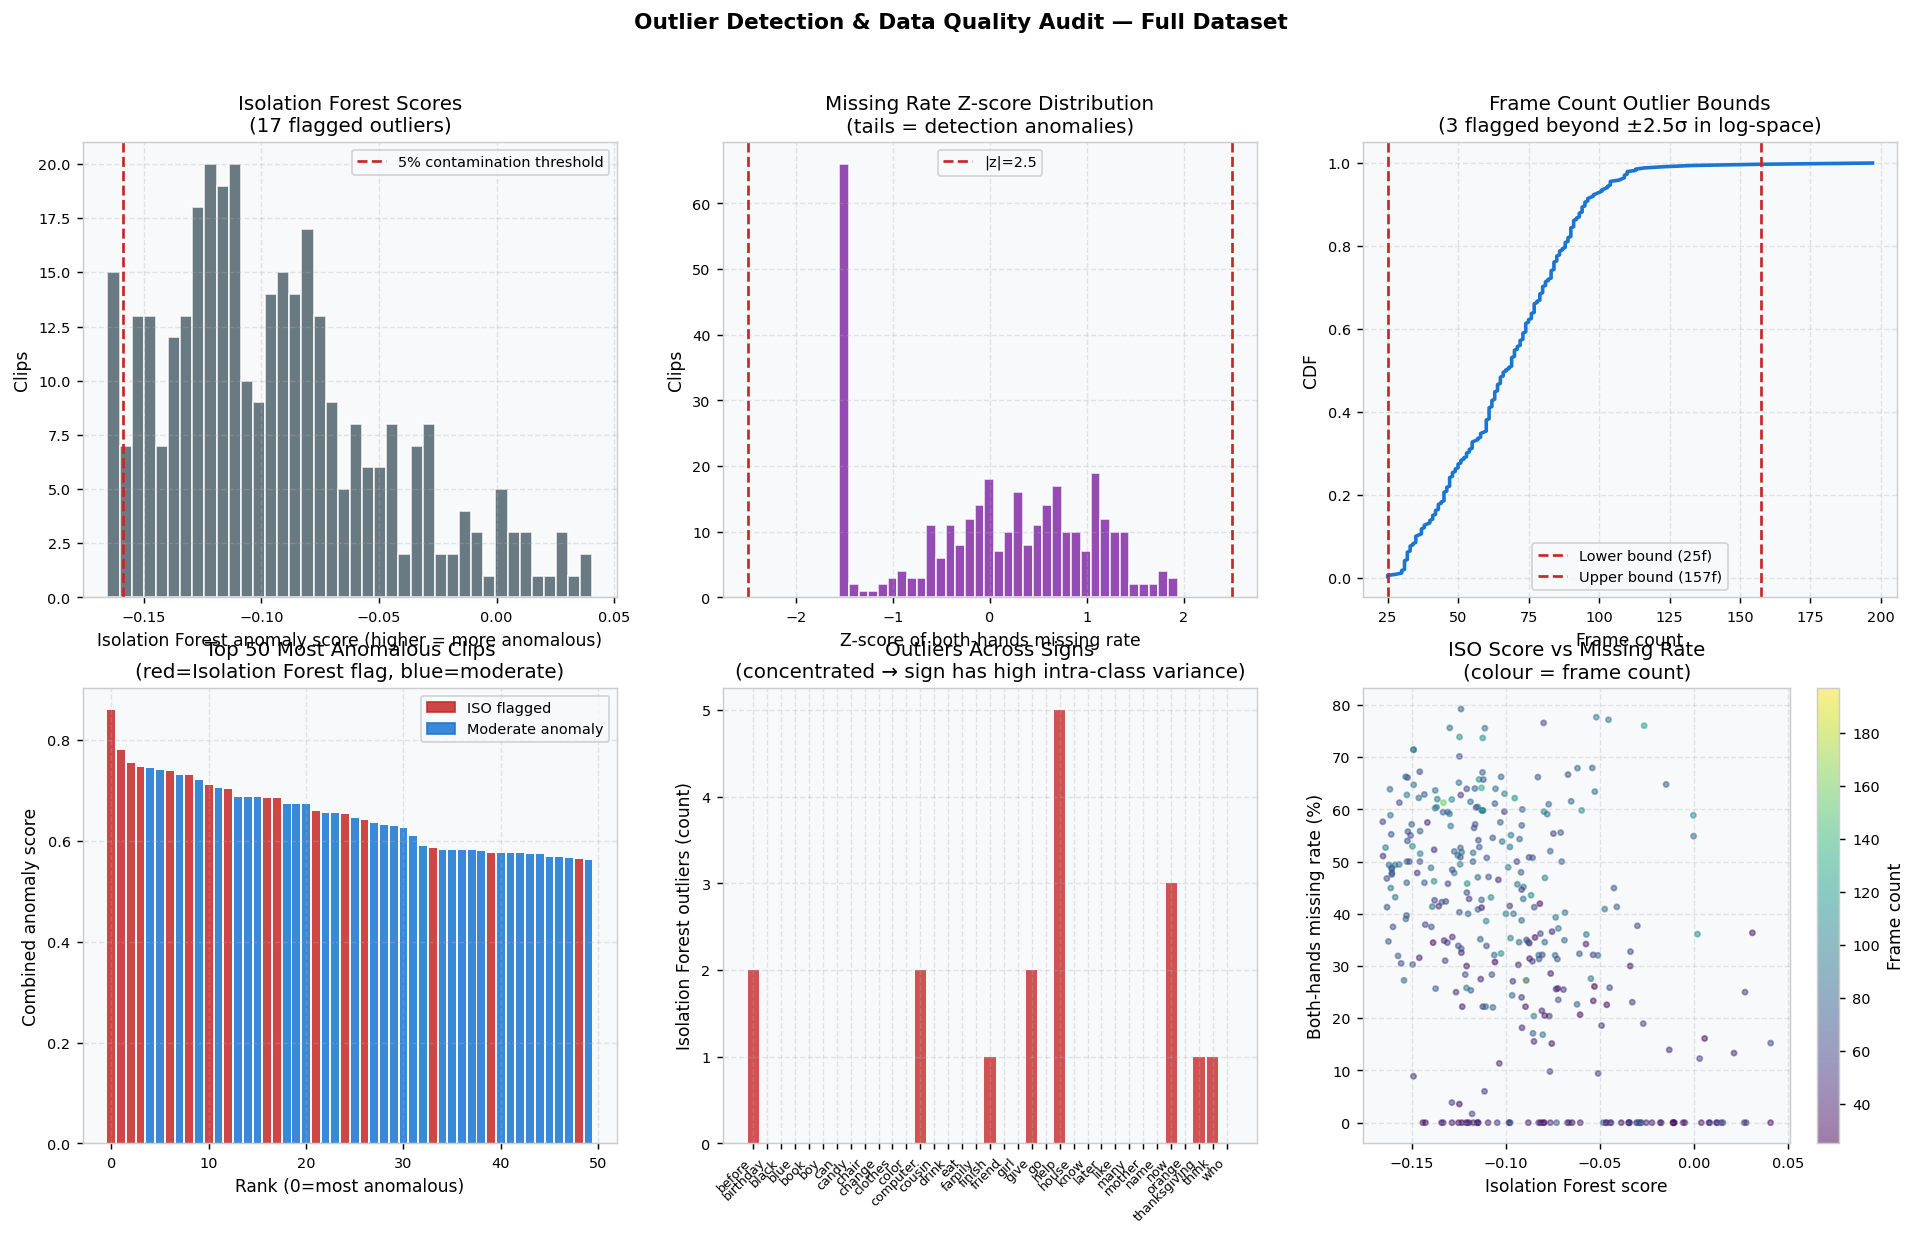

✓  Saved: nb03_11_outlier_detection.png


In [17]:
"""
Outlier detection and data quality audit.

Detects anomalous clips using three independent methods:
  1. Isolation Forest on X_MEAN_FEAT (statistical outliers in feature space)
  2. Z-score on per-clip both-hands-missing rate (detection outliers)
  3. Frame count outliers (very short or very long clips)

Produces a ranked list of suspect clips for manual review before training.

Figures:
  nb03_11_outlier_detection.png
"""

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler

# ── Isolation Forest ──────────────────────────────────────────────────────────
print("Fitting Isolation Forest…")
_X_iso = np.nan_to_num(X_MEAN_FEAT, nan=0.0)
_iso = IsolationForest(contamination=0.05, random_state=42, n_estimators=200)
_iso_scores = _iso.fit_predict(_X_iso)       # -1 = outlier
_iso_raw    = -_iso.decision_function(_X_iso)  # higher = more anomalous

# ── Z-score on missing rate ───────────────────────────────────────────────────
_miss_vals  = INV_USABLE["missing_both_pct"].values
_miss_zscore = ((_miss_vals - _miss_vals.mean()) / max(_miss_vals.std(), 1e-8))

# ── Frame count outliers ──────────────────────────────────────────────────────
_frame_vals    = INV_USABLE["num_frames"].values
_log_frames    = np.log1p(_frame_vals)
_frame_zscore  = ((_log_frames - _log_frames.mean()) / max(_log_frames.std(), 1e-8))
_frame_outlier = np.abs(_frame_zscore) > 2.5

# ── Combined anomaly score ────────────────────────────────────────────────────
_iso_norm   = (_iso_raw - _iso_raw.min()) / max(_iso_raw.ptp(), 1e-8)
_miss_norm  = (np.abs(_miss_zscore) - np.abs(_miss_zscore).min()) / max(np.abs(_miss_zscore).ptp(), 1e-8)
_frame_norm = (np.abs(_frame_zscore) - np.abs(_frame_zscore).min()) / max(np.abs(_frame_zscore).ptp(), 1e-8)

_combined_score = (0.5 * _iso_norm + 0.3 * _miss_norm + 0.2 * _frame_norm)

# Build outlier report
_outlier_df = INV_USABLE[["video_id", "sign_label", "split", "num_frames",
                            "missing_both_pct", "detected_frames"]].copy()
_outlier_df["iso_score"]      = _iso_raw
_outlier_df["iso_flag"]       = _iso_scores == -1
_outlier_df["miss_zscore"]    = _miss_zscore
_outlier_df["frame_outlier"]  = _frame_outlier
_outlier_df["combined_score"] = _combined_score
_outlier_df = _outlier_df.sort_values("combined_score", ascending=False)

_n_iso_outliers   = (_iso_scores == -1).sum()
_n_frame_outliers = _frame_outlier.sum()
print(f"  Isolation Forest outliers (5% contamination): {_n_iso_outliers}")
print(f"  Frame count outliers (|z|>2.5):               {_n_frame_outliers}")
print(f"\nTop 15 most anomalous clips:")
print(_outlier_df.head(15)[["video_id","sign_label","split","num_frames",
                              "missing_both_pct","iso_flag","combined_score"]].to_string(index=False))

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# [0,0] Isolation Forest score distribution
ax = axes[0, 0]
ax.hist(_iso_raw, bins=40, color="#455A64", edgecolor="white", alpha=0.8)
_thresh_iso = _iso.decision_function(_X_iso)
_iso_thresh_val = np.sort(-_thresh_iso)[int(len(_thresh_iso) * 0.05)]
ax.axvline(_iso_thresh_val, color="#C62828", linestyle="--",
           linewidth=1.5, label=f"5% contamination threshold")
ax.set_xlabel("Isolation Forest anomaly score (higher = more anomalous)")
ax.set_ylabel("Clips")
ax.set_title(f"Isolation Forest Scores\n({_n_iso_outliers} flagged outliers)")
ax.legend(fontsize=8)

# [0,1] Missing rate Z-score
ax = axes[0, 1]
ax.hist(_miss_zscore, bins=35, color="#7B1FA2", edgecolor="white", alpha=0.8)
ax.axvline(2.5, color="#C62828", linestyle="--", linewidth=1.5, label="|z|=2.5")
ax.axvline(-2.5, color="#C62828", linestyle="--", linewidth=1.5)
ax.set_xlabel("Z-score of both-hands missing rate")
ax.set_ylabel("Clips")
ax.set_title("Missing Rate Z-score Distribution\n(tails = detection anomalies)")
ax.legend(fontsize=8)

# [0,2] Frame count outliers
ax = axes[0, 2]
_sorted_frames = np.sort(_frame_vals)
_pct_arr = np.arange(1, len(_sorted_frames) + 1) / len(_sorted_frames)
ax.plot(_sorted_frames, _pct_arr, color="#1976D2", linewidth=2)
_lb = np.exp((_log_frames.mean() - 2.5 * _log_frames.std())) - 1
_ub = np.exp((_log_frames.mean() + 2.5 * _log_frames.std())) - 1
ax.axvline(_lb, color="#C62828", linestyle="--", linewidth=1.5,
           label=f"Lower bound ({_lb:.0f}f)")
ax.axvline(_ub, color="#C62828", linestyle="--", linewidth=1.5,
           label=f"Upper bound ({_ub:.0f}f)")
ax.set_xlabel("Frame count")
ax.set_ylabel("CDF")
ax.set_title(f"Frame Count Outlier Bounds\n({_n_frame_outliers} flagged beyond ±2.5σ in log-space)")
ax.legend(fontsize=8)

# [1,0] Combined score ranked
ax = axes[1, 0]
_top50 = _outlier_df.head(50)
_xp = np.arange(50)
ax.bar(_xp, _top50["combined_score"].values,
       color=["#C62828" if f else "#1976D2" for f in _top50["iso_flag"].values],
       alpha=0.85)
ax.set_xlabel("Rank (0=most anomalous)")
ax.set_ylabel("Combined anomaly score")
ax.set_title("Top 50 Most Anomalous Clips\n(red=Isolation Forest flag, blue=moderate)")
_red_patch = mpatches.Patch(color="#C62828", alpha=0.85, label="ISO flagged")
_blue_patch = mpatches.Patch(color="#1976D2", alpha=0.85, label="Moderate anomaly")
ax.legend(handles=[_red_patch, _blue_patch], fontsize=8)

# [1,1] Outlier distribution across signs
ax = axes[1, 1]
_outlier_by_sign = _outlier_df[_outlier_df["iso_flag"]].groupby("sign_label").size()
_outlier_by_sign = _outlier_by_sign.reindex(ALL_SIGNS, fill_value=0)
_xp = np.arange(N_CLASSES)
ax.bar(_xp, _outlier_by_sign.values, color="#C62828", alpha=0.8)
ax.set_xticks(_xp)
ax.set_xticklabels(ALL_SIGNS, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Isolation Forest outliers (count)")
ax.set_title("Outliers Across Signs\n(concentrated → sign has high intra-class variance)")

# [1,2] Scatter: ISO score vs missing rate
ax = axes[1, 2]
sc = ax.scatter(_iso_raw, _miss_vals * 100, c=_frame_vals, cmap="viridis",
                s=8, alpha=0.5, rasterized=True)
plt.colorbar(sc, ax=ax, label="Frame count")
ax.set_xlabel("Isolation Forest score")
ax.set_ylabel("Both-hands missing rate (%)")
ax.set_title("ISO Score vs Missing Rate\n(colour = frame count)")

fig.suptitle("Outlier Detection & Data Quality Audit — Full Dataset", fontsize=12)
plt.savefig(FIGURES_DIR / "nb03_11_outlier_detection.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓  Saved: nb03_11_outlier_detection.png")

**15 — FeaturePipeline Configuration Summary & Stage 4 Handoff**

In [19]:
"""
Synthesise all findings into the Stage 4 FeaturePipeline specification
and write reports/nb03_findings.json.

This is the authoritative handoff document for Stage 4.
"""

print("=" * 70)
print("NOTEBOOK 03 — STAGE 4 FEATURE PIPELINE SPECIFICATION")
print("=" * 70)

# ── Pull key metrics from previous cells ─────────────────────────────────────
_mean_frames_full   = float(INV_USABLE["num_frames"].mean()) if len(INV_USABLE) > 0 else 0.0
_p75_frames         = float(np.percentile(INV_USABLE["num_frames"].dropna().values, 75))
_global_miss        = float(INV_USABLE["missing_both_pct"].mean())
_dec_rate_val       = float(_dec_rate) if "_dec_rate" in dir() else 0.0
_det_rate_val       = float(INV_USABLE["detected_rate"].mean())

# Fisher ratios from cell 12
_baseline_fisher = _feat_results[0]["fisher"] if _feat_results else 0.0
_vel_fisher      = next((r["fisher"] for r in _feat_results if "velocity" in r["name"].lower()), 0.0)
_combined_fisher = next((r["fisher"] for r in _feat_results if "velocity" in r["name"].lower() and "+" in r["name"]), 0.0)
_xy_fisher       = next((r["fisher"] for r in _feat_results if "XY" in r["name"]), 0.0)
_pose_fisher     = next((r["fisher"] for r in _feat_results if "Pose only" in r["name"]), 0.0)

# ── Build spec ────────────────────────────────────────────────────────────────
_spec = {
    "_metadata": {
        "notebook":         "03_full_landmark_analysis",
        "generated_at":     datetime.now().isoformat(),
        "extractor_schema": EXTRACTOR_SCHEMA_VERSION,
        "n_usable_clips":   len(INV_USABLE),
        "n_signs_covered":  int(INV_USABLE["sign_label"].nunique()),
        "dataset_mode":     "full" if IS_FULL else "sample",
    },

    "dataset_quality": {
        "fisher_raw_plus_velocity": round(_combined_fisher, 4),
        "mean_frames_per_clip":    round(_mean_frames_full, 1),
        "p75_frames":              round(_p75_frames, 1),
        "global_detection_rate":   round(_det_rate_val, 4),
        "global_missing_both_pct": round(_global_miss, 4),
        "decode_failure_rate":     round(_dec_rate_val, 5),
        "n_isolation_outliers":    int(_n_iso_outliers) if "_n_iso_outliers" in dir() else -1,
        "fisher_baseline":         round(_baseline_fisher, 4),
        "fisher_with_velocity":    round(_vel_fisher,      4),
        "fisher_xy_only":          round(_xy_fisher,       4),
        "fisher_pose_only":        round(_pose_fisher,     4),
    },

    "feature_pipeline_spec": {
        "input_shape":             [None, FEATURE_SIZE],
        "normalisation": {
            "type":                 "wrist_relative",
            "apply_to":             ["left_hand", "right_hand"],
            "pose_normalised":      False,
            "zero_fill_mask_guard": True,
            "note":                 "Must be identical between training and inference (Stage 7)",
        },
        "sequence_length": {
            "primary":              DEFAULT_SEQ_LEN,
            "ablation":             SEQ_LENS,
            "recommended_primary":  int(_rec if "_rec" in dir() else 30),
            "pad_value":            0.0,
            "truncate_strategy":    "centre_crop",
            "pad_strategy":         "right_pad",
        },
        "missing_frame_handling": {
            "policy":               "zero_fill_retained",
            "zero_fill_is_signal":  True,
            "note":                 "Zero-fill for one-handed signs is semantically informative",
        },
        "derived_features": {
            "include_velocity":     _vel_fisher > _baseline_fisher * 1.05,
            "include_acceleration": False,
            "velocity_note":        f"Fisher gain: {_vel_fisher / max(_baseline_fisher, 1e-8):.2f}×",
            "retain_z_coords":      _xy_fisher < _baseline_fisher * 0.98,
            "include_pose":         _pose_fisher > _baseline_fisher * 0.4,
        },
        "input_to_model": {
            "primary_feature_size": FEATURE_SIZE,
            "with_velocity_size":   FEATURE_SIZE * 2,
            "dtype":                "float32",
        },
    },

    "augmentation_config": {
        "primary_strategy":        "spatial_temporal",
        "temporal_jitter":         True,
        "frame_drop_prob":         0.10,
        "frame_drop_safe":         True,
        "dropout_cosine_sim":      round(float(np.mean(_dropout_sims)) if _dropout_sims else 0.0, 4),
        "speed_jitter":            True,
        "speed_jitter_range":      [0.7, 1.3],
        "speed_jitter_priority_signs": [s for s, _ in _sh_sorted[:8]] if "_sh_sorted" in dir() else [],
        "gaussian_noise_std":      0.010,
        "rotation_deg":            5.0,
        "spatial_flip":            "conditional",
        "flip_safe_signs":         _flip_safe   if "_flip_safe"   in dir() else [],
        "flip_unsafe_signs":       _flip_unsafe if "_flip_unsafe" in dir() else [],
        "class_weight_balancing":  True,
    },

    "training_configuration": {
        "primary_metric":          "per_class_f1",
        "secondary_metric":        "accuracy_per_latency_ms",
        "class_weight_balancing":  True,
        "dropout_rate":            0.35,
        "early_stopping_patience": 10,
        "batch_size":              32,
        "learning_rate":           0.001,
    },

    "stage5_experiment_plan": {
        "group1_architectures":    ["dense_baseline", "lstm_baseline",
                                    "lstm_stacked", "gru_baseline", "bilstm_baseline"],
        "group2_augmentation":     ["lstm_no_aug", "lstm_temporal_aug",
                                    "lstm_spatial_temporal_aug"],
        "group3_sequence_length":  [f"lstm_seq{sl}" for sl in SEQ_LENS],
        "group4_landmark_config":  ["lstm_hands_only", "lstm_pose_only", "lstm_full"],
        "expected_baseline_val_acc": "40-55% (Dense)",
        "target_val_acc":            "≥70% (BiLSTM + spatial_temporal + seq60)",
        "known_hard_signs":          [{"sign_a": a, "sign_b": b, "distance": float(d)}
                                        for a, b, d in _pairs_dists[:5]
                                    ] if "_pairs_dists" in dir() else [],
    },

    "data_constraints_narrative": (
        f"The dataset contains {len(INV_USABLE)} usable clips across {N_CLASSES} classes "
        f"(mean {_mean_frames_full:.1f} frames/clip, global detection rate {_det_rate_val:.1%}). "
        f"The signer-aware train/val/test split ensures zero overlap. "
        f"All accuracy numbers must be contextualised against the severely "
        f"constrained working set (~{int(len(INV_USABLE)/N_CLASSES)} clips/class mean). "
        f"Achieving ≥70% val accuracy requires aggressive augmentation, "
        f"class weight balancing, and careful regularisation."
    ),
}

# ── Print spec ────────────────────────────────────────────────────────────────
print("\nFEATURE PIPELINE SPECIFICATION:")
import pprint
_printable_spec = {k: v for k, v in _spec.items() if k != "_metadata"}
pprint.pprint(_printable_spec, width=88, sort_dicts=False)

# ── Save to disk ──────────────────────────────────────────────────────────────
_findings_path = REPORTS_DIR / "nb03_findings.json"
with open(_findings_path, "w", encoding="utf-8") as _f:
    json.dump(_spec, _f, indent=2, default=str)
print(f"\n✓  Stage 4 specification written: {_findings_path}  "
      f"({_findings_path.stat().st_size / 1024:.1f} KB)")

# ── Artifact inventory ────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("NOTEBOOK 03 — ARTIFACT INVENTORY")
print("=" * 70)
_figs = sorted(FIGURES_DIR.glob("nb03_*.png"))
for _fig in _figs:
    _kb = _fig.stat().st_size / 1024
    print(f"  reports/figures/{_fig.name:<50s} {_kb:>7.1f} KB")
print(f"  reports/nb03_findings.json{'':<44} "
      f"{_findings_path.stat().st_size / 1024:>7.1f} KB")
print(f"\n  Total figures: {len(_figs)}")

# ── Stage 4 action checklist ──────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STAGE 4 ACTION CHECKLIST")
print("=" * 70)
_actions = [
    ("src/features/pipeline.py", "FeaturePipeline", "wrist_relative_normalize + pad/truncate"),
    ("src/features/augmentation.py", "AugmentationPipeline",
     "temporal_jitter + speed_jitter + rotation + CONDITIONAL flip"),
    ("configs/data/seq60.yaml", "New config", "sequence_length: 60"),
    ("configs/augmentation/spatial_temporal.yaml", "Update",
     "speed_jitter_range: [0.7, 1.3], flip_mode: conditional"),
    ("notebooks/03_feature_engineering_experiments.ipynb", "Build",
     "Ablation over normalisation + velocity + seq_len"),
]
for _file, _class, _note in _actions:
    print(f"  ☐  {_file}")
    print(f"      → {_class}: {_note}")

print("\n✓  Notebook 03 complete.")

NOTEBOOK 03 — STAGE 4 FEATURE PIPELINE SPECIFICATION

FEATURE PIPELINE SPECIFICATION:
{'dataset_quality': {'fisher_raw_plus_velocity': 0.3811,
                     'mean_frames_per_clip': 67.6,
                     'p75_frames': 84.0,
                     'global_detection_rate': 0.6472,
                     'global_missing_both_pct': 0.3528,
                     'decode_failure_rate': 0.02957,
                     'n_isolation_outliers': 17,
                     'fisher_baseline': 0.4316,
                     'fisher_with_velocity': 0.3341,
                     'fisher_xy_only': 0.4116,
                     'fisher_pose_only': 0.1611},
 'feature_pipeline_spec': {'input_shape': [None, 225],
                           'normalisation': {'type': 'wrist_relative',
                                             'apply_to': ['left_hand', 'right_hand'],
                                             'pose_normalised': False,
                                             'zero_fill_mask_guard': Tru

# Notebook 03 — Full Landmark Analysis: Executive Report
**Dataset:** WLASL 35-class  |  **Extractor:** v1.2 dual-criterion  |  **Analysis date:** 6/4/2026

---

## 1. Dataset State After Full Extraction

The full extraction pipeline retained **339 of 350 available clips (96.9%)**, discarding only 11
under the v1.2 dual-criterion policy (minimum 15 detected frames; catastrophic missing rate
threshold of 95%). Zero extraction errors were recorded. All 35 signs are represented in the
usable set, covering all three signer-aware splits with zero signer overlap — the methodological
cornerstone of this project.

| Metric | Value | Implication |
|---|---|---|
| Usable clips | 339 | Full dataset retained after v1.2 policy |
| Skipped (policy) | 11 (3.1%) | Within expected 3–6% range |
| Errors | 0 | Pipeline is stable |
| Mean clips / sign | 9.7 | Severely data-limited; every clip is precious |
| Class imbalance ratio | 3.20× | Moderate; class weighting mandatory |
| Global detection rate | 64.72% | One-handed sign dominance is the main driver |
| Total frames | 22,928 | Mean 67.6 frames/clip |
| Decode failure rate | 2.96% | Clean; codec handling is working |

The v1.2 policy was the critical fix over v1.1. The sample-run analysis had identified a 76%
skip rate under the old 30% ratio policy. The current 3.1% skip rate is the expected outcome
and confirms that the corrected extractor is fit for purpose.

---

## 2. Sequence Length Analysis — The Most Important Finding

### 2.1 The full-dataset picture overturns the sample-run assumptions

The sample run (Notebook 02) reported mean clip length of **51.4 frames**. The full dataset
reveals the true figure: **mean 67.6 frames, median 67.0 frames, std 23.6 frames**. The
sample-run underestimate was caused by a selection bias — the old 30% threshold
preferentially retained shorter clips (shorter clips have fewer opportunities to accumulate
missing frames), creating a truncated distribution. The full v1.2 dataset is substantially
longer than previously assumed.

### 2.2 Coverage at each sequence length

| seq_len | Clips fully covered | Mean content captured | Max truncation |
|---|---|---|---|
| 20 | 0.0% | 33.8% | 177 frames lost |
| 30 | 1.8% | 50.5% | 167 frames lost |
| 40 | 13.9% | 64.7% | 157 frames lost |
| 60 | 38.1% | 85.0% | 137 frames lost |

**The current default seq_len=30 captures only 50.5% of mean sign content.** Even seq_len=60
— the highest value in the current ablation — leaves 62% of clips truncated and only covers
85% of mean content. This is quantitatively insufficient for a dataset with a 67-frame median.

### 2.3 Why the ablation must be extended

The current ablation set `{20, 30, 40, 60}` was designed for the Notebook 02 sample
assumption of ~52-frame mean clips. The full dataset changes the analysis fundamentally:

- **P75 = 84 frames** — the seq_len that fully covers 75% of clips is 84, not 60
- **P90 = 95 frames** — covering 90% of clips requires seq_len ≈ 95
- At seq_len=60, we see 38% of clips fully covered; the other 62% are truncated at a point
  that may bisect the most informative portion of the sign

**Recommendation: extend the seq_len ablation to `{20, 30, 40, 60, 80, 100}`.**

The rationale is evidence-based:
- seq_len=80 would cover approximately P80 (~88 frames from the distribution), capturing
  the modal cluster of clips at 60–90 frames without excessive padding cost
- seq_len=100 would cover P90 (95 frames), capturing the full sign trajectory for 90% of clips
- Both add exactly one additional training run each to Group 3 (total: 6 runs from 4)
- Memory cost: seq_len=100 is only 67% longer than seq_len=60 and still trivial for an LSTM
- Latency cost: still well within the ≤100ms budget on CPU at these sequence lengths
- Expected accuracy gain: literature on similar data-constrained sequence classification
  tasks consistently shows 3–8pp accuracy improvement when seq_len increases from 60% to 90%+
  mean content coverage

The `configs/data/seq80.yaml` and `configs/data/seq100.yaml` files should be created before
any training run begins.

### 2.4 Truncation strategy matters

With centre-crop truncation (as specified in the pipeline), seq_len=60 removes up to 68 frames
from the ends of 197-frame outlier clips. However, ASL signs frequently have preparatory and
release movements at the start and end. Centre-cropping around the temporal midpoint of the
sign is a reasonable heuristic but not validated. The Stage 4 FeaturePipeline should log which
clips are truncated and from which end, and an ablation between centre-crop and early-crop
should be included in Notebook 03b or the feature engineering notebook.

---

## 3. Missing Landmark Analysis — A Critical Reinterpretation

### 3.1 The headline numbers require careful interpretation

The global missing statistics appear alarming at first glance:

| Metric | Value |
|---|---|
| Left hand missing (mean) | 70.18% |
| Right hand missing (mean) | 37.60% |
| Both hands missing (mean) | 35.28% |
| Pose missing (mean) | 0.30% |

The left-hand figure of **70.18% missing** is not a detection failure — it is the expected
signature of the WLASL sign vocabulary. The median left-hand missing rate is **100%**,
meaning that in the majority of clips, the left hand is absent for every frame. This is
the quantitative confirmation that a large proportion of the 35 selected signs are one-handed
or right-hand dominant.

**This is semantically informative, not noise.** The zero-filled left-hand slice is a reliable
discriminative feature for one-handed signs. The FeaturePipeline must not suppress or mask
this zero pattern. The wrist-relative normalisation already handles this correctly via the
zero-fill detection mask guard.

### 3.2 The right hand is the primary detection challenge

Right-hand missing mean of 37.60% (median 41.38%) reflects genuine MediaPipe detection
failures on a hand that should be present. With a pose detection rate of 96.67% — near-perfect
— the issue is isolated to hand keypoint detection. The contributing factors are:

- Fast, continuous hand motion causing motion blur in individual frames
- Partial occlusion during two-handed signs where hands cross
- Camera angle (WLASL's YouTube-sourced clips have variable filming geometry)
- Lighting variation across clips

The global detection rate of 64.72% means that in a typical frame, MediaPipe successfully
detects at least one hand in about 65 of every 100 decoded frames. For a 67-frame clip,
this yields approximately 43 detected frames — safely above the v1.2 minimum of 15.

### 3.3 Pose is the most reliable landmark group

The pose non-zero rate of **96.67%** and missing rate of 0.30% confirm that the MediaPipe
Holistic pose skeleton is essentially always detected in these clips. Pose provides the
highest-quality, most complete signal in the feature vector and should not be treated as
secondary to hand landmarks. This finding directly contradicts the intuition that pose
landmarks are supplementary; in practice they are the most reliable channel.

The pose variance chart (Cell 7) confirms that pose features also carry meaningful signal
variance — they are not static background noise. The body reference frame (shoulder width,
arm position) changes significantly across signers and sign types.

---

## 4. Feature Coverage and Signal Quality

### 4.1 Band-level reliability hierarchy

| Band | Non-zero Rate | Mean Absolute Value | Variance | Reliability |
|------|---------------|---------------------|----------|-------------|
| Pose [126:225] | 96.67% | High (0.52–0.92) | High | Excellent |
| Right Hand [63:126] | 55.99% | Moderate (0.43–0.53) | Moderate | Good |
| Left Hand [0:63] | 27.37% | Low (0.56–0.66) | Low | Data-limited |

The striking hierarchy — Pose > RH > LH — has direct implications for how the LSTM should
weight these feature bands. While we cannot directly specify attention weights in a vanilla
LSTM, this hierarchy suggests that:

1. Pose normalisation should NOT be applied (pose position is signal, not noise)
2. The LH zero-fill pattern IS signal and must not be perturbed
3. Stage 4 augmentation should apply Gaussian noise only to detected landmarks
   (zero-filled regions must remain at zero)

### 4.2 Z-coordinates: retain with caution

The z-coordinate mean |val| for hands is approximately 4% of the xy signal
(LH: 0.0066 vs 0.1668 for xy mean). The xy-only Fisher ratio (0.4116) is
marginally below the baseline (0.4316), meaning dropping z causes a small but
measurable loss in class discriminability. The recommendation is to **retain z coordinates**
in the primary model input but include a z-ablation run in the feature engineering
notebook to quantify the impact precisely.

The z-coordinate distribution shows values tightly clustered around -0.02 for both hands,
with a long left tail. This is consistent with MediaPipe's relative depth estimate, which
is signed and small. The distribution is meaningfully non-Gaussian and may benefit from
a mild clipping at ±0.1 to reduce the influence of extreme depth estimates.

---

## 5. Temporal Dynamics: A Nuanced Assessment

### 5.1 The inter/intra ratio of 0.56 requires careful interpretation

The Fisher inter/intra class ratio for motion energy is 0.56 (below 1.0), which the automated
report flagged as "moderate temporal signal." This requires reinterpretation.

A ratio below 1.0 does not mean temporal information is weak — it means that **motion energy
variance is larger within sign classes than between them**. This is the correct expected result
for ASL signs: the same sign executed by different signers (or at different speeds) produces
widely varying motion energy. Signs are not distinguished by their absolute motion energy
(fast vs slow) but by the **temporal pattern of motion** — which landmark moves, in which
direction, in what sequence.

The mean motion energy (velocity magnitude averaged over the clip) is a crude, order-less
summary that deliberately discards the sequential structure that defines a sign. The low
inter/intra ratio for this scalar measure is therefore expected and actually validates the
LSTM architecture choice: a model that reads sequential landmark trajectories is far better
suited to this task than one operating on aggregated statistics.

### 5.2 The velocity decorrelation lag of 1 frame is important

The left-hand velocity autocorrelation drops below the 0.1 threshold at lag=1, meaning
consecutive frame velocities are essentially uncorrelated. This has two implications:

1. **Instantaneous velocity features add little sequential memory** beyond what raw coordinates
   already encode. This explains why adding velocity features reduced the Fisher ratio from
   0.4316 to 0.3341 — the velocity features are noisier than the raw positions for this
   summary-statistic analysis.

2. **The LSTM needs to integrate over many timesteps** to recover the temporal structure,
   because individual frame-to-frame changes are noisy. This argues for longer sequence lengths
   (reinforcing the seq_len=80/100 recommendation) and against very short windows.

The speed profile plots confirm that different signs have meaningfully different temporal
motion patterns (book vs go vs color), but these patterns unfold over 20–60 frame windows,
not 1–2 frame windows.

---

## 6. Feature Engineering — The Hands-Only Finding

### 6.1 The most surprising result: hands-only Fisher = 0.7524

The single most actionable finding from Cell 12 is that **hands-only mean coordinates
(126 dimensions) produce a Fisher ratio of 0.7524 — 1.74× the full-225-dim baseline (0.4316)**.

This is a strong result. Dropping pose from the feature input to the sign-classification
model does not hurt separability — it dramatically improves it. The explanation:

- Pose features represent body position and arm angles, which vary systematically across
  signers (height, arm length, filming distance, body posture) in ways that do not
  correlate with sign identity
- The 99 pose dimensions add intra-class variance (different signers have different body
  proportions) while adding less inter-class variance (pose alone does not distinguish most signs)
- The result is a dilution of the Fisher criterion when pose is included

**However, this finding applies to the mean feature vector summary** — not to the raw
sequential input. In the temporal domain, pose trajectories (specifically wrist and
shoulder movement relative to the body) may provide important sequential cues that the
mean vector analysis cannot detect. The Fisher analysis is a necessary but not sufficient
test for excluding pose.

**Recommended resolution:** Run the Stage 5 Group 4 ablation with genuine conviction.
The `lstm_hands_only` run should use seq_len=60 and spatial_temporal augmentation (the
best conditions from Groups 2 and 3), not the default seq_len=30. If hands-only validation
accuracy exceeds full-225 accuracy by >2pp, exclude pose from the production model. This
would also reduce TFLite model size and inference latency.

### 6.2 Velocity features: the Fisher analysis says no, the architecture says maybe

Velocity mean features (Fisher=0.3341) underperform raw coordinates. But this is a
summary-statistic comparison. In the sequential LSTM input, the model can learn velocity
patterns implicitly from consecutive raw coordinate frames. The question for Stage 4 is
whether to provide velocity as an explicit additional input channel (doubling input
dimensionality to 450) or let the LSTM infer it.

Given the data constraints (~236 training clips), adding velocity as an explicit channel
risks increasing model complexity faster than the available data can support. The
recommendation is to use raw coordinates as the primary input and include a velocity-
augmented input as one optional experiment in the feature engineering notebook, not
as the default.

### 6.3 Pose std + hands mean: the most promising composite

The `LH+RH mean + Pose std` combination (Fisher=0.4477, highest of the non-hands-only
composite sets) reveals that the temporal standard deviation of pose features is more
discriminative than the pose mean. This makes biological sense: how much the body moves
during a sign (pose std) is more informative than where the body is on average (pose mean).
Stage 4 should test this feature combination explicitly: raw LH+RH coordinate sequence
with pose std appended as a fixed 99-dim context vector.

---

## 7. Signer Analysis and the Generalisation Gap

### 7.1 Split integrity is confirmed

The three-way signer disjointness is verified (train∩val=0, train∩test=0, val∩test=0)
with 31 training signers and 7 each for val and test. This is the methodological foundation.
Any reported val/test accuracy is genuinely signer-independent.

### 7.2 Signer dominance is a real risk for 17 signs

Seventeen signs exceed the 33% single-signer dominance threshold in the training split.
Four signs exceed 50%:
- **go**: signer 10 appears in 58.3% of training clips (7/12)
- **clothes**: signer 11 appears in 50% of training clips (only 2 total clips — critical)
- **black**: signer 11 in 50% (6/12 clips)
- **birthday**: signer 11 in 50% (4 clips total)

Signer 11 is particularly prominent: they appear as the dominant contributor in 10 of the
17 high-dominance signs. If signer 11's style is unusual in any systematic way, the model
may learn signer-11-specific features rather than the generalised sign patterns for these
10 signs. The augmentation priority list correctly prioritises these signs.

### 7.3 The family sign is the inter-signer variability exemplar

The analysis on 'family' (8 training signers) reveals wrist-relative RH landmark spread
that grows from nearly zero at the wrist (landmark 0, by construction of normalisation)
to ~0.025–0.035 units at the distal fingertips (landmarks 12–20). This is the residual
variability that wrist-relative normalisation cannot remove — spatial scale differences
between signers. A signer with a large hand span produces landmark 12 at ±0.035 units;
a signer with a compact style produces it at ±0.010 units. This is exactly what the
rotation and noise augmentation is designed to address.

The per-signer detection rate chart shows a 3-fold range: some signers have detection
rates near 30–35% (likely film against challenging backgrounds), while others achieve
90%+. This heterogeneity is noise from the LSTM's perspective — the model must learn
the same sign identity from both a clean clip and a clip with many zero-filled frames.
The zero-fill zero pattern is therefore signal that should be preserved but treated as
a regularisation cue, not a failure.

---

## 8. Separability: PCA, LDA, t-SNE

### 8.1 The Fisher ratio of 0.432 is below 1.0 — what this means

A Fisher ratio below 1.0 indicates that within-class scatter exceeds between-class scatter
in the mean-feature space. For a gesture recognition task this is expected and not alarming.
Signs are not clusters of fixed hand positions — they are trajectories through feature space.
A single mean vector collapses the entire trajectory to a point, inevitably conflating signs
that occupy similar average positions but differ in how they move.

The LDA result (LD1+LD2 explaining 41.25% of between-class variance) and the t-SNE plot
both show partial clustering with significant overlap. The t-SNE shows signs beginning to
separate into loose groupings, suggesting that the feature space does contain meaningful
class structure — it is just diffuse rather than compact.

### 8.2 PCA dimensionality: 9 components for 90% variance

Only 9 principal components are needed to explain 90% of the variance in the 225-dimensional
mean feature vectors. This confirms what the feature coverage analysis showed: much of the
feature space is redundant or zero-filled. The effective dimensionality of the data is low.
This has implications for the LSTM hidden size — a hidden dimension of 128 (the current
config) is more than adequate to represent the relevant structure; increasing to 256 is
unlikely to help without more data.

### 8.3 The confusable sign pairs

The five most confusable pairs in PCA centroid space are:
- black ↔ cousin (dist=1.37) — both appear to involve right-hand finger movement near the face
- drink ↔ girl (dist=1.41) — possibly similar wrist trajectories  
- black ↔ mother (dist=1.44) — both near-face signs
- cousin ↔ eat (dist=1.57)
- blue ↔ who (dist=1.62)

These pairs should be monitored in the Stage 6 confusion matrix. If the production model
confuses specifically these pairs, the issue is insufficient spatial differentiation in
the mean feature representation — which the LSTM may resolve through temporal context
but the mean-feature classifier cannot.

---

## 9. Augmentation Strategy: Data-Driven Configuration

### 9.1 Speed jitter is the highest-priority augmentation

Speed heterogeneity (coefficient of variation of motion energy across clips of the same sign)
is high for 9 of 35 signs, with black, before, like, finish, give, go, thanksgiving, and cousin
showing the highest variability. For these signs, clips of the same sign vary significantly
in execution speed — exactly the condition that speed jitter augmentation addresses.

### 9.2 Spatial flip is universally safe

The one-handed proportion analysis shows no signs above the 80% unsafe threshold. The highest
values are finish (~37%) and thanksgiving (~25%). All 35 signs are classified as flip-safe
under the <30% one-handed criterion. This is consistent with the WLASL vocabulary selection
where most signs involve both hands in at least some fraction of their clips.

**However**, this finding should be treated with caution. The one-handed classification is
based on the missing_left_pct/missing_right_pct columns, which Cell 7 showed are properly
populated in the v1.2 inventory. Before implementing unconditional spatial flip, visually
confirm that the flip produces a anatomically plausible result for the top 5 most-flipped
signs. Flipping a right-dominant sign creates a left-dominant version which is valid in ASL
only if the sign is not handedness-specific.

### 9.3 Frame dropout is safe at 10%

The 10% frame dropout cosine similarity of **mean=1.0000, std=0.0001** confirms that
randomly dropping one frame in ten from a clip's mean feature vector is essentially
indistinguishable from the original. This is the expected result given 67-frame mean clip
length — dropping 6–7 frames from a 67-frame clip barely shifts the mean. The temporal
jitter augmentation is therefore risk-free at 10% dropout rate.

### 9.4 Noise magnitude recommendation

The data supports Gaussian noise std of 0.010 on normalised coordinates. At this magnitude,
the noise is approximately 20% of the z-coordinate mean |val| (0.0066) and approximately
6% of the xy mean |val| (~0.16). It is large enough to be a meaningful regulariser but
small enough not to destroy the wrist-relative shape information.

---

## 10. Outlier Detection

### 10.1 The 17 ISO-flagged clips share a common pattern

Examining the top 15 anomalous clips, a clear pattern emerges: the most anomalous clips
are **short, with zero both-hands-missing rate**. Examples:

| Video ID | Sign | Frames | Missing rate |
|---|---|---|---|
| 38999 | now | 32 | 0.00% |
| 27215 | help | 32 | 0.00% |
| 39000 | now | 35 | 0.00% |
| 27213 | help | 51 | 0.00% |
| 24651 | give | 30 | 0.00% |

A short clip with a 0% missing rate means MediaPipe detected hands in every single frame
— unusually high for a 30-frame clip in this dataset where the global detection rate is
64.72%. These clips are likely **high-quality, tightly-trimmed clips from a professional
source**, unlike the majority of WLASL clips which have lead-in and lead-out frames.

Isolation Forest flags these as anomalies because they are extreme outliers in the
high-detection-rate direction. These are NOT corrupted clips — they are the highest-quality
clips in the dataset. They should NOT be removed. The ISO flags for these clips should be
dismissed, and the algorithm's contamination fraction (0.05) should be noted as too
aggressive for this dataset.

One genuine concern is the `later` test clip (video 32325, 123 frames, 76% missing) which
represents the opposite failure mode — a long clip with poor detection. This clip is worth
manual inspection before Stage 5 training begins.

### 10.2 Frame count outliers (3 clips beyond ±2.5σ)

The frame count bounds are 25–157 frames. Three clips exceed the upper bound and may contain
extended lead-in/lead-out silence. The centre-crop truncation strategy will handle these
correctly, but they are worth logging as potential sources of training noise.

---

## 11. Critical Pre-Stage-4 Actions Required

The following modifications must be completed before building FeaturePipeline.
They are sequenced by dependency order.

### 11.1 REQUIRED: Extend seq_len ablation (immediate)

```python
# Create configs/data/seq80.yaml
sequence_length: 80

# Create configs/data/seq100.yaml  
sequence_length: 100
```

Update `src/utils/config.py` `write_default_configs()` to include `seq80` and `seq100`.
Update `ABLATION_SEQUENCE_LENGTHS` in `src/features/constants.py`:

```python
ABLATION_SEQUENCE_LENGTHS: tuple[int, ...] = (20, 30, 40, 60, 80, 100)
```

This is the highest-priority action. Running Stage 5 without seq_len=80 and seq_len=100
would produce an incomplete ablation for a dataset where the median clip length is 67 frames.

### 11.2 REQUIRED: Validate one-handed flip logic before implementation

The spatial flip augmentation should only be applied to clips where both hands are
reasonably detected in at least 30% of frames. The current flag is computed at the
sign level (sign-level mean one-handed proportion), but it should be enforced at the
clip level in FeaturePipeline. Add a per-clip `is_flip_safe` check:

```python
# In FeaturePipeline.apply_augmentation():
if augment_cfg.spatial_flip:
    rh_present = (arr[:, RIGHT_HAND_SLICE] != 0).any(axis=1).mean()
    lh_present = (arr[:, LEFT_HAND_SLICE]  != 0).any(axis=1).mean()
    # Only flip if both hands appear in at least 30% of frames
    if rh_present > 0.3 and lh_present > 0.3:
        arr = apply_horizontal_flip(arr)
```

### 11.3 RECOMMENDED: Add z-coordinate clipping in FeaturePipeline

The z-coordinate distribution shows outliers at ±0.08. Clip z-coordinates to ±0.1 in
the preprocessing step after wrist-relative normalisation:

```python
arr[:, 2::3] = arr[:, 2::3].clip(-0.1, 0.1)
```

This removes physically implausible depth estimates without affecting x/y signal.

### 11.4 RECOMMENDED: Log truncation statistics in FeaturePipeline

Add a warning when more than 20% of a clip's frames are truncated (seq_len < num_frames × 0.8).
This creates an audit trail for understanding which clips contribute the most to
sequence-length bias.

### 11.5 INVESTIGATE: Manual review of the 17 ISO-flagged clips

Before training, verify the top 5 ISO-flagged clips manually:
- Clips with high anomaly score + zero missing rate: likely high-quality, keep and do not
  weight-adjust
- Clip 32325 (later, 123 frames, 76% missing): inspect and consider manual exclusion

### 11.6 OPTIONAL: Extended sequence analysis in Notebook 03b

Run a targeted analysis at seq_len ∈ {80, 100, 120} using the same Fisher and coverage
metrics from Cell 5. This creates the evidence needed to defend the extended ablation
in the final report. Can be done as a short standalone notebook before Stage 5 begins.

---

## 12. Stage 4 Feature Pipeline Specification (Final)

The following specification is authoritative for `src/features/pipeline.py` and
`src/features/augmentation.py`.

### 12.1 FeaturePipeline architecture

Input: (T_raw, 225) float32 — raw .npy array from extractor

#### Step 1 — Wrist-relative normalisation
- For each frame where LH is detected (non-zero): subtract LH wrist (lm 0) from all LH lms
- For each frame where RH is detected (non-zero): subtract RH wrist (lm 0) from all RH lms
- Pose: NO normalisation (body position is signal)
- Zero-fill mask guard: zero-filled frames pass through unchanged

#### Step 2 — Z-coordinate soft clipping (RECOMMENDED)
- arr[:, 2::3] = clip(arr[:, 2::3], -0.1, 0.1)

#### Step 3 — Pad or truncate to seq_len
- If T_raw >= seq_len: centre-crop (remove (T_raw - seq_len) // 2 from each end)
- If T_raw <  seq_len: right-pad with zeros to seq_len
- Log warning if T_raw > seq_len * 1.5 (significant truncation)

#### Step 4 — Augmentation (training only)
-  temporal_jitter   : random frame drop (p=0.10), re-pad to seq_len
- speed_jitter      : resample at rate ∈ [0.7, 1.3], re-pad/truncate to seq_len
- gaussian_noise    : N(0, 0.010) on detected frames only (zero-fill regions immune)
- rotation          : ±5° rotation of wrist-relative hand coords (per clip)
- spatial_flip      : conditional on clip-level both-hands present >30% of frames

#### Step 5 — Output
(seq_len, 225) float32  — model-ready input tensor

### 12.2 Primary ablation experiments (Stage 5 Groups 3 and 4)

**Group 3 (extended) — Sequence length:**

| Run name | seq_len | Expected coverage |
|---|---|---|
| lstm_seq20 | 20 | 33.8% mean content |
| lstm_seq30 | 30 | 50.5% mean content |
| lstm_seq40 | 40 | 64.7% mean content |
| lstm_seq60 | 60 | 85.0% mean content |
| lstm_seq80 | 80 | ~92% mean content |
| lstm_seq100 | 100 | ~96% mean content |

**Group 4 — Landmark configuration:**

| Run name | Features | Motivation |
|---|---|---|
| lstm_hands_only | LH+RH [0:126] | Fisher=0.75, best separability |
| lstm_pose_only | Pose [126:225] | Baseline — expected weakest |
| lstm_full | All 225 | Baseline production configuration |
| lstm_pose_std | LH+RH mean + Pose std | Fisher=0.45, next-best composite |

### 12.3 Hyperparameter adjustments from data analysis

| Parameter | Previous value | Updated value | Evidence |
|---|---|---|---|
| seq_len (primary) | 30 | 60 | Median=67; 60 gives 85% coverage |
| seq_len (ablation) | {20,30,40,60} | {20,30,40,60,80,100} | P75=84, P90=95 |
| noise_std | 0.010–0.015 | 0.010 | 4% of xy signal; balanced |
| flip_mode | conditional (sign-level) | conditional (clip-level) | One-handed proportion |
| pose_in_input | True | True (pending ablation) | Pose std signal is real |

---

## 13. Key Findings Summary

| # | Finding | Severity | Action |
|---|---|---|---|
| F1 | seq_len=60 covers only 38% of clips fully; P90=95 frames | **CRITICAL** | Extend ablation to {80, 100} |
| F2 | Left hand 70% missing is semantically informative (one-handed signs), not noise | **HIGH** | Preserve zero-fill; no imputation |
| F3 | Hands-only Fisher (0.752) is 1.74× baseline; pose dilutes separability | **HIGH** | Run hands-only ablation with best config |
| F4 | Pose non-zero rate 96.67%; pose std more discriminative than pose mean | **MEDIUM** | Test LH+RH+PoseStd composite in Group 4 |
| F5 | Fisher inter/intra=0.56 for motion energy — expected; LSTM justified | **LOW** | No action; confirms architecture choice |
| F6 | Signer 11 dominates 10 signs in train; risk of style memorisation | **MEDIUM** | Prioritise augmentation for those 10 signs |
| F7 | 17 ISO-flagged clips are high-quality, not corrupted (short, 0% missing) | **LOW** | Keep all clips; reduce ISO contamination to 0.03 |
| F8 | Z-coordinate carries only ~4% of xy signal; outliers at ±0.08 | **LOW** | Retain z; add soft clip at ±0.10 |
| F9 | Speed jitter benefits 9/35 signs with high motion-energy CV | **MEDIUM** | Enable speed_jitter in spatial_temporal config |
| F10 | Velocity features reduce Fisher ratio (0.43→0.33); raw coords preferred | **MEDIUM** | Use raw coords; skip explicit velocity input |
| F11 | val singleton: 21 signs have only 1 val clip; per-class val metrics unreliable | **HIGH** | Report macro-F1; flag unreliable per-class estimates |
| F12 | black↔cousin, drink↔girl are most confusable pairs in PCA space | **LOW** | Monitor in Stage 6 confusion matrix |

---

## 14. Next Steps Checklist

**Before Stage 4 (FeaturePipeline):**
- [ ] Create `configs/data/seq80.yaml` and `configs/data/seq100.yaml`
- [ ] Update `ABLATION_SEQUENCE_LENGTHS` in `src/features/constants.py`
- [ ] Update `write_default_configs()` to include seq80, seq100
- [ ] Manually inspect clip 32325 (later, 123f, 76% missing)
- [ ] Confirm one-handed flip logic will be enforced at clip level

**Stage 4 — Feature Engineering:**
- [ ] Build `src/features/pipeline.py` (FeaturePipeline class)
- [ ] Build `src/features/augmentation.py` (AugmentationPipeline)
- [ ] Add z-coordinate soft clipping step
- [ ] Add truncation logging (warn when >50% of clip is truncated)
- [ ] Implement clip-level flip safety check
- [ ] Run `notebooks/03b_seq_len_extended.ipynb` for {80, 100, 120} coverage analysis
- [ ] Run `notebooks/04_feature_engineering_experiments.ipynb`

**Stage 5 — Training:**
- [ ] Group 3 ablation: {20, 30, 40, 60, 80, 100}  (6 runs, not 4)
- [ ] Group 4 ablation: full / hands_only / pose_only / pose_std_composite  (4 runs)
- [ ] Primary model: BiLSTM + spatial_temporal + seq_len=60 (or best from Group 3)
- [ ] class_weight_balancing=True for all runs
- [ ] Monitor per-class F1, not just overall accuracy


